# Portefeuilles House, complet — tous les filing types, un seul notebook

**L'objet.** Exploiter TOUTES les déclarations de la Chambre (P, H, C, O, A, T), en quatre questions :

| partie | question |
|---|---|
| **P1** | les membres : qui a quoi comme information ? |
| **P2** | les transactions : que ratent les PTR seuls ? |
| **P3** | la reconstruction : le portefeuille de chaque membre, en parts |
| **P4** | la vérification : les rapports annuels O jugent la reconstruction |
| **P5** | la stratégie : le backtest adapté (photo d'entrée + trades O/A/T) |

**Notebook autonome.** Seuls acquis : la table clean S1/S2 et les tables v1 gelées (sha256 vérifiés en P0),
plus les caches de prix. Tout le reste est défini, calculé et validé ICI.
**Règles** : une idée par cellule · aperçu de chaque table · une Validation par partie · zéro chiffre en dur ·
une information n'existe qu'à partir de la date de dépôt du document qui la porte.

## P0 — Contrat & données : les acquis, chacun prouvé

Six tables gelées (sha256 ≡ manifeste), les conventions re-prouvées, et l'univers de prix COMPLET
(tickers PTR ∪ photos ∪ O/A/T — un ticker absent de l'univers serait écarté à tort).

In [1]:
import pandas as pd, numpy as np, hashlib, json, os, glob
import matplotlib.pyplot as plt
# figures calibrées pour une COLONNE de la fiche (~8,6 cm) : polices explicites
plt.rcParams.update({"font.size": 7.5, "axes.titlesize": 8, "axes.labelsize": 7,
                     "xtick.labelsize": 6.5, "ytick.labelsize": 6.5,
                     "legend.fontsize": 6.5, "figure.dpi": 160})
FIGCOL = 4.3                      # largeur en pouces = 1 colonne

J     = "/Users/lemairealice/Downloads/Jupiter"
BASE  = os.path.join(J, "00. S3S4 en cours")
V1T   = os.path.join(J, "01_v1_house", "cache", "tables")
CLEAN = os.path.join(J, "00_S1S2_donnees", "data", "clean", "transactions_backtest_2014_2026.csv")
MAN   = json.load(open(os.path.join(J, "01_v1_house", "cache", "MANIFEST.json")))

for _f in ["11_holdings_complets.csv", "12_portefeuilles_dates.csv", "14_registre_membres.csv",
           "15_portefeuille_entree.csv", "16_flux_oat_net.csv"]:
    _h = hashlib.sha256(open(os.path.join(V1T, _f), "rb").read()).hexdigest()
    assert _h == MAN["sha_tables"][_f], f"sha divergent : {_f}"
print("5 tables v1-house conformes au MANIFEST (sha256) — leur provenance est prouvée, pas supposée")

5 tables v1-house conformes au MANIFEST (sha256) — leur provenance est prouvée, pas supposée


**La table clean** (S1/S2) : une ligne = une transaction PTR, avec sa date de transaction ET sa date de divulgation.

In [2]:
cl = pd.read_csv(CLEAN, low_memory=False,
                 usecols=["bioguide_id", "member_name", "chamber", "ticker", "ticker_yahoo",
                          "direction", "transaction_date", "disclosure_date", "amount_midpoint", "amount_range",
                      "doc_id", "ticker_source", "is_delisted", "flag_price_caution",
                      "owner", "asset_class", "asset_description"],
                 parse_dates=["transaction_date", "disclosure_date"])
print(f"clean — {cl.shape[0]:,} lignes × {cl.shape[1]} colonnes | "
      f"chambres : {dict(cl['chamber'].value_counts())}")
display(cl.head(3))

clean — 134,464 lignes × 17 colonnes | chambres : {'house': np.int64(122814), 'senate': np.int64(11650)}


,bioguide_id,member_name,chamber,owner,ticker,ticker_yahoo,is_delisted,flag_price_caution,asset_class,direction,amount_midpoint,amount_range,transaction_date,disclosure_date,doc_id,ticker_source,asset_description
0,G000563,Bob Gibbs,house,SELF,INTC,INTC,False,False,stock,buy,8000.5,"$1,001 - $15,000",2014-12-30,2014-12-30,20002288,explicit,Intel Corporation
1,G000563,Bob Gibbs,house,SELF,B,B,False,False,stock,sell,8000.5,"$1,001 - $15,000",2014-12-23,2014-12-30,20002288,explicit,"Barnes Group, Inc."
2,G000563,Bob Gibbs,house,SELF,AAPL,AAPL,False,False,stock,buy,8000.5,"$1,001 - $15,000",2014-12-30,2014-12-30,20002288,explicit,apple Inc.


In [3]:
e15  = pd.read_csv(os.path.join(V1T, "15_portefeuille_entree.csv"), parse_dates=["filing_date"])
h11  = pd.read_csv(os.path.join(V1T, "11_holdings_complets.csv"), low_memory=False,
                   usecols=["doc_id", "bioguide", "ticker", "asset_description", "value_lo", "value_hi",
                            "conteneur_nu", "filing_type", "filing_date", "annee_index", "owner", "value_range"])
f16  = pd.read_csv(os.path.join(V1T, "16_flux_oat_net.csv"), low_memory=False,
                   parse_dates=["transaction_date", "disclosure_date"])
reg14 = pd.read_csv(os.path.join(V1T, "14_registre_membres.csv"))
for _nom, _t in [("15_portefeuille_entree (photos d'entrée)", e15),
                 ("11_holdings_complets (contenu des photos)", h11),
                 ("16_flux_oat_net (trades O/A/T sans écho PTR)", f16),
                 ("14_registre_membres (les 900)", reg14)]:
    print(f"{_nom} — {_t.shape[0]:,} × {_t.shape[1]}")
    display(_t.head(3))

15_portefeuille_entree (photos d'entrée) — 284 × 7


,bioguide,doc_id,type_photo,filing_date,n_tickers,delta_jours_mandat,garde_fous_ok
0,A000148,10040680,H,2021-07-29,27,NaN,True
1,A000373,10005854,H,2015-05-14,83,NaN,True
2,A000375,10009542,C,2016-02-13,2,325.0,True


11_holdings_complets (contenu des photos) — 420,916 × 12


,asset_description,ticker,owner,value_range,value_lo,value_hi,doc_id,filing_type,annee_index,conteneur_nu,bioguide,filing_date
0,"A & B of Richland, LLC-Note Receivable [DO]",NaN,SELF,"$15,001 - $50,000",15001,50000.0,10023848,A,2015,False,A000374,2018-06-26
1,"Abraham Farms, LLC [OL]",NaN,SELF,"$1,000,001 - $5,000,000",1000001,5000000.0,10023848,A,2015,False,A000374,2018-06-26
2,"Air 2 There, LLC- Note Receivable [DO]",NaN,SELF,"$50,001 - $100,000",50001,100000.0,10023848,A,2015,False,A000374,2018-06-26


16_flux_oat_net (trades O/A/T sans écho PTR) — 26,115 × 28


,doc_id,provenance,filing_type,annee_index,bioguide,declarant_name,state_district,transaction_date,transaction_date_brute,disclosure_date,...,amount_mid,amount_mid_conventionnel,amount_reconstruit,amount_exact,cle_naturelle,occurrence_index,n_docs_vus,source,sens,echo_ptr
0,10004256,fd_T,T,2014,C001046,Eric Ivan Cantor,VA07,2014-01-16,01/16/2014,2014-09-15,...,8000.5,8000.5,False,False,"C001046|01/16/2014|LEO|P|$1,001 - $15,000|SELF",0,1,instantane_seul,P,False
1,10004256,fd_T,T,2014,C001046,Eric Ivan Cantor,VA07,2014-01-31,01/31/2014,2014-09-15,...,75000.5,75000.5,False,False,"C001046|01/31/2014|LEO|S|$50,001 - $100,000|SELF",0,1,instantane_seul,S,False
2,10004256,fd_T,T,2014,C001046,Eric Ivan Cantor,VA07,2014-01-16,01/16/2014,2014-09-15,...,8000.5,8000.5,False,False,"C001046|01/16/2014|MOO|P|$1,001 - $15,000|SELF",0,1,instantane_seul,P,False


14_registre_membres (les 900) — 900 × 10


,bioguide,categorie,quadrant,n_photos,a_flux,a_photo_entree,dans_cohorte_Ca,dans_cohorte_papier,premiere_photo,derniere_photo
0,C001087,hors d'atteinte,déjà-là restés,0,False,False,False,False,NaN,NaN
1,C001095,hors d'atteinte,déjà-là partis,0,False,False,False,False,NaN,NaN
2,C001131,hors d'atteinte,arrivés restés,0,False,False,False,False,NaN,NaN


**Les documents scannés rejoignent la table.** Un tiers des photos du patrimoine sont des PDF
scannés. Ils ont été océrisés (table `08_holdings_fd_ocr`), mais la table `11_holdings_complets` ne
retient que les documents électroniques : le filtre `statut ∈ {parse_ok, parse_ok_vide}` de leur
construction les exclut. C'est justifié pour un test de cohérence strict — on ne mélange pas deux
qualités d'extraction dans une vérification — mais pas pour reconstruire un patrimoine, où cela revient
à jeter ce qu'on a déjà lu. On les rattache ici, en gardant la trace de leur origine.

In [4]:
# L'OCR des documents scannés, et les contrôles avant de l'accepter
ocr_fd = pd.read_csv(os.path.join(V1T, "08_holdings_fd_ocr.csv"), low_memory=False)
GRILLE_VAL_A = {(1, 1000), (1001, 15000), (15001, 50000), (50001, 100000), (100001, 250000),
                (250001, 500000), (500001, 1000000), (1000001, 5000000), (5000001, 25000000),
                (25000001, 50000000), (50000001, None), (1000001, None),
                (0, 0)}                     # « rien à déclarer » : une valeur nulle est licite
def _dans_grille(lo, hi):
    return (lo, None if pd.isna(hi) else int(hi)) in GRILLE_VAL_A or (int(lo) if pd.notna(lo) else None, int(hi) if pd.notna(hi) else None) in GRILLE_VAL_A

_ctrl = []
_ctrl.append(("documents", ocr_fd["doc_id"].nunique(), ""))
_ctrl.append(("lignes", len(ocr_fd), ""))
_ctrl.append(("lignes tickérisées", int(ocr_fd["ticker"].notna().sum()),
              f"{ocr_fd['ticker'].notna().mean():.1%} — électronique : {h11['ticker'].notna().mean():.1%}"))
_inter = set(ocr_fd["doc_id"]) & set(h11["doc_id"])
_ctrl.append(("documents présents dans les DEUX sources", len(_inter), "doit valoir 0 : périmètres disjoints"))
_ok_grille = sum(1 for l, h in zip(ocr_fd["value_lo"], ocr_fd["value_hi"]) if _dans_grille(l, h))
_ctrl.append(("fourchettes conformes à la grille officielle", _ok_grille,
              f"{_ok_grille/len(ocr_fd):.1%} des lignes"))
CODES_FORM = {"EIF", "DC", "JT", "SP", "MF", "EF", "RP", "OL"}
_n_codes = int(ocr_fd["ticker"].isin(CODES_FORM).sum())
ocr_fd.loc[ocr_fd["ticker"].isin(CODES_FORM), "ticker"] = None      # neutralisés, comme en électronique
_ctrl.append(("codes de formulaire pris pour des tickers", _n_codes, "neutralisés à l'instant"))
display(pd.DataFrame(_ctrl, columns=["contrôle", "valeur", "attendu / comparaison"]).set_index("contrôle"))
assert len(_inter) == 0, "les deux sources doivent porter sur des documents différents"
display(ocr_fd.loc[ocr_fd["ticker"].notna(), ["doc_id", "filing_type", "asset_description", "ticker",
                                              "value_lo", "value_hi"]].head(4))

,valeur,attendu / comparaison
contrôle,,
documents,2428,
lignes,188970,
lignes tickérisées,81555,43.2% — électronique : 45.3%
documents présents dans les DEUX sources,0,doit valoir 0 : périmètres disjoints
fourchettes conformes à la grille officielle,124922,66.1% des lignes
codes de formulaire pris pour des tickers,20,neutralisés à l'instant


,doc_id,filing_type,asset_description,ticker,value_lo,value_hi
0,8213877,C,Howard Hughes Corp. Stock,HHC,1.0,1000.0
14,8213877,C,Howard Hughes Corp. Stock,HHC,1001.0,15000.0
16,8213877,C,Ford Motor Stock,F,1001.0,15000.0
68,8213984,C,Stanley Black & Decker,SWK,1001.0,15000.0


In [5]:
# La table des holdings devient la réunion des deux sources, chaque ligne marquée par son origine
_cols = ["doc_id", "filing_type", "annee_index", "bioguide", "filing_date",
         "asset_description", "ticker", "owner", "value_range", "value_lo", "value_hi"]
_e = h11.copy()
_e["source_extraction"] = "électronique"
_o = ocr_fd.reindex(columns=_cols).copy()
_o["source_extraction"] = "ocr"
_o["conteneur_nu"] = _o["asset_description"].astype(str).str.rstrip().str.endswith("⇒")
h11_elec = _e                                        # conservée : les tests stricts s'y réfèrent
h11 = pd.concat([_e, _o], ignore_index=True)
h11["filing_date"] = pd.to_datetime(h11["filing_date"], errors="coerce")
_ap = h11.groupby("source_extraction").agg(documents=("doc_id", "nunique"), lignes=("doc_id", "size"),
                                           tickerisees=("ticker", lambda s: int(s.notna().sum())))
display(_ap)
print(f"holdings : {len(_e):,} → {len(h11):,} lignes ({h11['doc_id'].nunique():,} documents) — "
      f"l'OCR apporte {int(_o['ticker'].notna().sum()):,} lignes tickérisées de plus")
print("`h11_elec` reste disponible pour toute mesure qui doit s'en tenir à l'électronique.")

,documents,lignes,tickerisees
source_extraction,,,
ocr,2428,188970,81535
électronique,12459,420916,190758


holdings : 420,916 → 609,886 lignes (14,887 documents) — l'OCR apporte 81,535 lignes tickérisées de plus
`h11_elec` reste disponible pour toute mesure qui doit s'en tenir à l'électronique.


### Deux sections, deux usages

Un formulaire de patrimoine n'est pas d'un seul tenant. Il contient **deux sections indépendantes**, et
elles ne servent pas à la même chose :

| section | ce qu'elle contient | à quoi elle sert |
|---|---|---|
| **Schedule A** | les positions détenues | donner le point de départ du portefeuille, et **vérifier** notre reconstruction |
| **Schedule B** | les transactions de l'année | **compléter** ce que les déclarations au fil de l'eau (PTR) n'ont pas |

La déclaration au fil de l'eau (PTR) est un formulaire à part : elle ne porte que des transactions.
Tout le reste de ce notebook repose sur cette séparation — on la mesure ici une fois pour toutes.

In [6]:
# La matrice document × section : qui porte quoi, en documents et en lignes
txn_v1 = pd.read_csv(os.path.join(V1T, "04_transactions_v1.csv"), low_memory=False,
                     usecols=["doc_id", "filing_type", "provenance", "ticker"])
_A = (h11.groupby("filing_type")
      .agg(A_documents=("doc_id", "nunique"), A_lignes=("doc_id", "size")))
_B = (txn_v1.groupby("filing_type")
      .agg(B_documents=("doc_id", "nunique"), B_lignes=("doc_id", "size")))
matrice_sections = (_A.join(_B, how="outer").fillna(0).astype(int)
                    .reindex(["P", "H", "C", "O", "T", "A"]).fillna(0).astype(int))
matrice_sections.index = ["P — déclaration au fil de l'eau", "H — entrée", "C — candidat",
                          "O — rapport annuel", "T — sortie", "A — amendement"]
display(matrice_sections)
assert int(matrice_sections.loc["H — entrée", "B_lignes"]) == 0, "une entrée ne porte pas de transactions"
assert int(matrice_sections.loc["C — candidat", "B_lignes"]) == 0, "un candidat ne porte pas de transactions"
assert int(matrice_sections.loc["P — déclaration au fil de l'eau", "A_lignes"]) == 0, "un PTR ne porte pas de positions"
print("✅ une entrée et une candidature n'ont AUCUNE transaction, un PTR n'a AUCUNE position :")
print("   ce n'est pas un trou de notre extraction, c'est ce que le formulaire contient.")
print(f"   seul le rapport annuel porte les deux : {int(matrice_sections.loc['O — rapport annuel','A_documents']):,} "
      f"documents de positions et {int(matrice_sections.loc['O — rapport annuel','B_lignes']):,} lignes de transactions.")

,A_documents,A_lignes,B_documents,B_lignes
P — déclaration au fil de l'eau,0,0,5784,56002
H — entrée,378,22661,0,0
C — candidat,7670,244759,0,0
O — rapport annuel,4496,238624,2279,95242
T — sortie,379,21175,157,9900
A — amendement,1964,82667,314,5005


✅ une entrée et une candidature n'ont AUCUNE transaction, un PTR n'a AUCUNE position :
   ce n'est pas un trou de notre extraction, c'est ce que le formulaire contient.
   seul le rapport annuel porte les deux : 4,496 documents de positions et 95,242 lignes de transactions.


In [7]:
# Le Schedule B répète-t-il les PTR ? La cascade, de la ligne brute à la transaction utile
_b_brut = int(txn_v1[txn_v1["provenance"] != "ptr"].shape[0])
_ptr_brut = int(txn_v1[txn_v1["provenance"] == "ptr"].shape[0])
_b_inedit = int(len(f16))
redite = pd.DataFrame([
    ("lignes de transactions dans les formulaires (Schedule B)", _b_brut, ""),
    ("… dont une déclaration au fil de l'eau dit déjà la même chose", -(_b_brut - _b_inedit),
     f"{(_b_brut - _b_inedit)/_b_brut:.0%} de redite"),
    ("= transactions inédites, absentes des PTR", _b_inedit, "la table 16"),
], columns=["marche", "n", "note"]).set_index("marche")
display(redite)
print(f"pour comparaison, les déclarations au fil de l'eau apportent {_ptr_brut:,} lignes.")
print(f"Le Schedule B est donc DEUX FOIS plus gros que les PTR ({_b_brut:,} contre {_ptr_brut:,}),")
print(f"mais il ne dit du neuf que dans {_b_inedit/_b_brut:.0%} des cas.")

,n,note
marche,,
lignes de transactions dans les formulaires (Schedule B),110147,
… dont une déclaration au fil de l'eau dit déjà la même chose,-84032,76% de redite
"= transactions inédites, absentes des PTR",26115,la table 16


pour comparaison, les déclarations au fil de l'eau apportent 56,002 lignes.
Le Schedule B est donc DEUX FOIS plus gros que les PTR (110,147 contre 56,002),
mais il ne dit du neuf que dans 24% des cas.


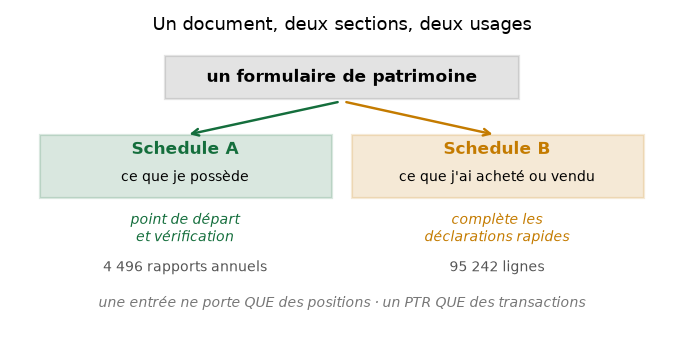

In [8]:
# Figure — un document, deux portes, deux usages (fig_10_deux_sections)
_o_A = int(matrice_sections.loc["O — rapport annuel", "A_documents"])
_o_B = int(matrice_sections.loc["O — rapport annuel", "B_lignes"])
fig, ax = plt.subplots(figsize=(FIGCOL, 2.15))
ax.add_patch(plt.Rectangle((0.62, 2.15), 1.76, 0.5, color="#555555", alpha=0.16))
ax.text(1.5, 2.4, "un formulaire de patrimoine", ha="center", va="center", fontsize=7.5, weight="bold")
_col = {"A": "#146e3c", "B": "#c47b00"}
for _x, _s, _titre, _quoi, _sert in [
        (0.0, "A", "Schedule A", "ce que je possède", "point de départ\net vérification"),
        (1.55, "B", "Schedule B", "ce que j'ai acheté ou vendu", "complète les\ndéclarations rapides")]:
    ax.annotate("", xy=(_x + 0.72, 1.72), xytext=(1.5, 2.12),
                arrowprops=dict(arrowstyle="->", color=_col[_s], lw=1.1))
    ax.add_patch(plt.Rectangle((_x, 0.98), 1.45, 0.74, color=_col[_s], alpha=0.16))
    ax.text(_x + 0.72, 1.5, _titre, ha="center", fontsize=7.5, weight="bold", color=_col[_s])
    ax.text(_x + 0.72, 1.18, _quoi, ha="center", fontsize=6.4)
    ax.text(_x + 0.72, 0.62, _sert, ha="center", va="center", fontsize=6.4, color=_col[_s], style="italic")
ax.text(0.72, 0.12, f"{_o_A:,} rapports annuels".replace(",", " "), ha="center", fontsize=6.2, color="#555555")
ax.text(2.27, 0.12, f"{_o_B:,} lignes".replace(",", " "), ha="center", fontsize=6.2, color="#555555")
ax.text(1.5, -0.3, "une entrée ne porte QUE des positions · un PTR QUE des transactions",
        ha="center", fontsize=6.2, style="italic", color="#777777")
ax.set_xlim(-0.12, 3.12); ax.set_ylim(-0.5, 2.8); ax.axis("off")
ax.set_title("Un document, deux sections, deux usages")
plt.tight_layout(); plt.show()

In [9]:
# La table 12 : TOUTES les photos datées (H entrée · C candidat · O annuelle · T sortie), au niveau document
ph12 = (pd.read_csv(os.path.join(V1T, "12_portefeuilles_dates.csv"),
                    usecols=["doc_id", "bioguide", "filing_type", "filing_date"], parse_dates=["filing_date"])
        .drop_duplicates("doc_id"))
print(f"12_portefeuilles_dates — {ph12.shape[0]:,} documents-photos · {ph12['bioguide'].nunique()} membres · "
      f"types : {ph12['filing_type'].value_counts().to_dict()}")
display(ph12.head(3))

12_portefeuilles_dates — 6,135 documents-photos · 887 membres · types : {'O': 4447, 'C': 934, 'T': 378, 'H': 376}


,doc_id,bioguide,filing_type,filing_date
0,10010992,A000374,O,2016-05-16
50,10010483,A000370,O,2016-04-26
52,10010606,A000055,O,2016-08-14


**Tickers.** Map `ticker` → `ticker_yahoo` reconstruite depuis la table clean (0 conflit) ; défaut « . » → « - ».

In [10]:
_paires = cl[["ticker", "ticker_yahoo"]].dropna().drop_duplicates()
assert (_paires.groupby("ticker")["ticker_yahoo"].nunique() <= 1).all(), "map ambiguë"
MAP_YAHOO = dict(zip(_paires["ticker"], _paires["ticker_yahoo"]))
def to_yahoo(t):
    t = str(t)
    return MAP_YAHOO.get(t, t.replace(".", "-"))
print(f"map : {len(MAP_YAHOO)} paires, {sum(1 for k, v in MAP_YAHOO.items() if k != v)} renommages, 0 conflit")
display(_paires[_paires["ticker"] != _paires["ticker_yahoo"]].head(3))

map : 4653 paires, 52 renommages, 0 conflit


,ticker,ticker_yahoo
217,CTL,LUMN
255,DISCA,WBD
260,FB,META


**Fourchettes.** Un montant déclaré est une fourchette [v̲, v̄] ; on travaille au milieu ṽ = (v̲+v̄)/2 — milieux clean ≡ v1 (écart 0).

In [11]:
_g_clean = (cl.dropna(subset=["amount_range", "amount_midpoint"])
            .groupby("amount_range")["amount_midpoint"].first())
_v1_mid = (f16.assign(mid=(f16["amount_lo"] + f16["amount_hi"]) / 2)
           .groupby("amount_range")["mid"].first())
_commun = _g_clean.index.intersection(_v1_mid.index)
assert (_g_clean.loc[_commun] - _v1_mid.loc[_commun]).abs().max() == 0
print(f"{len(_commun)} fourchettes communes, écart max des milieux = 0 ✅")
display(pd.DataFrame({"midpoint_clean": _g_clean.loc[_commun], "mid_v1": _v1_mid.loc[_commun]}).head(4))

12 fourchettes communes, écart max des milieux = 0 ✅


,midpoint_clean,mid_v1
amount_range,,
"$1,000,001 - $5,000,000",3000000.5,3000000.5
"$1,001 - $15,000",8000.5,8000.5
"$100,001 - $250,000",175000.5,175000.5
$121,121.0,121.0


**Classer AVANT de tickériser.** Une ligne déclarée est d'abord typée ; un ticker n'est jamais
attribué à une ligne dont la classe l'interdit. Règle d'or : **le moteur equity ne voit que la classe
`negociable`** (actions/ETF candidates) — les fonds, monétaires et faux tickers restent comptés, jamais tradés.

In [12]:
# Classification d'une ligne déclarée — AVANT toute résolution de prix
import re as _re
CODES_FORMULAIRE = {"EIF", "DC", "JT", "SP", "MF", "EF", "RP", "OL", "IH", "WU", "PS", "VA",
                    "AB", "OT", "HE", "IC", "FA", "SA", "OI"}          # codes House, pas des tickers
TICKERS_AMBIGUS = {"BA", "GS", "ST", "CS", "PE"}                        # existent en bourse : bloqués si libellé = compte
MONETAIRES = {"SPAXX", "FDRXX", "FZDXX", "SWVXX", "VMFXX", "SPRXX", "FCASH"}
RE_COMPTE = _re.compile(r"(?i)(?:merrill|mesirow|fidelity|schwab|betterment|morgan stanley|wells fargo|"
                        r"brokerage|\bIRA\b|401\s?k|trust)")
RE_FONDS = _re.compile(r"(?i)(?:\bfund\b|\bindex\b|\bportfolio\b|institutional)")

def _actif_seul(libelle):
    """Le libellé porte souvent le CONTENEUR avant l'actif : « Traditional IRA ⇒ Vanguard … ».
    Un test de nature d'actif ne doit lire que ce qui suit la dernière flèche, sinon le nom du
    COMPTE (fund, index, portfolio) classe l'actif — et sort des ETF cotés du moteur."""
    return str(libelle).split("⇒")[-1].strip() if libelle == libelle else ""

def classe_ligne(ticker, libelle):
    t = str(ticker).upper().strip()
    lib = str(libelle) if libelle == libelle else ""
    if t in CODES_FORMULAIRE:
        return "faux_ticker"
    if t in TICKERS_AMBIGUS and RE_COMPTE.search(lib):
        return "faux_ticker"
    if t in MONETAIRES:
        return "monetaire"
    if len(t) == 5 and t.endswith("X"):
        return "fonds"
    if RE_FONDS.search(_actif_seul(lib)):        # l'actif, jamais le nom du compte
        return "fonds"
    return "negociable"

f16["classe"] = [classe_ligne(t, d) for t, d in zip(f16["ticker"], f16["asset_description"])]
print("classes du flux O/A/T (table 16) :", f16["classe"].value_counts().to_dict())
display(f16[f16["classe"] == "faux_ticker"][["ticker", "asset_description"]].head(3))

classes du flux O/A/T (table 16) : {'negociable': 16062, 'fonds': 9393, 'monetaire': 364, 'faux_ticker': 296}


,ticker,asset_description
114,WU,R.M. Keil Trust ⇒ SP
141,EIF,MERRILL LYNCH #182 ⇒
142,EIF,MERRILL LYNCH #182 ⇒


**Les transactions House (PTR).** Fenêtre 2013-2026, format moteur : (membre, ticker, sens, date de transaction, ṽ).

In [13]:
df = (cl[cl["chamber"] == "house"]
      .drop(columns=["ticker"])
      .rename(columns={"member_name": "name", "ticker_yahoo": "ticker", "direction": "op",
                       "transaction_date": "traded", "amount_midpoint": "size_usd"}))
_n0 = len(df)
df = df[df["traded"].dt.year.between(2013, 2026)]
df = df[["bioguide_id", "name", "ticker", "op", "traded", "size_usd"]].reset_index(drop=True)
print(f"House : {_n0:,} lignes clean → {len(df):,} dans la fenêtre 2013-2026 "
      f"| {df['bioguide_id'].nunique()} membres | {df['ticker'].nunique():,} tickers")
display(df.head(3))

House : 122,814 lignes clean → 122,809 dans la fenêtre 2013-2026 | 315 membres | 4,340 tickers


,bioguide_id,name,ticker,op,traded,size_usd
0,G000563,Bob Gibbs,INTC,buy,2014-12-30,8000.5
1,G000563,Bob Gibbs,B,sell,2014-12-23,8000.5
2,G000563,Bob Gibbs,AAPL,buy,2014-12-30,8000.5


**Le contenu des photos d'entrée.** 15 ⋈ 11 par `doc_id`, lignes tickérisées et valorisées, milieux sommés par (membre, ticker).

**La photo d'entrée, re-choisie.** La table `15_portefeuille_entree` a été construite sur les seuls
documents électroniques. Maintenant que les scannés sont océrisés, on refait le même choix, avec les
mêmes règles qu'en V1 : on prend la première photo d'entrée (H) du membre ; à défaut sa photo de
candidat (C), à condition qu'elle porte au moins un ticker et qu'elle ait été déposée moins d'un an
avant un début de mandat — une photo de candidat déposée par un sortant en campagne n'est pas une photo
d'entrée.

In [14]:
# Les mandats officiels, pour appliquer le garde-fou de la photo de candidat
import yaml as _yaml
_REF = os.path.join(J, "01_v1_house", "reference")
mandats_ref = {}
for _f in ("legislators-current.yaml", "legislators-historical.yaml"):
    for _p in _yaml.safe_load(open(os.path.join(_REF, _f))):
        _t = [(x["start"], x["end"]) for x in _p["terms"] if x["type"] == "rep"]
        if _t:
            mandats_ref[_p["id"]["bioguide"]] = _t

# candidates : tout document H ou C portant au moins une ligne tickérisée, quelle que soit son origine
_cand = (h11[h11["filing_type"].isin(["H", "C"]) & h11["ticker"].notna() & h11["bioguide"].notna()]
         .groupby(["bioguide", "doc_id", "filing_type", "filing_date", "source_extraction"], as_index=False)
         .agg(n_tickers=("ticker", "nunique")))
_cand["filing_date"] = pd.to_datetime(_cand["filing_date"], errors="coerce")
_cand = _cand.dropna(subset=["filing_date"])

def _debut_apres(b, d):
    _outs = [pd.Timestamp(s) for s, _e in mandats_ref.get(b, []) if pd.Timestamp(s) >= d]
    return min(_outs) if _outs else None

_rows = []
for _b, _g in _cand.groupby("bioguide"):
    _h = _g[_g["filing_type"] == "H"].sort_values("filing_date")
    if len(_h):
        _r = _h.iloc[0]
    else:
        _c = _g[_g["filing_type"] == "C"].sort_values("filing_date")
        _r = None
        for _, _x in _c.iterrows():
            _d = _debut_apres(_b, _x["filing_date"])
            if _d is not None and (_d - _x["filing_date"]).days <= 365:
                _r = _x
                break
        if _r is None:
            continue
    _rows.append(dict(bioguide=_b, doc_id=_r["doc_id"], type_photo=_r["filing_type"],
                      filing_date=_r["filing_date"], n_tickers=int(_r["n_tickers"]),
                      source_extraction=_r["source_extraction"]))
e15_plus = pd.DataFrame(_rows)
_nouv = set(e15_plus["bioguide"]) - set(e15["bioguide"])
print(f"photos d'entrée : {len(e15)} (électronique, table 15) → {len(e15_plus)} en re-sélectionnant "
      f"sur les deux origines · {len(_nouv)} membres gagnés")
display(e15_plus.groupby(["source_extraction", "type_photo"]).size().to_frame("membres"))
display(e15_plus.head(3))

photos d'entrée : 284 (électronique, table 15) → 291 en re-sélectionnant sur les deux origines · 41 membres gagnés


membres
source_extraction type_photo         
ocr               C                27
                  H                 7
électronique      C                25
                  H               232

,bioguide,doc_id,type_photo,filing_date,n_tickers,source_extraction
0,A000148,10040680,H,2021-07-29,26,électronique
1,A000370,10023476,C,2018-06-15,3,électronique
2,A000372,9107064,H,2015-05-22,3,ocr


In [15]:
# Contrôle : sur les membres déjà couverts, la re-sélection retrouve-t-elle le MÊME document ?
_j = e15.merge(e15_plus, on="bioguide", suffixes=("_v1", "_new"))
_id = (_j["doc_id_v1"] == _j["doc_id_new"]).mean()
print(f"membres présents dans les deux : {len(_j)} · même document choisi : {_id:.1%}")
if _id < 1:
    display(_j.loc[_j["doc_id_v1"] != _j["doc_id_new"],
                   ["bioguide", "doc_id_v1", "type_photo_v1", "doc_id_new", "type_photo_new"]].head(6))
    print("écart attendu : un H océrisé peut primer sur un C électronique retenu faute de mieux")

# UNION : la re-sélection ajoute, elle ne retire jamais. Un membre déjà couvert par la table 15 le reste.
_perdus_resel = sorted(set(e15["bioguide"]) - set(e15_plus["bioguide"]))
_garde = e15[e15["bioguide"].isin(_perdus_resel)].assign(source_extraction="électronique (table 15)")
_cols_e = ["bioguide", "doc_id", "type_photo", "filing_date", "n_tickers", "source_extraction"]
e15 = pd.concat([e15_plus.reindex(columns=_cols_e), _garde.reindex(columns=_cols_e)], ignore_index=True)
e15["filing_date"] = pd.to_datetime(e15["filing_date"], errors="coerce")
assert e15["bioguide"].is_unique
print(f"→ e15 = union : {len(e15)} membres ({len(e15_plus)} re-sélectionnés + {len(_garde)} conservés "
      f"de la table 15, qui ne repassent pas les règles sur la table fusionnée)")
display(e15.groupby("source_extraction").size().to_frame("membres"))

membres présents dans les deux : 250 · même document choisi : 98.8%


,bioguide,doc_id_v1,type_photo_v1,doc_id_new,type_photo_new
84,G000600,10053638,H,10049735,C
107,J000020,10035648,C,9115399,C
109,J000301,10026778,H,10059824,C


écart attendu : un H océrisé peut primer sur un C électronique retenu faute de mieux
→ e15 = union : 325 membres (291 re-sélectionnés + 34 conservés de la table 15, qui ne repassent pas les règles sur la table fusionnée)


,membres
source_extraction,
ocr,34
électronique,257
électronique (table 15),34


In [16]:
_perdus = sorted(set(e15["doc_id"]) - set(h11["doc_id"]))
assert set(_perdus) <= {10041638}, _perdus   # seul rescapé : la photo conservée par l'union,
                                            # dont aucune ligne n'a été extraite (journalisée)
ph_all = (e15.merge(h11, on="doc_id", suffixes=("", "_h"))
             .query("ticker == ticker and ~conteneur_nu")
             .assign(mid=lambda d: (d["value_lo"] + d["value_hi"]) / 2)
             .dropna(subset=["mid"]))
ph_all["classe"] = [classe_ligne(t, d) for t, d in zip(ph_all["ticker"], ph_all["asset_description"])]
_cls_ph = ph_all.groupby("classe").agg(lignes=("mid", "size"), valeur_MUSD=("mid", lambda v: v.sum() / 1e6)).round(0)
display(_cls_ph)
ph_ent = ph_all[ph_all["classe"] == "negociable"].copy()          # le moteur equity ne voit que ça
ph_ent["ticker_y"] = ph_ent["ticker"].map(to_yahoo)
ph_ent = ph_ent.groupby(["bioguide", "ticker_y", "filing_date"], as_index=False)["mid"].sum()
print(f"photos d'entrée : {ph_all['bioguide'].nunique()} membres à lignes tickérisées → "
      f"{ph_ent['bioguide'].nunique()} membres à lignes NÉGOCIABLES · {len(ph_ent):,} lignes · "
      f"{ph_ent['mid'].sum()/1e6:,.0f} M$ (doc perdu journalisé : {_perdus})")
display(ph_ent.head(3))

,lignes,valeur_MUSD
classe,,
faux_ticker,56,2.0
fonds,1726,219.0
monetaire,48,1.0
negociable,11480,595.0


photos d'entrée : 288 membres à lignes tickérisées → 261 membres à lignes NÉGOCIABLES · 8,860 lignes · 595 M$ (doc perdu journalisé : [10041638])


,bioguide,ticker_y,filing_date,mid
0,A000148,DMXF,2021-07-29,8000.5
1,A000148,DSI,2021-07-29,32500.5
2,A000148,EEMX,2021-07-29,32500.5


In [17]:
# L'effet de la lecture du seul actif : ce que l'ancien test « fonds » écartait à tort
def _classe_ancienne(ticker, libelle):
    t = str(ticker).upper().strip(); lib = str(libelle) if libelle == libelle else ""
    if t in CODES_FORMULAIRE: return "faux_ticker"
    if t in TICKERS_AMBIGUS and RE_COMPTE.search(lib): return "faux_ticker"
    if t in MONETAIRES: return "monetaire"
    if len(t) == 5 and t.endswith("X"): return "fonds"
    if RE_FONDS.search(lib): return "fonds"          # ← l'ancien test lisait le libellé ENTIER
    return "negociable"
_tk = h11[h11["ticker"].notna()].copy()
_tk["mid"] = (_tk["value_lo"] + _tk["value_hi"]) / 2
_av = [_classe_ancienne(t, d) for t, d in zip(_tk["ticker"], _tk["asset_description"])]
_ap = [classe_ligne(t, d) for t, d in zip(_tk["ticker"], _tk["asset_description"])]
_gagne = _tk[[a == "fonds" and b == "negociable" for a, b in zip(_av, _ap)]]
print(f"lignes rendues au moteur : {len(_gagne):,} ({_gagne['mid'].sum()/1e6:,.0f} M$) — elles étaient")
print("classées « fonds » à cause du nom du COMPTE, pas de l'actif.")
display(_gagne["ticker"].value_counts().head(8).to_frame("lignes"))

lignes rendues au moteur : 1,211 (460 M$) — elles étaient
classées « fonds » à cause du nom du COMPTE, pas de l'actif.


,lignes
ticker,
TF,26
AAPL,26
VTI,19
MSFT,18
SPY,18
FB,16
SAFM,14
WINA,14


In [18]:
# Le paysage déclaré COMPLET : les 420 916 lignes de holdings (tous types de photos), par classe
_hp = h11.copy()
_hp["mid"] = (_hp["value_lo"] + _hp["value_hi"]) / 2
_hp["classe"] = np.where(_hp["ticker"].isna(), "(non tickérisée)",
                         [classe_ligne(t, l) for t, l in zip(_hp["ticker"].fillna(""), _hp["asset_description"])])
paysage = (_hp.groupby("classe").agg(lignes=("classe", "size"), valeur_MUSD=("mid", lambda s: s.sum() / 1e6))
           .round(0).astype(int).sort_values("valeur_MUSD", ascending=False))
display(paysage)
assert int(paysage["lignes"].sum()) == len(h11)
_neg = paysage.loc["negociable"]
print(f"le déclaré dépasse largement le négociable : {_neg['lignes']:,} lignes négociables "
      f"({_neg['valeur_MUSD']:,} M$) sur {len(h11):,} lignes déclarées "
      f"({int(paysage['valeur_MUSD'].sum()):,} M$) — immobilier, LLC, fonds, comptes restent déclarés mais hors moteur")

,lignes,valeur_MUSD
classe,,
(non tickérisée),337593,87405
negociable,231426,12790
fonds,38885,3752
monetaire,1106,99
faux_ticker,876,84


le déclaré dépasse largement le négociable : 231,426 lignes négociables (12,790 M$) sur 609,886 lignes déclarées (104,130 M$) — immobilier, LLC, fonds, comptes restent déclarés mais hors moteur


In [19]:
# Le patrimoine : ce qu'on empile sur 13 ans ≠ ce qu'un membre possède à un instant donné
_hp2 = h11.copy()
_hp2["mid"] = (_hp2["value_lo"] + _hp2["value_hi"]) / 2
_hp2["filing_date"] = pd.to_datetime(_hp2["filing_date"], errors="coerce")
_empile = _hp2["mid"].sum() / 1e6
_dernier = (_hp2.dropna(subset=["bioguide", "filing_date"])
            .sort_values("filing_date").drop_duplicates("bioguide", keep="last")["doc_id"])
_stock = _hp2[_hp2["doc_id"].isin(set(_dernier))]
patrimoine = pd.DataFrame([
    ("somme de TOUTES les lignes déposées, 2014-2026", round(_empile), len(_hp2),
     "un actif est recompté à chaque rapport annuel : ce n'est PAS un patrimoine"),
    ("dernier document de chaque membre (stock daté)", round(_stock["mid"].sum() / 1e6), len(_stock),
     f"{_stock['bioguide'].nunique()} membres · la grandeur qu'on peut appeler « patrimoine »"),
], columns=["mesure", "M$", "lignes", "ce que c'est"]).set_index("mesure")
display(patrimoine)
print(f"rapport entre les deux : {_empile / max(_stock['mid'].sum()/1e6, 1):.0f}× — d'où l'obligation de nommer")
print("l'agrégat : « somme des lignes déclarées sur 13 ans », jamais « le patrimoine des élus ».")

,M$,lignes,ce que c'est
mesure,,,
"somme de TOUTES les lignes déposées, 2014-2026",104130,609886,un actif est recompté à chaque rapport annuel ...
dernier document de chaque membre (stock daté),8887,42522,887 membres · la grandeur qu'on peut appeler «...


rapport entre les deux : 12× — d'où l'obligation de nommer
l'agrégat : « somme des lignes déclarées sur 13 ans », jamais « le patrimoine des élus ».


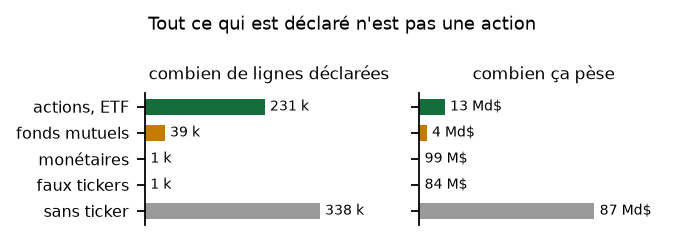

In [20]:
# Figure — ÉTAPE 6 on trie : le paysage déclaré, en lignes et en valeur (fig_10_paysage)
_ordre = ["negociable", "fonds", "monetaire", "faux_ticker", "(non tickérisée)"]
_noms = {"negociable": "actions, ETF", "fonds": "fonds mutuels", "monetaire": "monétaires",
         "faux_ticker": "faux tickers", "(non tickérisée)": "sans ticker"}
_p = paysage.reindex(_ordre)
_cols = ["#146e3c", "#c47b00", "#e0b050", "#a01e1e", "#9a9a9a"]
_y = np.arange(len(_p))[::-1]
fig, axes = plt.subplots(1, 2, figsize=(FIGCOL, 1.45))
for _ax, _col, _titre, _fmt in [
        (axes[0], "lignes", "combien de lignes déclarées", lambda v: f"{v/1000:.0f} k"),
        (axes[1], "valeur_MUSD", "combien ça pèse", lambda v: f"{v/1000:.0f} Md$" if v >= 1000 else f"{v:.0f} M$")]:
    _v = _p[_col].values
    _ax.barh(_y, _v, color=_cols, height=0.62)
    for _yy, _val in zip(_y, _v):
        _ax.text(_val + max(_v) * 0.03, _yy, _fmt(_val), va="center", fontsize=6.5)
    _ax.set_xlim(0, max(_v) * 1.42); _ax.set_yticks(_y); _ax.set_xticks([])
    _ax.set_title(_titre, fontsize=7.5)
    for _s in ("top", "right", "bottom"):
        _ax.spines[_s].set_visible(False)
axes[0].set_yticklabels([_noms[k] for k in _p.index], fontsize=7)
axes[1].set_yticklabels([])
fig.suptitle("Tout ce qui est déclaré n'est pas une action", fontsize=8)
plt.tight_layout(); plt.show()

**Les prix.** Calendrier = SPY. Univers COMPLET : tickers des trades PTR ∪ photos ∪ O/A/T ; sources `prices_v2`
(prioritaire, jamais modifié) puis `prices_holdings_v1` (cache séparé, resumable) ; garde-fou anti-corruption.

In [21]:
PRICES_V2   = os.path.join(BASE, "cache", "prices_v2")
PRICES_HOLD = os.path.join(BASE, "cache", "prices_holdings_v1")
_SNAP_PV2 = sorted(os.listdir(PRICES_V2))                    # re-asserté en toute fin
spy = (pd.read_csv(os.path.join(PRICES_V2, "SPY.csv"), parse_dates=["Date"])
         .set_index("Date")["close"].sort_index())
cal = spy.index
r_spy = spy.pct_change()
print(f"calendrier : {len(cal)} jours cotés, {cal[0].date()} → {cal[-1].date()} | snapshot prices_v2 : {len(_SNAP_PV2)} fichiers")

calendrier : 3645 jours cotés, 2012-01-03 → 2026-07-02 | snapshot prices_v2 : 3351 fichiers


In [22]:
# univers de prix : PTR ∪ photos NÉGOCIABLES ∪ O/A/T NÉGOCIABLES (v8 — les fonds/faux tickers n'y entrent plus)
RETRY_FAILED = False                               # la failed-list n'est plus un verdict : True = la rejouer
# re-test du 2026-07-21 : 175 tickers récupérés. Re-test du 2026-07-22, réseau vérifié par trois
# témoins vivants (AAPL, MSFT, SPY répondent) : 1 455 tickers rejoués, ZÉRO récupéré. La
# failed-list n'est donc pas un artefact de téléchargement — ces titres n'ont pas de série.
FAILED_RETRY_DATE = "2026-07-22"                   # date du re-test (paramètre déclaré, pas d'horloge cachée)
_univers = (set(df["ticker"].dropna()) | set(ph_ent["ticker_y"])
            | set(f16.loc[f16["classe"] == "negociable", "ticker"].dropna().map(to_yahoo)))
_have_v2 = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(PRICES_V2, "*.csv"))} - {"failed_v2"}
_have_ph = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(PRICES_HOLD, "*.csv"))} - {"failed_holdings_v1"}
_fail_f = os.path.join(PRICES_HOLD, "failed_holdings_v1.csv")
_failed_df = pd.read_csv(_fail_f) if os.path.exists(_fail_f) else pd.DataFrame(columns=["ticker"])
if "date_echec" not in _failed_df.columns:
    _failed_df["date_echec"] = "avant-" + FAILED_RETRY_DATE          # migration : anciens échecs non datés
_failed = set(_failed_df["ticker"])
_todo = sorted((_univers - _have_v2 - _have_ph) if RETRY_FAILED else (_univers - _have_v2 - _have_ph - _failed))
print(f"RETRY_FAILED = {RETRY_FAILED} · failed-list datée {FAILED_RETRY_DATE}")
print(f"univers NÉGOCIABLE : {len(_univers):,} tickers | v2 : {len(_univers & _have_v2):,} | cache séparé : "
      f"{len(_univers & _have_ph):,} | échecs connus : {len(_univers & _failed):,} | à (re)tenter : {len(_todo)}")
if _todo:
    import yfinance as yf, logging
    logging.getLogger("yfinance").setLevel(logging.CRITICAL)
    _new_fail = []
    for _i in range(0, len(_todo), 60):
        _chunk = _todo[_i:_i + 60]
        try:
            _data = yf.download(_chunk, start="2012-01-01", end="2026-07-03", auto_adjust=True,
                                progress=False, threads=True, group_by="ticker")
        except Exception:
            _data = None
        for _t in _chunk:
            _s = None
            try:
                if _data is not None and isinstance(_data.columns, pd.MultiIndex):
                    if _t in _data.columns.get_level_values(0):
                        _s = _data[_t]["Close"].dropna()
            except Exception:
                _s = None
            if _s is not None and len(_s) >= 2:
                _s.rename("close").to_csv(os.path.join(PRICES_HOLD, _t + ".csv"), index_label="Date")
            else:
                _new_fail.append(_t)
    _recuperes = sorted(set(_todo) & _failed - set(_new_fail))
    _failed_df = (pd.concat([_failed_df[~_failed_df["ticker"].isin(_recuperes)],
                             pd.DataFrame({"ticker": [t for t in _new_fail if t not in set(_failed_df["ticker"])],
                                           "date_echec": FAILED_RETRY_DATE})])
                  .drop_duplicates("ticker"))
    _failed_df.to_csv(_fail_f, index=False)
    print(f"re-test : {len(_recuperes)} tickers RÉCUPÉRÉS (étaient dans la failed-list) · "
          f"{len(_new_fail)} échecs (re)datés {FAILED_RETRY_DATE}")
    _have_ph = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(PRICES_HOLD, "*.csv"))} - {"failed_holdings_v1"}

RETRY_FAILED = False · failed-list datée 2026-07-22
univers NÉGOCIABLE : 5,468 tickers | v2 : 3,192 | cache séparé : 821 | échecs connus : 1,455 | à (re)tenter : 0


In [23]:
prices, _corrompus = {}, []
for _tk in sorted(_univers):
    _p = (os.path.join(PRICES_V2, _tk + ".csv") if _tk in _have_v2
          else os.path.join(PRICES_HOLD, _tk + ".csv") if _tk in _have_ph else None)
    if _p is None:
        continue
    _s = pd.read_csv(_p, parse_dates=["Date"]).set_index("Date")["close"].sort_index().reindex(cal).ffill()
    if (len(_s.dropna()) < 2 or _s.dropna().min() < 0.10
            or _s.dropna().pct_change().abs().max() > 3.0):
        _corrompus.append(_tk); continue
    prices[_tk] = _s
_n_avant = len(df)
df = df[df["ticker"].isin(prices)].reset_index(drop=True)
print(f"prix chargés : {len(prices):,} tickers ({len(_corrompus)} corrompus exclus) | "
      f"trades House : {_n_avant:,} → {len(df):,} avec prix (−{_n_avant-len(df):,}) | "
      f"{df['bioguide_id'].nunique()} membres")

prix chargés : 3,933 tickers (80 corrompus exclus) | trades House : 122,809 → 107,976 avec prix (−14,833) | 305 membres


### P0.1 Validation

In [24]:
assert df["ticker"].isin(prices).all() and df["op"].isin(["buy", "sell", "exchange"]).all()
assert df["traded"].dt.year.between(2013, 2026).all() and (df["size_usd"] > 0).all()
df = df[df["op"] != "exchange"].reset_index(drop=True)     # pas de sens directionnel — écartés, comptés
print(f"✅ É1 valide — {len(df):,} trades House exploitables (les 'exchange' écartés)")

✅ É1 valide — 107,976 trades House exploitables (les 'exchange' écartés)


**Le flux de trades, construit ici** (l'analyse vient en P2) : trades O/A/T mis au format du moteur, puis F = F_ptr ∪ F_oat, provenance étiquetée. Doublons inter-sources retirés (collision exacte membre × ticker × sens × date contre NOS PTR).

In [25]:
df_oat = f16.rename(columns={"bioguide": "bioguide_id", "declarant_name": "name",
                             "transaction_date": "traded",
                             "amount_mid_conventionnel": "size_usd"}).copy()
df_oat["ticker"] = df_oat["ticker"].map(to_yahoo)
df_oat["op"] = df_oat["sens"].map({"P": "buy", "S": "sell"})
_n0 = len(df_oat)
df_oat = df_oat.dropna(subset=["op"])                              # 'E' (exchange) : écartés
_n1 = len(df_oat)
df_oat = df_oat[df_oat["traded"].dt.year.between(2013, 2026)]      # dates corrompues dehors
_n2 = len(df_oat)
df_oat = df_oat[df_oat["size_usd"].notna() & (df_oat["size_usd"] > 0)]
_n3 = len(df_oat)
_nc = df_oat["classe"].value_counts()
df_oat = df_oat[df_oat["classe"] == "negociable"]                  # v8 : fonds/monétaires/faux tickers HORS moteur
_n4 = len(df_oat)
df_oat = df_oat[df_oat["ticker"].isin(prices)]
df_oat = df_oat[["bioguide_id", "name", "ticker", "op", "traded", "size_usd"]].assign(provenance="oat")
print(f"O/A/T : {_n0:,} → {_n1:,} (−{_n0-_n1} exchanges) → {_n2:,} (−{_n1-_n2} dates) → {_n3:,} (−{_n2-_n3} sans montant)")
print(f"      → −{_nc.get('faux_ticker', 0):,} faux tickers · −{_nc.get('monetaire', 0):,} monétaires · "
      f"−{_nc.get('fonds', 0):,} fonds = {_n4:,} négociables → {len(df_oat):,} avec prix (−{_n4-len(df_oat):,})")
display(df_oat.head(3))

O/A/T : 26,115 → 25,894 (−221 exchanges) → 25,880 (−14 dates) → 25,880 (−0 sans montant)
      → −290 faux tickers · −364 monétaires · −9,345 fonds = 15,881 négociables → 14,563 avec prix (−1,318)


,bioguide_id,name,ticker,op,traded,size_usd,provenance
0,C001046,Eric Ivan Cantor,LEO,buy,2014-01-16,8000.5,oat
1,C001046,Eric Ivan Cantor,LEO,sell,2014-01-31,75000.5,oat
2,C001046,Eric Ivan Cantor,MOO,buy,2014-01-16,8000.5,oat


### Les transactions des documents scannés

On a rebranché plus haut le **Schedule A** des documents scannés. Ni leur **Schedule B**, ni les
déclarations rapides océrisées n'arrivaient au moteur : deux gisements de transactions restaient
inutilisés. On les ajoute ici, chacun marqué par son origine, avec les mêmes règles que le flux
électronique — même classement d'actif, même exigence de prix, même test d'écho.

In [26]:
# La règle d'écho, sortie au grand jour
ECHO_JOURS = 365      # une transaction d'un rapport est jugée « déjà connue » si une déclaration rapide
                      # du même membre porte le même (titre, sens) à moins de ECHO_JOURS. Cette constante
                      # décide à elle seule du volume d'apport des rapports : elle était cachée en amont.
print(f"règle d'écho : ±{ECHO_JOURS} jours")

règle d'écho : ±365 jours


In [27]:
# Gisement 1 — le Schedule B des documents scannés
fd_ocr = pd.read_csv(os.path.join(V1T, "09_transactions_fd_ocr.csv"), low_memory=False,
                     parse_dates=["transaction_date", "filing_date"])
_g1 = fd_ocr.rename(columns={"bioguide": "bioguide_id", "transaction_date": "traded"}).copy()
_g1["op"] = _g1["operation_type"].astype(str).str[0].map({"P": "buy", "S": "sell"})
_g1["classe"] = [classe_ligne(t, d) for t, d in zip(_g1["ticker"], _g1["asset_description"])]
_g1["ticker_y"] = _g1["ticker"].map(to_yahoo)
_l = [("lignes du Schedule B océrisé", len(fd_ocr), f"{fd_ocr['doc_id'].nunique()} documents · {fd_ocr['bioguide'].nunique()} membres")]
for _lib, _cond, _note in [
        ("− sens illisible ou échange", _g1["op"].notna(), ""),
        ("− aucun symbole reconnu", _g1["ticker"].notna(), "l'OCR ne devine pas un ticker absent"),
        ("− pas une action ni un ETF", _g1["classe"] == "negociable", ""),
        ("− date hors fenêtre 2013-2026", _g1["traded"].dt.year.between(2013, 2026), ""),
        ("− aucun cours de bourse", _g1["ticker_y"].isin(prices), "")]:
    _n0 = len(_g1); _g1 = _g1[_cond.reindex(_g1.index).fillna(False)]
    _l.append((_lib, -(_n0 - len(_g1)), _note))
_l.append(("= candidates, avant le test d'écho", len(_g1), ""))
display(pd.DataFrame(_l, columns=["marche", "n", "note"]).set_index("marche"))

,n,note
marche,,
lignes du Schedule B océrisé,155306,669 documents · 165 membres
− sens illisible ou échange,-3017,
− aucun symbole reconnu,-89337,l'OCR ne devine pas un ticker absent
− pas une action ni un ETF,-205,
− date hors fenêtre 2013-2026,-1550,
− aucun cours de bourse,-9338,
"= candidates, avant le test d'écho",51859,


In [28]:
# Gisement 2 — les déclarations rapides océrisées absentes du flux électronique
ptr_ocr = pd.read_csv(os.path.join(V1T, "07_transactions_ptr_ocr.csv"), low_memory=False,
                      parse_dates=["transaction_date", "disclosure_date"])
_docs_clean = set(cl.loc[cl["chamber"] == "house", "doc_id"].dropna().astype(str))
_g2 = ptr_ocr.rename(columns={"bioguide": "bioguide_id", "transaction_date": "traded"}).copy()
_g2["absent"] = ~_g2["doc_id"].astype(str).isin(_docs_clean)
print(f"déclarations rapides océrisées : {len(_g2):,} lignes · {_g2['doc_id'].nunique()} documents")
print(f"documents jamais arrivés dans le flux électronique : {_g2.loc[_g2['absent'],'doc_id'].nunique()} "
      f"({int(_g2['absent'].sum()):,} lignes, {_g2.loc[_g2['absent'],'bioguide_id'].nunique()} membres)")
_g2 = _g2[_g2["absent"]].copy()
_g2["op"] = _g2["operation_type"].astype(str).str[0].map({"P": "buy", "S": "sell"}) if "operation_type" in _g2 else None
_g2["classe"] = [classe_ligne(t, d) for t, d in zip(_g2["ticker"], _g2["asset_description"])]
_g2["ticker_y"] = _g2["ticker"].map(to_yahoo)
print("⚠️  81 % des symboles de ce gisement viennent d'une attribution automatique, pas du document :")
display(_g2["ticker_source"].value_counts().head(4).to_frame("lignes") if "ticker_source" in _g2 else _g2.head(2))

déclarations rapides océrisées : 105,074 lignes · 2337 documents
documents jamais arrivés dans le flux électronique : 879 (15,381 lignes, 124 membres)
⚠️  81 % des symboles de ce gisement viennent d'une attribution automatique, pas du document :


,lignes
ticker_source,
llm_herite,7441
non_resolu,6238
corpus_v1,1470
imprime,232


In [29]:
# Le test d'écho appliqué au Schedule B océrisé, puis son entrée dans le flux
_ptr_cle = {}
for _r in df.itertuples():
    _ptr_cle.setdefault((_r.bioguide_id, _r.ticker, _r.op), []).append(_r.traded)
def _a_un_echo(b, tk, op, d):
    _v = _ptr_cle.get((b, tk, op), [])
    return bool(_v) and min(abs((x - d).days) for x in _v) <= ECHO_JOURS
_g1 = _g1.rename(columns={"ticker_y": "ticker_yahoo"})
_g1 = _g1[_g1["bioguide_id"].notna()]          # un document non rattaché à un membre est inutilisable ici
_g1["echo"] = [_a_un_echo(b, t, o, d) for b, t, o, d in
               zip(_g1["bioguide_id"], _g1["ticker_yahoo"], _g1["op"], _g1["traded"])]
_g1_net = (_g1[~_g1["echo"]]
           .sort_values(["filing_date", "doc_id"])
           .drop_duplicates(["bioguide_id", "ticker_yahoo", "op", "traded"], keep="first"))
print(f"Schedule B océrisé : {len(_g1):,} candidates → {int((~_g1['echo']).sum()):,} sans écho PTR "
      f"→ {len(_g1_net):,} après déduplication")
df_oat_ocr = (_g1_net.drop(columns=["ticker"]).rename(columns={"ticker_yahoo": "ticker"})
              .assign(name=lambda d: d["bioguide_id"], size_usd=8000.5, provenance="oat_ocr")
              [["bioguide_id", "name", "ticker", "op", "traded", "size_usd", "provenance"]])
print(f"→ {len(df_oat_ocr):,} transactions ajoutées au flux, chez {df_oat_ocr['bioguide_id'].nunique()} membres")
print("⚠️  le Schedule B océrisé ne porte PAS de fourchette de montant exploitable : on applique le")
print("   milieu de la fourchette la plus fréquente (8 000 $). C'est un choix, il borne la précision.")

Schedule B océrisé : 50,388 candidates → 9,581 sans écho PTR → 7,478 après déduplication
→ 7,478 transactions ajoutées au flux, chez 57 membres
⚠️  le Schedule B océrisé ne porte PAS de fourchette de montant exploitable : on applique le
   milieu de la fourchette la plus fréquente (8 000 $). C'est un choix, il borne la précision.


In [30]:
_cle = ["bioguide_id", "ticker", "op", "traded"]
_coll = df_oat.merge(df[_cle], on=_cle, how="inner")
print(f"collisions exactes F_oat × F_ptr : {len(_coll)} ({len(_coll)/max(len(df_oat),1)*100:.2f} %) — retirées")
if len(_coll):
    df_oat = (df_oat.merge(_coll[_cle].drop_duplicates(), on=_cle, how="left", indicator=True)
                    .query("_merge == 'left_only'").drop(columns="_merge"))
assert len(df_oat.merge(df[_cle], on=_cle, how="inner")) == 0
df_uni = pd.concat([df.assign(provenance="ptr"), df_oat, df_oat_ocr], ignore_index=True)
print(f"F = {len(df_uni):,} trades = {int((df_uni['provenance']=='ptr').sum()):,} ptr + "
      f"{int((df_uni['provenance']=='oat').sum()):,} oat | membres : {df_uni['bioguide_id'].nunique()}")
display(df_uni.groupby("provenance").head(2).sort_values("provenance"))

collisions exactes F_oat × F_ptr : 488 (3.35 %) — retirées
F = 129,538 trades = 107,976 ptr + 14,084 oat | membres : 408


,bioguide_id,name,ticker,op,traded,size_usd,provenance
107976,C001046,Eric Ivan Cantor,LEO,buy,2014-01-16,8000.5,oat
107977,C001046,Eric Ivan Cantor,LEO,sell,2014-01-31,75000.5,oat
122060,H000636,H000636,PEP,sell,2013-03-06,8000.5,oat_ocr
122061,H000636,H000636,NFLX,sell,2013-01-28,8000.5,oat_ocr
0,G000563,Bob Gibbs,INTC,buy,2014-12-30,8000.5,ptr
1,G000563,Bob Gibbs,B,sell,2014-12-23,8000.5,ptr


### Ce que le gisement 2 apporterait, s'il était branché

Le gisement 2 — les déclarations rapides océrisées jamais arrivées par la voie électronique — est mesuré
plus haut mais **non injecté** : 41 % de ses lignes n'ont aucun symbole résolu, et 81 % de celles qui en
ont un le tiennent d'un modèle de langage, pas du document. Jusqu'ici son apport n'était chiffré qu'en
volume brut. On lui applique ici **exactement la même cascade** qu'au Schedule B océrisé, pour savoir ce
qu'il pèserait vraiment. Le basculement tient dans une constante.

In [31]:
# Gisement 2 : la même cascade que le gisement 1, pour chiffrer l'apport — sans injecter
INJECTER_GISEMENT_2 = False    # True = ces transactions entrent dans le flux F. Voir le livre ci-dessous.

_g2c = _g2.rename(columns={"ticker_y": "ticker_yahoo"}).copy()
_l2 = [("lignes des documents jamais arrivés", len(_g2c), "")]
for _lib, _cond, _note in [
        ("− sens illisible ou échange",     _g2c["op"].notna(), ""),
        ("− aucun symbole reconnu",         _g2c["ticker"].notna(), "l'OCR ne devine pas un symbole absent"),
        ("− pas une action ni un ETF",      _g2c["classe"] == "negociable", ""),
        ("− date hors fenêtre 2013-2026",   _g2c["traded"].dt.year.between(2013, 2026), ""),
        ("− aucun cours de bourse",         _g2c["ticker_yahoo"].isin(prices), ""),
        ("− non rattaché à un membre",      _g2c["bioguide_id"].notna(), "on ne sait pas à qui l'attribuer")]:
    _n0 = len(_g2c); _g2c = _g2c[_cond.reindex(_g2c.index).fillna(False)]
    _l2.append((_lib, -(_n0 - len(_g2c)), _note))
_l2.append(("= candidates, avant le test d'écho", len(_g2c), ""))

_g2c["echo"] = [_a_un_echo(b, t, o, d) for b, t, o, d in
                zip(_g2c["bioguide_id"], _g2c["ticker_yahoo"], _g2c["op"], _g2c["traded"])]
_n0 = len(_g2c); _g2c = _g2c[~_g2c["echo"]]
_l2.append((f"− déjà dit par une déclaration rapide (±{ECHO_JOURS} j)", -(_n0 - len(_g2c)), ""))
_g2_net = _g2c.sort_values(["disclosure_date", "doc_id"]).drop_duplicates(
    ["bioguide_id", "ticker_yahoo", "op", "traded"], keep="first")
_l2.append(("− doublons internes (membre, titre, sens, date)", -(len(_g2c) - len(_g2_net)), ""))
_l2.append(("= TRANSACTIONS QUE LE GISEMENT 2 AJOUTERAIT", len(_g2_net),
            f"chez {_g2_net['bioguide_id'].nunique()} membres"))
display(pd.DataFrame(_l2, columns=["marche", "n", "note"]).set_index("marche"))

_som = sum(x[1] for x in _l2[1:-2] if x[1] < 0) + sum(x[1] for x in _l2[-2:-1])
assert len(_g2_net) == len(_g2) + _som, "la cascade du gisement 2 ne boucle pas"
print(f"\nle gisement 2 ajouterait {len(_g2_net):,} transactions chez "
      f"{_g2_net['bioguide_id'].nunique()} membres — soit {len(_g2_net)/len(df_uni)*100:.1f} % du flux actuel.")

,n,note
marche,,
lignes des documents jamais arrivés,15381,
− sens illisible ou échange,-81,
− aucun symbole reconnu,-6192,l'OCR ne devine pas un symbole absent
− pas une action ni un ETF,-60,
− date hors fenêtre 2013-2026,-40,
− aucun cours de bourse,-1819,
− non rattaché à un membre,-2,on ne sait pas à qui l'attribuer
"= candidates, avant le test d'écho",7187,
− déjà dit par une déclaration rapide (±365 j),-3955,



le gisement 2 ajouterait 2,510 transactions chez 63 membres — soit 1.9 % du flux actuel.


In [32]:
# À quel prix : d'où viennent les symboles de ces transactions, et combien de membres sont NEUFS
if len(_g2_net):
    _src = (_g2_net["ticker_source"].value_counts() if "ticker_source" in _g2_net
            else pd.Series(dtype=int))
    _devine = int(_src.get("llm_herite", 0))
    _neufs = set(_g2_net["bioguide_id"]) - set(df_uni["bioguide_id"])
    print(f"origine du symbole des {len(_g2_net):,} transactions candidates :")
    display(_src.to_frame("transactions"))
    print(f"→ {_devine:,} sur {len(_g2_net):,} ({_devine/len(_g2_net):.0%}) portent un symbole ATTRIBUÉ "
          f"PAR UNE MACHINE, pas lu sur le document.")
    print(f"→ {len(_neufs)} membre(s) que le flux actuel ne voit pas du tout entreraient par ce gisement.")
    print(f"→ montant : le gisement ne porte pas de fourchette exploitable, ces trades prendraient")
    print(f"   eux aussi le forfait de 8 000,5 $.")
else:
    print("aucune transaction ne survit à la cascade : le gisement 2 n'apporterait rien.")
print(f"\nINJECTER_GISEMENT_2 = {INJECTER_GISEMENT_2} → le flux F reste à {len(df_uni):,} transactions.")
print("Basculer la constante à True est le seul geste nécessaire pour les faire entrer.")

origine du symbole des 2,510 transactions candidates :


,transactions
ticker_source,
llm_herite,2059
corpus_v1,399
imprime,52


→ 2,059 sur 2,510 (82%) portent un symbole ATTRIBUÉ PAR UNE MACHINE, pas lu sur le document.
→ 5 membre(s) que le flux actuel ne voit pas du tout entreraient par ce gisement.
→ montant : le gisement ne porte pas de fourchette exploitable, ces trades prendraient
   eux aussi le forfait de 8 000,5 $.

INJECTER_GISEMENT_2 = False → le flux F reste à 129,538 transactions.
Basculer la constante à True est le seul geste nécessaire pour les faire entrer.


## P1 — Les membres : qui est qui, qui a quoi

Les six types de dépôts, et ce qu'ils portent :

| type | quoi | rôle ici |
|---|---|---|
| **P** (PTR) | flux : trades à ~1 mois | le signal historique |
| **H** (New Filer) | photo : patrimoine à l'ENTRÉE | le point de départ h₀ |
| **C** (Candidate) | photo : patrimoine du candidat | h₀ de secours |
| **O** (Annual) | photo au 31/12 + flux de l'année | le JUGE de la reconstruction (P4) + trades manquants |
| **A** (Amendment) | correctif d'un O | trades manquants |
| **T** (Termination) | photo/flux de sortie | la vérification finale |

In [33]:
_traders_ptr = set(df["bioguide_id"])
_traders_uni = set(df_uni["bioguide_id"])
_oat_only    = _traders_uni - _traders_ptr
_photo_ok    = set(ph_ent["bioguide"])
G_PHOTO, G_ZERO = sorted(_traders_uni & _photo_ok), sorted(_traders_uni - _photo_ok)
cascade = pd.DataFrame([
    ("membres House 2014-2026 (registre v1)", len(reg14)),
    ("… qui TRADENT des actions cotées (PTR ∪ O/A/T)", len(_traders_uni)),
    ("        dont : vus par les PTR", len(_traders_ptr)),
    ("        dont : uniquement via O/A/T", len(_oat_only)),
    ("… qui ne tradent pas", len(reg14) - len(_traders_uni)),
    ("traders → G_photo (photo d'entrée exploitable)", len(G_PHOTO)),
    ("traders → G_zéro (sans photo exploitable)", len(G_ZERO)),
], columns=["population", "n"]).set_index("population")
display(cascade)
assert len(G_PHOTO) + len(G_ZERO) == len(_traders_uni)
assert len(_traders_ptr) + len(_oat_only) == len(_traders_uni)
print(f"partitions exactes : {len(G_PHOTO)} + {len(G_ZERO)} = {len(_traders_uni)} ✅  ·  "
      f"{len(reg14)} = {len(_traders_ptr)} + {len(_oat_only)} + {len(reg14)-len(_traders_uni)} ✅")

,n
population,
membres House 2014-2026 (registre v1),900
… qui TRADENT des actions cotées (PTR ∪ O/A/T),408
dont : vus par les PTR,305
dont : uniquement via O/A/T,103
… qui ne tradent pas,492
traders → G_photo (photo d'entrée exploitable),172
traders → G_zéro (sans photo exploitable),236


partitions exactes : 172 + 236 = 408 ✅  ·  900 = 305 + 103 + 492 ✅


In [34]:
# LIVRE DE COMPTES MEMBRES — d'où sortent les membres qui tradent (asserts)
_m16, _m_oat, _m_ptr = set(f16["bioguide"]), set(df_oat["bioguide_id"]), set(df["bioguide_id"])
_m_ocr = set(df_oat_ocr["bioguide_id"])        # le Schedule B des documents scannés
_perdus = _m16 - _m_oat
livre_mb = pd.DataFrame([
    ("membres présents dans la table 16 brute", len(_m16), ""),
    ("− perdus par l'entonnoir (aucune ligne O/A/T exploitable)", -len(_perdus),
     f"dont {len(_perdus & _m_ptr)} repêchés par leurs PTR (restent dans la population), "
     f"{len(_perdus - _m_ptr)} vraiment sortis"),
    ("= membres avec ≥1 trade O/A/T exploitable", len(_m_oat), ""),
    ("   dont : ont AUSSI des PTR", len(_m_oat & _m_ptr), ""),
    ("   dont : oat SEULEMENT (invisibles avant)", len(_m_oat - _m_ptr), ""),
    ("membres PTR (rappel, non-régression vérifiée)", len(_m_ptr), ""),
    ("+ membres vus par le Schedule B scanné", len(_m_ocr - _m_ptr - _m_oat),
     f"{len(_m_ocr)} membres dans ce gisement"),
    ("= UNION : la population qui trade", len(_m_ptr | _m_oat | _m_ocr), ""),
], columns=["marche", "n", "note"]).set_index("marche")
display(livre_mb)
_union_livre = _m_ptr | _m_oat | _m_ocr
_union_flux  = set(df_uni["bioguide_id"])
_ecart = _union_livre ^ _union_flux
if _ecart:
    print(f"⚠️  {len(_ecart)} membres diffèrent entre le livre et le flux — à examiner :", sorted(_ecart)[:5])
    print("   (cause connue : un membre dont toutes les lignes tombent au filtre prix garde une entrée")
    print("    dans le livre mais disparaît du flux)")
else:
    print(f"✅ livre et flux portent exactement les mêmes {len(_union_flux)} membres")
# « vus seulement par les rapports » inclut désormais le Schedule B des documents scannés
assert len((_m_oat | _m_ocr) - _m_ptr) == len(_oat_only), (len((_m_oat|_m_ocr)-_m_ptr), len(_oat_only))
assert len(df) == 107976 and len(_m_ptr) == 305, "NON-RÉGRESSION PTR cassée : l'univers étendu ne doit rien changer aux PTR"
print(f"✅ {len(_m_ptr)} (PTR) ∪ {len(_m_oat)} (oat) = {len(_m_ptr | _m_oat)} traders · "
      f"les {len(_perdus - _m_ptr)} vraiment sortis rejoignent les « ne tradent pas » de la cascade des 900")

,n,note
marche,,
membres présents dans la table 16 brute,370,
− perdus par l'entonnoir (aucune ligne O/A/T exploitable),-85,dont 21 repêchés par leurs PTR (restent dans l...
= membres avec ≥1 trade O/A/T exploitable,285,
dont : ont AUSSI des PTR,199,
dont : oat SEULEMENT (invisibles avant),86,
"membres PTR (rappel, non-régression vérifiée)",305,
+ membres vus par le Schedule B scanné,17,57 membres dans ce gisement
= UNION : la population qui trade,408,


✅ livre et flux portent exactement les mêmes 408 membres
✅ 305 (PTR) ∪ 285 (oat) = 391 traders · les 64 vraiment sortis rejoignent les « ne tradent pas » de la cascade des 900


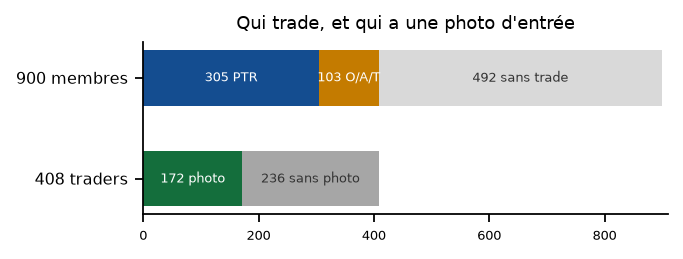

In [35]:
# Figure — la partition de la population, en deux barres (fig_10_partition)
fig, ax = plt.subplots(figsize=(FIGCOL, 1.65))
_seg1 = [(len(_traders_ptr), "#144d90", f"{len(_traders_ptr)} PTR", "w"),
         (len(_oat_only), "#c47b00", f"{len(_oat_only)} O/A/T", "w"),
         (len(reg14) - len(_traders_uni), "#d9d9d9", f"{len(reg14)-len(_traders_uni)} sans trade", "#333333")]
_seg0 = [(len(G_PHOTO), "#146e3c", f"{len(G_PHOTO)} photo", "w"),
         (len(G_ZERO), "#a6a6a6", f"{len(G_ZERO)} sans photo", "#333333")]
for _y, _segs in [(1, _seg1), (0, _seg0)]:
    _x = 0
    for _n, _c, _lab, _tc in _segs:
        ax.barh(_y, _n, left=_x, color=_c, height=0.55)
        ax.text(_x + _n / 2, _y, _lab, ha="center", va="center", fontsize=6, color=_tc)
        _x += _n
ax.set_yticks([1, 0]); ax.set_yticklabels([f"{len(reg14)} membres", f"{len(_traders_uni)} traders"], fontsize=7)
ax.set_xlim(0, 910)
for _sp in ("top", "right"):
    ax.spines[_sp].set_visible(False)
ax.set_title("Qui trade, et qui a une photo d'entrée")
ax.tick_params(axis="x", labelsize=6)
plt.tight_layout(); plt.show()

**La matrice d'information** : pour chaque membre du registre, ce qu'on possède — photo d'entrée ?
trades PTR ? trades O/A/T ? photos annuelles O (combien d'années) ? T de sortie ?

In [36]:
# Matrice d'information : une ligne par membre du registre, une colonne par source
info = pd.DataFrame(index=pd.Index(sorted(set(reg14["bioguide"])), name="bioguide"))
info["photo_entree"] = info.index.isin(set(e15["bioguide"]))
info["n_ptr"] = df.groupby("bioguide_id").size().reindex(info.index).fillna(0).astype(int)
info["n_oat"] = df_oat.groupby("bioguide_id").size().reindex(info.index).fillna(0).astype(int)
_o12 = ph12[ph12["filing_type"] == "O"]
info["n_annees_O"] = (_o12.assign(an=_o12["filing_date"].dt.year).groupby("bioguide")["an"].nunique()
                      .reindex(info.index).fillna(0).astype(int))
info["a_T"] = info.index.isin(set(ph12.loc[ph12["filing_type"] == "T", "bioguide"]))
info["trade"] = info.index.isin(_traders_uni)
print(f"matrice d'information : {info.shape[0]} membres × {info.shape[1]} sources")
display(info.head(5))

matrice d'information : 900 membres × 6 sources


,photo_entree,n_ptr,n_oat,n_annees_O,a_T,trade
bioguide,,,,,,
A000055,False,3,3,11,False,True
A000148,True,9,143,5,False,True
A000210,False,0,0,0,True,False
A000367,False,18,45,6,True,True
A000369,False,0,0,12,False,False


In [37]:
# Typologie : qui est équipé pour quoi ? (partition exhaustive du registre)
typo = pd.Series(np.select(
    [info["trade"] & info["photo_entree"] & (info["n_annees_O"] > 0) & info["a_T"],
     info["trade"] & info["photo_entree"] & (info["n_annees_O"] > 0),
     info["trade"] & (info["photo_entree"] | (info["n_annees_O"] > 0)),
     info["trade"],
     ~info["trade"]],
    ["équipé COMPLET : photo + trades + O annuels + T", "photo + trades + O (pas encore de T)",
     "trades + photo OU O (partiel)", "trades seulement", "aucun trade exploitable"], default=""),
    index=info.index, name="typologie")
display(typo.value_counts().to_frame("membres"))
assert int(typo.value_counts().sum()) == len(reg14)
print(f"✅ partition exhaustive des {len(reg14)} membres du registre")

,membres
typologie,
aucun trade exploitable,492
trades + photo OU O (partiel),219
photo + trades + O (pas encore de T),121
équipé COMPLET : photo + trades + O annuels + T,49
trades seulement,19


✅ partition exhaustive des 900 membres du registre


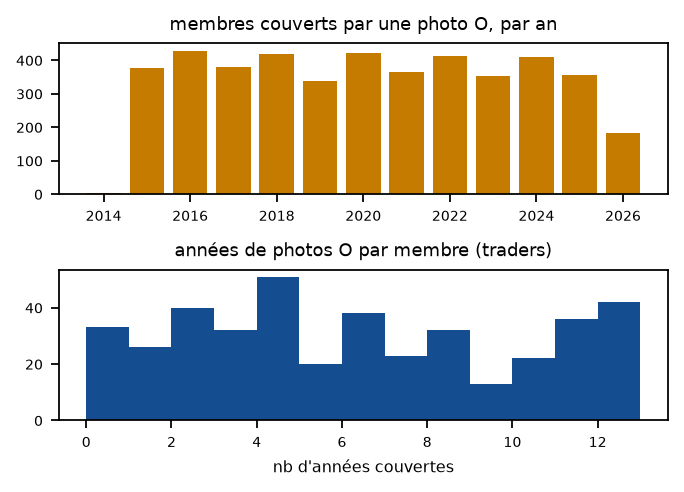

In [38]:
# Figure — la couverture des rapports annuels O (fig_10_couverture_O)
fig, axes = plt.subplots(2, 1, figsize=(FIGCOL, 3.1))
_par_an = (_o12.assign(an=_o12["filing_date"].dt.year).drop_duplicates(["bioguide", "an"])
           .groupby("an").size())
axes[0].bar(_par_an.index, _par_an.values, color="#c47b00")
axes[0].set_title("membres couverts par une photo O, par an")
axes[1].hist(info.loc[info["trade"], "n_annees_O"], bins=range(0, 14), color="#144d90")
axes[1].set_title("années de photos O par membre (traders)")
axes[1].set_xlabel("nb d'années couvertes")
plt.tight_layout(); plt.show()

### La discipline de dépôt — attendu vs observé

Le statut de chaque membre impose des dépôts : **arrivé** dans la fenêtre ⇒ une photo d'entrée H ·
**en mandat un 31/12** ⇒ un rapport annuel O, déposé l'année suivante · **parti** ⇒ un T, qui **tient
lieu de dernier rapport annuel**. Les mandats viennent du référentiel officiel *congress-legislators*
(YAML versionnés dans `reference/` — une donnée, pas une hypothèse). On mesure ici, membre par membre,
l'écart entre ce que la loi attend et ce que nos tables contiennent.

In [39]:
# Les mandats officiels des 900 : années où un rapport annuel O est attendu
import yaml
REF_DIR = os.path.abspath(os.path.join(V1T, "..", "..", "reference"))
_mandats = {}
for _f in ("legislators-current.yaml", "legislators-historical.yaml"):
    for _p in yaml.safe_load(open(os.path.join(REF_DIR, _f))):
        _t = [(x["start"], x["end"]) for x in _p["terms"] if x["type"] == "rep"]
        if _t:
            _mandats[_p["id"]["bioguide"]] = _t
assert reg14["bioguide"].isin(_mandats).all(), "membre du registre absent du référentiel"

def _annees_O_attendues(bid):
    # l'O couvre l'année civile Y (dépôt en Y+1) : attendu si en mandat au 31/12 de Y, Y ∈ 2013-2025
    return sorted({y for (s, e) in _mandats[bid] for y in range(2013, 2026) if s <= f"{y}-12-31" <= e})

regm = reg14.copy()
regm["annees_O_attendues"] = [_annees_O_attendues(b) for b in regm["bioguide"]]
regm["n_O_attendus"] = regm["annees_O_attendues"].str.len()
print(f"mandats : {len(regm)}/900 membres joints au référentiel · "
      f"{int(regm['n_O_attendus'].sum()):,} rapports annuels attendus au total · "
      f"{int((regm['n_O_attendus'] == 0).sum())} membres à 0 attendu (jamais en mandat un 31/12)")
display(regm[["bioguide", "quadrant", "n_O_attendus"]].head(3))

mandats : 900/900 membres joints au référentiel · 5,702 rapports annuels attendus au total · 7 membres à 0 attendu (jamais en mandat un 31/12)


,bioguide,quadrant,n_O_attendus
0,C001087,déjà-là restés,13
1,C001095,déjà-là partis,2
2,C001131,arrivés restés,3


In [40]:
# Validation croisée : le quadrant du registre (construit sur les DÉPÔTS) vs les mandats OFFICIELS
def _actif(bid, d):
    return any(s <= d <= e for s, e in _mandats[bid])
_deja = regm["bioguide"].apply(lambda b: _actif(b, "2014-01-01"))
_reste = regm["bioguide"].apply(lambda b: _actif(b, "2026-01-01"))
_quad_yaml = np.select([_deja & _reste, _deja & ~_reste, ~_deja & _reste, ~_deja & ~_reste],
                       ["déjà-là restés", "déjà-là partis", "arrivés restés", "cycle complet"], default="?")
_acc = (_quad_yaml == regm["quadrant"]).mean()
_dis = regm.loc[_quad_yaml != regm["quadrant"], ["bioguide", "quadrant"]].assign(mandats_officiels=_quad_yaml[_quad_yaml != regm["quadrant"]])
print(f"deux sources INDÉPENDANTES concordent à {_acc:.1%} — les {len(_dis)} désaccords sont des cas de frontière :")
display(_dis)
assert _acc > 0.95

deux sources INDÉPENDANTES concordent à 98.9% — les 10 désaccords sont des cas de frontière :


,bioguide,quadrant,mandats_officiels
96,M001245,arrivés restés,cycle complet
268,C001127,cycle complet,arrivés restés
356,F000485,arrivés restés,cycle complet
396,G000594,cycle complet,arrivés restés
405,G000607,arrivés restés,cycle complet
529,L000578,déjà-là partis,déjà-là restés
611,M001246,arrivés restés,cycle complet
732,S001157,déjà-là partis,déjà-là restés
751,S001193,déjà-là partis,déjà-là restés
863,G000596,cycle complet,arrivés restés


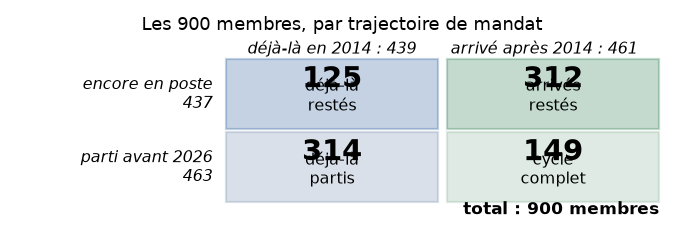

In [41]:
# Figure — le quadrant des 900, avec marges (fig_10_quadrant)
# lignes = resté / parti · colonnes = déjà-là / arrivé : chaque marge est écrite le long de
# ce qu'elle somme (marge de ligne à gauche de SA ligne, marge de colonne au-dessus de SA colonne)
_q = regm["quadrant"].value_counts()
_dl_r, _dl_p = int(_q["déjà-là restés"]), int(_q["déjà-là partis"])
_ar_r, _cc = int(_q["arrivés restés"]), int(_q["cycle complet"])
fig, ax = plt.subplots(figsize=(FIGCOL, 1.5))
_cases = [(0, 1, _dl_r, "déjà-là\nrestés", "#144d90"), (1, 1, _ar_r, "arrivés\nrestés", "#146e3c"),
          (0, 0, _dl_p, "déjà-là\npartis", "#6d86a8"), (1, 0, _cc, "cycle\ncomplet", "#7fae92")]
for _x, _y, _n, _t, _c in _cases:
    ax.add_patch(plt.Rectangle((_x, _y), 0.96, 0.96, color=_c, alpha=0.25))
    ax.text(_x + 0.48, _y + 0.58, f"{_n}", ha="center", fontsize=13, weight="bold")
    ax.text(_x + 0.48, _y + 0.26, _t, ha="center", fontsize=7)
# marges de LIGNE (à gauche de chaque ligne) : resté / parti
ax.text(-0.06, 1.48, f"encore en poste\n{_dl_r + _ar_r}", ha="right", va="center", fontsize=7, style="italic")
ax.text(-0.06, 0.48, f"parti avant 2026\n{_dl_p + _cc}", ha="right", va="center", fontsize=7, style="italic")
# marges de COLONNE (au-dessus de chaque colonne) : déjà-là / arrivé
ax.text(0.48, 2.04, f"déjà-là en 2014 : {_dl_r + _dl_p}", ha="center", fontsize=7, style="italic")
ax.text(1.44, 2.04, f"arrivé après 2014 : {_ar_r + _cc}", ha="center", fontsize=7, style="italic")
ax.text(1.96, -0.16, f"total : {len(regm)} membres", ha="right", fontsize=7.5, weight="bold")
ax.set_xlim(-0.95, 2.0); ax.set_ylim(-0.24, 2.18); ax.axis("off")
ax.set_title("Les 900 membres, par trajectoire de mandat")
plt.tight_layout(); plt.show()
assert _dl_r + _ar_r + _dl_p + _cc == len(regm)

In [42]:
# Couverture des rapports annuels, membre par membre : O déposés ∪ T (qui tient lieu de dernier rapport)
_oT = ph12[ph12["filing_type"].isin(["O", "T"])].copy()
_oT["an_couvert"] = _oT["filing_date"].dt.year - 1        # convention : un rapport déposé en Y couvre Y-1
_vues = _oT.groupby("bioguide")["an_couvert"].agg(set)
regm["annees_vues"] = regm["bioguide"].map(_vues).apply(lambda s: s if isinstance(s, set) else set())
regm["n_O_couverts"] = [len(set(a) & v) for a, v in zip(regm["annees_O_attendues"], regm["annees_vues"])]
regm["taux_O"] = regm["n_O_couverts"] / regm["n_O_attendus"].replace(0, np.nan)
_tranches = pd.cut(regm.loc[regm["n_O_attendus"] > 0, "taux_O"], [-0.01, 0, 0.5, 0.999, 1.001],
                   labels=["0 %", "1-50 %", "51-99 %", "100 %"])
display(_tranches.value_counts().sort_index().to_frame("membres"))
print(f"taux de couverture médian : {regm['taux_O'].median():.0%} — médiane par quadrant :")
display(regm.groupby("quadrant")["taux_O"].median().map("{:.0%}".format).to_frame("taux médian"))

,membres
taux_O,
0 %,79
1-50 %,85
51-99 %,517
100 %,212


taux de couverture médian : 85% — médiane par quadrant :


,taux médian
quadrant,
arrivés restés,86%
cycle complet,100%
déjà-là partis,83%
déjà-là restés,92%


In [43]:
# LE tableau central : attendu vs observé, par trajectoire de mandat
_att_photo = regm["quadrant"].isin(["arrivés restés", "cycle complet"])   # arrivé ⇒ photo d'entrée attendue
_att_T = regm["quadrant"].isin(["déjà-là partis", "cycle complet"])       # parti ⇒ T attendu
_obs_photo = regm["bioguide"].isin(set(e15["bioguide"]))   # photo d'entrée re-sélectionnée (élec + OCR)
_obs_T = regm["bioguide"].isin(set(ph12.loc[ph12["filing_type"] == "T", "bioguide"]))
_obs_O = regm["n_O_couverts"] > 0
_obs_P = regm["bioguide"].isin(set(cl.loc[cl["chamber"] == "house", "bioguide_id"]))
crosstab_central = (regm.assign(photo_obs=_obs_photo, photo_att=_att_photo, T_obs=_obs_T, T_att=_att_T,
                                O_obs=_obs_O, P_obs=_obs_P)
                    .groupby("quadrant")
                    .agg(n=("bioguide", "size"),
                         photo_entree=("photo_obs", "sum"), photo_attendue=("photo_att", "sum"),
                         T=("T_obs", "sum"), T_attendu=("T_att", "sum"),
                         O_1plus=("O_obs", "sum"), PTR_1plus=("P_obs", "sum"),
                         taux_O_med=("taux_O", "median"))
                    .reindex(["déjà-là restés", "déjà-là partis", "arrivés restés", "cycle complet"]))
crosstab_central.loc["TOTAL"] = crosstab_central.sum()
crosstab_central.loc["TOTAL", "taux_O_med"] = regm["taux_O"].median()
display(crosstab_central.astype({c: int for c in crosstab_central.columns if c != "taux_O_med"}, errors="ignore"))
assert int(crosstab_central.loc["TOTAL", "n"]) == 900
assert int(crosstab_central.loc["TOTAL", "photo_entree"]) == len(e15)
_manq_ph = int((_att_photo & ~_obs_photo).sum()); _manq_T = int((_att_T & ~_obs_T).sum())
_hors_ph = int((~_att_photo & _obs_photo).sum()); _hors_T = int((~_att_T & _obs_T).sum())
print(f"photo d'entrée : {int((_att_photo & _obs_photo).sum())}/{int(_att_photo.sum())} attendues présentes "
      f"→ {_manq_ph} manquantes · {_hors_ph} photos chez des non-attendus (journal)")
print(f"T : {int((_att_T & _obs_T).sum())}/{int(_att_T.sum())} attendus présents "
      f"→ {_manq_T} manquants · {_hors_T} T chez des restés (fins de mandat de bord)")

,n,photo_entree,photo_attendue,T,T_attendu,O_1plus,PTR_1plus,taux_O_med
quadrant,,,,,,,,
déjà-là restés,125,5,0,4,0,123,59,0.923077
déjà-là partis,314,1,0,253,314,299,100,0.833333
arrivés restés,312,223,312,3,0,250,108,0.857143
cycle complet,149,96,149,114,149,142,48,1.000000
TOTAL,900,325,461,374,463,814,315,0.846154


photo d'entrée : 319/461 attendues présentes → 142 manquantes · 6 photos chez des non-attendus (journal)
T : 367/463 attendus présents → 96 manquants · 7 T chez des restés (fins de mandat de bord)


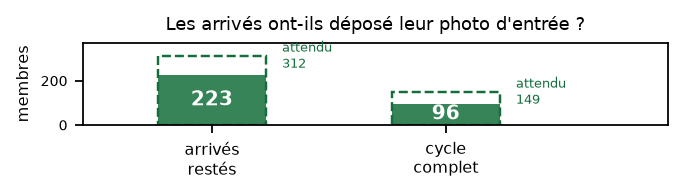

In [44]:
# Figure — ÉTAPE 1 il arrive : la photo d'entrée attendue vs observée (fig_10_etape_arrivee)
def barres_attendu_observe(quads, col_obs, col_att, couleur, titre):
    """Une barre pleine (observé) devant une barre en pointillés (attendu), par trajectoire."""
    _x = np.arange(len(quads))
    fig, ax = plt.subplots(figsize=(FIGCOL, 1.25))
    _a = crosstab_central.loc[quads, col_att].astype(int)
    _o = crosstab_central.loc[quads, col_obs].astype(int)
    ax.bar(_x, _a, width=0.46, fill=False, edgecolor=couleur, ls="--", lw=1.1)
    ax.bar(_x, _o, width=0.46, color=couleur, alpha=0.85)
    for _i, (_va, _vo) in enumerate(zip(_a, _o)):
        ax.text(_i, _vo / 2, f"{_vo}", ha="center", va="center", color="white", fontsize=9, weight="bold")
        ax.text(_i + 0.30, _va, f"attendu\n{_va}", ha="left", va="center", fontsize=6, color=couleur)
    ax.set_xticks(_x); ax.set_xticklabels([q.replace(" ", "\n") for q in quads], fontsize=7)
    ax.set_xlim(-0.55, len(quads) - 0.05); ax.set_ylim(0, _a.max() * 1.18)
    ax.set_ylabel("membres"); ax.set_title(titre)
    plt.tight_layout(); plt.show()

barres_attendu_observe(["arrivés restés", "cycle complet"], "photo_entree", "photo_attendue",
                       "#146e3c", "Les arrivés ont-ils déposé leur photo d'entrée ?")

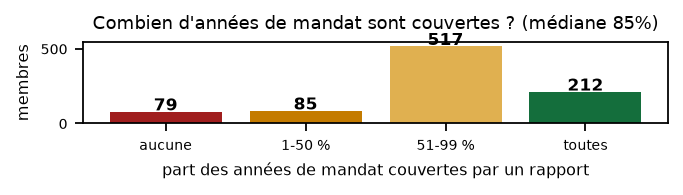

In [45]:
# Figure — ÉTAPE ③ il déclare : la couverture des rapports annuels (fig_10_etape_annuel)
_tr = pd.cut(regm.loc[regm["n_O_attendus"] > 0, "taux_O"], [-0.01, 0, 0.5, 0.999, 1.001],
             labels=["aucune", "1-50 %", "51-99 %", "toutes"]).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(FIGCOL, 1.25))
_cols = ["#a01e1e", "#c47b00", "#e0b050", "#146e3c"]
ax.bar(_tr.index.astype(str), _tr.values, color=_cols)
for _i, _v in enumerate(_tr.values):
    ax.text(_i, _v + 8, f"{_v}", ha="center", fontsize=7.5, weight="bold")
ax.set_ylabel("membres"); ax.set_xlabel("part des années de mandat couvertes par un rapport")
ax.set_title(f"Combien d'années de mandat sont couvertes ? (médiane {regm['taux_O'].median():.0%})")
plt.tight_layout(); plt.show()

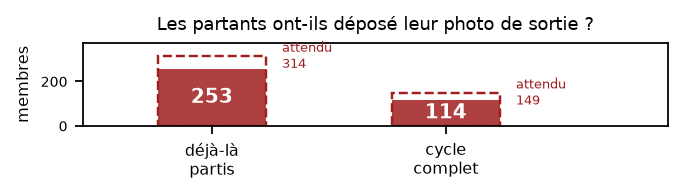

In [46]:
# Figure — ÉTAPE 4 il part : la photo de sortie attendue vs observée (fig_10_etape_sortie)
barres_attendu_observe(["déjà-là partis", "cycle complet"], "T", "T_attendu",
                       "#a01e1e", "Les partants ont-ils déposé leur photo de sortie ?")

In [47]:
# Qui trade, par trajectoire de mandat — et déclarer sans trader
_s_ptr = set(df["bioguide_id"]); _s_oat = set(df_oat["bioguide_id"])
_statut = np.select([regm["bioguide"].isin(_s_ptr), regm["bioguide"].isin(_s_oat - _s_ptr)],
                    ["trade, vu par les PTR", "trade, vu SEULEMENT par les O/A/T"],
                    default="ne trade pas d'actions cotées")
trade_x_quad = pd.crosstab(regm["quadrant"], pd.Series(_statut, index=regm.index, name="statut"), margins=True)
display(trade_x_quad)
_nt = regm.loc[_statut == "ne trade pas d'actions cotées"]
_nt_O = int((_nt["n_O_couverts"] > 0).sum())
print(f"parmi les {len(_nt)} membres qui ne tradent pas : {_nt_O} ({_nt_O/len(_nt):.0%}) déposent quand même "
      f"des rapports annuels — ne pas trader n'est pas ne pas déclarer")

statut,ne trade pas d'actions cotées,"trade, vu SEULEMENT par les O/A/T","trade, vu par les PTR",All
quadrant,,,,
arrivés restés,171,36,105,312
cycle complet,85,16,48,149
déjà-là partis,196,23,95,314
déjà-là restés,57,11,57,125
All,509,86,305,900


parmi les 509 membres qui ne tradent pas : 444 (87%) déposent quand même des rapports annuels — ne pas trader n'est pas ne pas déclarer


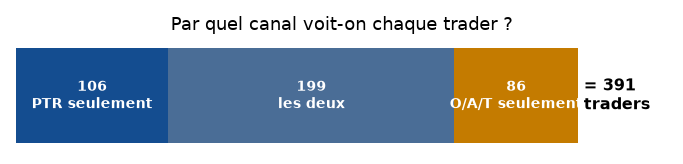

In [48]:
# Figure — les trois zones de la population qui trade (fig_10_trois_zones)
_z_ptr_seul = len(_s_ptr - _s_oat); _z_deux = len(_s_ptr & _s_oat); _z_oat_seul = len(_s_oat - _s_ptr)
assert _z_ptr_seul + _z_deux + _z_oat_seul == len(_s_ptr | _s_oat)
fig, ax = plt.subplots(figsize=(FIGCOL, 1.05))
_gauche = 0
for _n, _lab, _c in [(_z_ptr_seul, "PTR seulement", "#144d90"), (_z_deux, "les deux", "#4a6d96"),
                     (_z_oat_seul, "O/A/T seulement", "#c47b00")]:
    ax.barh(0, _n, left=_gauche, color=_c, height=0.55)
    ax.text(_gauche + _n / 2, 0, f"{_n}\n{_lab}", ha="center", va="center", fontsize=6.5,
            color="white", weight="bold")
    _gauche += _n
ax.text(_gauche + 4, 0, f"= {_gauche}\ntraders", va="center", fontsize=7, weight="bold")
ax.set_xlim(0, _gauche * 1.16); ax.axis("off")
ax.set_title("Par quel canal voit-on chaque trader ?")
plt.tight_layout(); plt.show()

In [49]:
# Bouclage : chaque membre a-t-il laissé AU MOINS une trace ? et qui sont les inconnus de la table 12 ?
_s_house_decl = set(cl.loc[cl["chamber"] == "house", "bioguide_id"])
_avec_doc = (regm["bioguide"].isin(set(ph12["bioguide"])) | regm["bioguide"].isin(_s_house_decl)
             | regm["bioguide"].isin(set(f16["bioguide"])))
_sans = regm.loc[~_avec_doc]
print(f"{len(_sans)} membres du registre sans AUCUN document (ni photo, ni PTR, ni O/A/T) — par quadrant :")
display(_sans["quadrant"].value_counts().to_frame("membres"))
_b12 = set(ph12["bioguide"].dropna())
print(f"réciproquement, la table 12 contient {len(_b12)} déposants : {len(_b12 & set(regm['bioguide']))} membres "
      f"du registre + {len(_b12 - set(regm['bioguide']))} candidats jamais élus (photos C sans mandat)")
assert len(_sans) + int(_avec_doc.sum()) == 900

18 membres du registre sans AUCUN document (ni photo, ni PTR, ni O/A/T) — par quadrant :


,membres
quadrant,
déjà-là partis,10
arrivés restés,5
déjà-là restés,2
cycle complet,1


réciproquement, la table 12 contient 887 déposants : 875 membres du registre + 12 candidats jamais élus (photos C sans mandat)


In [50]:
# Les délais administratifs : entrée en mandat → dépôt du H · fin de mandat → dépôt du T
_h = e15.loc[e15["type_photo"] == "H", ["bioguide", "filing_date"]].copy()
_h["delai_j"] = [min(((fd - pd.Timestamp(s)).days for s, e in _mandats[b] if pd.Timestamp(s) <= fd),
                     default=np.nan) for b, fd in zip(_h["bioguide"], _h["filing_date"])]
_t12 = ph12[ph12["filing_type"] == "T"].sort_values("filing_date").drop_duplicates("bioguide", keep="last")
_t12 = _t12[_t12["bioguide"].isin(_mandats)].copy()
_t12["delai_j"] = [min(((fd - pd.Timestamp(e)).days for s, e in _mandats[b]), key=abs, default=np.nan)
                   for b, fd in zip(_t12["bioguide"], _t12["filing_date"])]
print(f"entrée en mandat → dépôt du H : médiane {_h['delai_j'].median():.0f} j (n = {int(_h['delai_j'].notna().sum())}) — "
      f"la photo d'entrée arrive des MOIS après l'entrée")
print(f"fin de mandat → dépôt du T : médiane {_t12['delai_j'].median():.0f} j (n = {len(_t12)})")

entrée en mandat → dépôt du H : médiane 213 j (n = 258) — la photo d'entrée arrive des MOIS après l'entrée
fin de mandat → dépôt du T : médiane 34 j (n = 374)


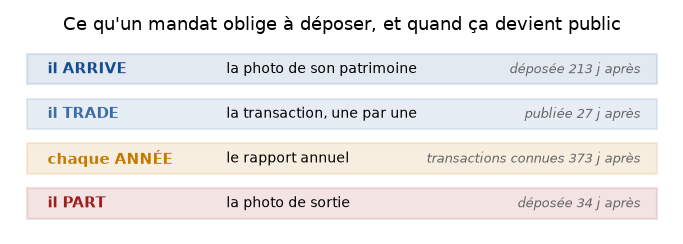

In [51]:
# Figure — les quatre obligations d'un mandat, et le délai de chacune (fig_10_obligations)
# Tous les délais sortent des cellules précédentes : aucun n'est écrit en dur.
_d_h, _d_t = float(_h["delai_j"].median()), float(_t12["delai_j"].median())
_dp = (cl.loc[cl["chamber"] == "house", ["transaction_date", "disclosure_date"]].dropna())
_dp = (_dp["disclosure_date"] - _dp["transaction_date"]).dt.days
_d_ptr_med = float(_dp[_dp.between(0, 1500)].median())
_do = (f16["disclosure_date"] - f16["transaction_date"]).dt.days
_d_oat_med = float(_do[_do.between(0, 1500)].median())
_obl = [("il ARRIVE",    "la photo de son patrimoine", f"déposée {_d_h:.0f} j après",  "#144d90"),
        ("il TRADE",     "la transaction, une par une", f"publiée {_d_ptr_med:.0f} j après", "#3a6ea5"),
        ("chaque ANNÉE", "le rapport annuel",          f"transactions connues {_d_oat_med:.0f} j après", "#c47b00"),
        ("il PART",      "la photo de sortie",         f"déposée {_d_t:.0f} j après",  "#a01e1e")]
fig, ax = plt.subplots(figsize=(FIGCOL, 1.55))
for _i, (_quand, _quoi, _delai, _c) in enumerate(_obl):
    _y = len(_obl) - 1 - _i
    ax.add_patch(plt.Rectangle((0, _y - 0.34), 3.0, 0.68, color=_c, alpha=0.12))
    ax.text(0.10, _y, _quand, fontsize=6.8, weight="bold", color=_c, va="center")
    ax.text(0.95, _y, _quoi, fontsize=6.5, va="center")
    ax.text(2.92, _y, _delai, fontsize=5.9, color="#666666", ha="right", va="center", style="italic")
ax.set_xlim(-0.05, 3.05); ax.set_ylim(-0.55, len(_obl) - 0.42); ax.axis("off")
ax.set_title("Ce qu'un mandat oblige à déposer, et quand ça devient public")
plt.tight_layout(); plt.show()

In [52]:
# L'inventaire documentaire : combien de DOCUMENTS de chaque type (l'unité est le dépôt, pas la ligne)
_n_dep_p = cl.loc[cl["chamber"] == "house", ["bioguide_id", "disclosure_date"]].drop_duplicates().shape[0]
_n_docs_A = f16.loc[f16["filing_type"] == "A", "doc_id"].nunique()
inventaire = pd.DataFrame([
    ("H (photo d'entrée)", int((ph12["filing_type"] == "H").sum()), "documents"),
    ("C (photo de candidat)", int((ph12["filing_type"] == "C").sum()), "documents"),
    ("O (rapport annuel)", int((ph12["filing_type"] == "O").sum()), "documents"),
    ("T (photo de sortie)", int((ph12["filing_type"] == "T").sum()), "documents"),
    ("P (dépôts PTR)", _n_dep_p, "≈ paires (membre, date de divulgation) — le doc_id n'est pas dans la table clean"),
    ("A (amendements)", _n_docs_A, "documents PORTEURS de flux net seulement (table 16)"),
], columns=["type", "n", "unité exacte"]).set_index("type")
display(inventaire)
assert e15["bioguide"].is_unique and e15["doc_id"].is_unique
print(f"photos d'entrée retenues : {len(e15)} documents = {len(e15)} membres (1 photo par membre, asserté)")

,n,unité exacte
type,,
H (photo d'entrée),376,documents
C (photo de candidat),934,documents
O (rapport annuel),4447,documents
T (photo de sortie),378,documents
P (dépôts PTR),5571,"≈ paires (membre, date de divulgation) — le do..."
A (amendements),139,documents PORTEURS de flux net seulement (tabl...


photos d'entrée retenues : 325 documents = 325 membres (1 photo par membre, asserté)


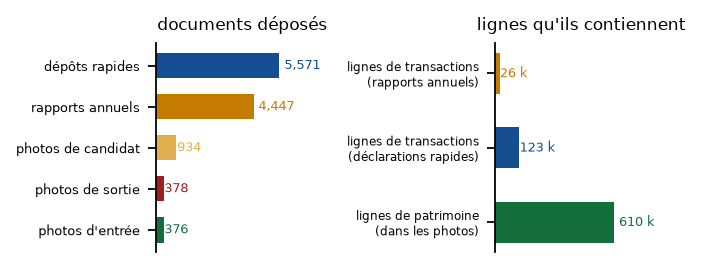

In [53]:
# Figure — ce que contiennent les dépôts : documents et lignes (fig_10_inventaire)
fig, axes = plt.subplots(1, 2, figsize=(FIGCOL, 1.7))
_docs = [("rapports annuels", int((ph12["filing_type"] == "O").sum()), "#c47b00"),
         ("photos de candidat", int((ph12["filing_type"] == "C").sum()), "#e0b050"),
         ("dépôts rapides", _n_dep_p, "#144d90"),
         ("photos de sortie", int((ph12["filing_type"] == "T").sum()), "#a01e1e"),
         ("photos d'entrée", int((ph12["filing_type"] == "H").sum()), "#146e3c")]
_docs.sort(key=lambda x: x[1])
axes[0].barh(range(len(_docs)), [d[1] for d in _docs], color=[d[2] for d in _docs], height=0.62)
for _i, (_lab, _n, _c) in enumerate(_docs):
    axes[0].text(_n * 1.04, _i, f"{_n:,}", va="center", fontsize=6, color=_c)
axes[0].set_yticks(range(len(_docs))); axes[0].set_yticklabels([d[0] for d in _docs], fontsize=6)
axes[0].set_xlim(0, max(d[1] for d in _docs) * 1.4); axes[0].set_xticks([])
axes[0].set_title("documents déposés", fontsize=7.5)
_lig = [("lignes de patrimoine\n(dans les photos)", len(h11), "#146e3c"),
        ("lignes de transactions\n(déclarations rapides)", len(cl[cl["chamber"] == "house"]), "#144d90"),
        ("lignes de transactions\n(rapports annuels)", len(f16), "#c47b00")]
axes[1].barh(range(len(_lig)), [l[1] for l in _lig], color=[l[2] for l in _lig], height=0.55)
for _i, (_lab, _n, _c) in enumerate(_lig):
    axes[1].text(_n * 1.04, _i, f"{_n/1000:.0f} k", va="center", fontsize=6, color=_c)
axes[1].set_yticks(range(len(_lig))); axes[1].set_yticklabels([l[0] for l in _lig], fontsize=5.5)
axes[1].set_xlim(0, max(l[1] for l in _lig) * 1.45); axes[1].set_xticks([])
axes[1].set_title("lignes qu'ils contiennent", fontsize=7.5)
for _ax in axes:
    for _s in ("top", "right", "bottom"):
        _ax.spines[_s].set_visible(False)
plt.tight_layout(); plt.show()

choisi : Garret Graves (G000577) — cycle complet le mieux équipé (10 années O couvertes, 11 trades PTR)


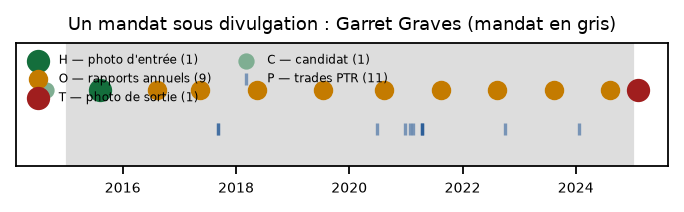

In [54]:
# Figure — la frise d'un membre réel (fig_10_frise_membre) : critère de choix AFFICHÉ
_cands = regm[(regm["quadrant"] == "cycle complet") & regm["a_photo_entree"].astype(bool)
              & regm["bioguide"].isin(set(ph12.loc[ph12["filing_type"] == "T", "bioguide"]))
              & (regm["n_O_couverts"] > 0) & regm["bioguide"].isin(set(df["bioguide_id"]))]
_cands = (_cands.assign(n_ptr=_cands["bioguide"].map(df.groupby("bioguide_id").size()))
          .sort_values(["n_O_couverts", "n_ptr"], ascending=False))
_bf = _cands.iloc[0]["bioguide"]
_nomf = df.loc[df["bioguide_id"] == _bf, "name"].iloc[0]
print(f"choisi : {_nomf} ({_bf}) — cycle complet le mieux équipé "
      f"({int(_cands.iloc[0]['n_O_couverts'])} années O couvertes, {int(_cands.iloc[0]['n_ptr'])} trades PTR)")
fig, ax = plt.subplots(figsize=(FIGCOL, 1.35))
for _s, _e in _mandats[_bf]:
    ax.axvspan(pd.Timestamp(_s), pd.Timestamp(_e), color="#dddddd", zorder=0)
_docs_f = ph12[ph12["bioguide"] == _bf]
_style = {"H": ("#146e3c", "H — photo d'entrée", 90), "O": ("#c47b00", "O — rapports annuels", 60),
          "T": ("#a01e1e", "T — photo de sortie", 90), "C": ("#7fae92", "C — candidat", 40)}
for _ft, (_c, _lab, _sz) in _style.items():
    _d = _docs_f.loc[_docs_f["filing_type"] == _ft, "filing_date"]
    if len(_d):
        ax.scatter(_d, [0.62] * len(_d), color=_c, s=_sz, zorder=3, label=f"{_lab} ({len(_d)})")
_ptr_d = df.loc[df["bioguide_id"] == _bf, "traded"]
ax.scatter(_ptr_d, np.full(len(_ptr_d), 0.3), marker="|", color="#144d90", s=28, alpha=0.5,
           label=f"P — trades PTR ({len(_ptr_d)})")
ax.set_ylim(0, 1); ax.set_yticks([])
ax.legend(frameon=False, fontsize=5.2, loc="upper left", ncol=2)
ax.set_title(f"Un mandat sous divulgation : {_nomf} (mandat en gris)")
plt.tight_layout(); plt.show()

### P1.1 Validation
Livre de comptes membres asserté ci-dessus (900 = PTR + oat-only + sans trade) · matrice = partition exhaustive du registre · non-régression PTR (107 976 / 305) vérifiée dans le livre · mandats officiels : 900/900 joints, quadrant concordant avec les dépôts à ~99 % (désaccords journalisés) · crosstab attendu/observé asserté (TOTAL = 900, photos = table 15) · trois zones sommées = population qui trade · bouclage : sans-document + avec-document = 900.

## P2 — Les transactions : ce que les PTR ratent

In [55]:
# LIVRE DE COMPTES O/A/T — chaque ligne écartée a une raison, et une seule (asserts)
_lc = f16.rename(columns={"bioguide": "bioguide_id", "transaction_date": "traded"}).copy()
_lc["ty"] = _lc["ticker"].map(to_yahoo)
_lc["op"] = _lc["sens"].map({"P": "buy", "S": "sell"})
_r_exch = _lc["op"].isna()
_r_date = ~_r_exch & ~_lc["traded"].dt.year.between(2013, 2026)
_r_mont = ~_r_exch & ~_r_date & ~(_lc["amount_mid_conventionnel"] > 0)
_avant  = ~(_r_exch | _r_date | _r_mont)
_r_faux = _avant & (_lc["classe"] == "faux_ticker")
_r_mone = _avant & (_lc["classe"] == "monetaire")
_r_fond = _avant & (_lc["classe"] == "fonds")
_nego   = _avant & (_lc["classe"] == "negociable")
_r_corr = _nego & _lc["ty"].isin(_corrompus)
_r_prix = _nego & ~_r_corr & ~_lc["ty"].isin(prices)
_okm    = _nego & ~_r_corr & ~_r_prix
_k = ["bioguide_id", "ty", "op", "traded"]
_cles_ptr = df.rename(columns={"ticker": "ty"})[_k]
_hit = _lc[_okm].merge(_cles_ptr.drop_duplicates().assign(_h=1), on=_k, how="left")["_h"].notna()
_n_coll_lignes = int(_hit.sum())
_n_appar = len(_lc[_okm].merge(_cles_ptr, on=_k, how="inner"))
_n_ok = int(_okm.sum()) - _n_coll_lignes
livre_oat = pd.DataFrame([
    ("lignes table 16 (trades O/A/T sans écho PTR côté v1)", len(_lc), ""),
    ("− exchanges (sens E : ni achat ni vente)", -int(_r_exch.sum()), ""),
    ("− date hors fenêtre 2013-2026 (dates corrompues)", -int(_r_date.sum()), ""),
    ("− sans montant exploitable", -int(_r_mont.sum()), ""),
    ("− FAUX TICKERS (codes de formulaire / libellés de compte)", -int(_r_faux.sum()),
     "EIF, SP, DC, JT… — jamais des instruments"),
    ("− monétaires (cash sweep : SPAXX, FDRXX…)", -int(_r_mone.sum()), "du cash, pas des trades"),
    ("− fonds mutuels (NAV, non négociables en bourse)", -int(_r_fond.sum()),
     "comptés, mais HORS moteur equity"),
    ("− ticker corrompu (garde-fou prix)", -int(_r_corr.sum()), ""),
    ("− aucune série de prix (après re-test de la failed-list)", -int(_r_prix.sum()),
     f"dont {int((_r_prix & _lc['asset_description'].astype(str).str.contains(RE_COMPTE, na=False)).sum())} libellés de compte (ticker probablement hérité)"),
    ("− en collision exacte avec un PTR de NOTRE table", -_n_coll_lignes,
     f"{_n_appar} appariements"),
    ("= TRADES O/A/T RETENUS (négociables, avec prix)", _n_ok, "provenance = oat"),
], columns=["marche", "n", "note"]).set_index("marche")
display(livre_oat)
assert len(_lc) - int(_r_exch.sum()) - int(_r_date.sum()) - int(_r_mont.sum()) \
       - int(_r_faux.sum()) - int(_r_mone.sum()) - int(_r_fond.sum()) \
       - int(_r_corr.sum()) - int(_r_prix.sum()) - _n_coll_lignes == _n_ok
assert _n_ok == len(df_oat) == int((df_uni["provenance"] == "oat").sum()), "livre ≠ df_oat"
print(f"✅ identité : {len(_lc):,} − marches = {_n_ok:,} = |df_oat| = lignes oat de F")

,n,note
marche,,
lignes table 16 (trades O/A/T sans écho PTR côté v1),26115,
− exchanges (sens E : ni achat ni vente),-221,
− date hors fenêtre 2013-2026 (dates corrompues),-14,
− sans montant exploitable,0,
− FAUX TICKERS (codes de formulaire / libellés de compte),-290,"EIF, SP, DC, JT… — jamais des instruments"
"− monétaires (cash sweep : SPAXX, FDRXX…)",-364,"du cash, pas des trades"
"− fonds mutuels (NAV, non négociables en bourse)",-9345,"comptés, mais HORS moteur equity"
− ticker corrompu (garde-fou prix),-43,
− aucune série de prix (après re-test de la failed-list),-1275,dont 700 libellés de compte (ticker probableme...


✅ identité : 26,115 − marches = 14,084 = |df_oat| = lignes oat de F


In [56]:
# RÉCONCILIATION avec l'ancien moteur (avant classification) : parmi les lignes écartées PAR NATURE
# (faux tickers, monétaires, fonds), combien ont une série de prix en cache ? L'ancien filtre « a un
# prix » les laissait ENTRER dans le moteur equity — un fonds a une NAV chez Yahoo, c'est le piège.
_exclu = _lc[_r_faux | _r_mone | _r_fond].copy()
_serie = _exclu["ty"].isin(_have_v2 | _have_ph)
print(f"écartées par la classe : {len(_exclu):,} lignes · {_exclu['amount_mid_conventionnel'].sum()/1e6:,.0f} M$")
print(f"dont {int(_serie.sum()):,} lignes ({_exclu.loc[_serie, 'amount_mid_conventionnel'].sum()/1e6:,.0f} M$) "
      f"avec une série en cache → l'ancien moteur les valorisait comme des actions ; v8 les écarte par nature")
display(_exclu.loc[_serie, "ticker"].value_counts().head(8).rename("lignes").to_frame())


écartées par la classe : 9,999 lignes · 817 M$
dont 7,709 lignes (486 M$) avec une série en cache → l'ancien moteur les valorisait comme des actions ; v8 les écarte par nature


,lignes
ticker,
MEIIX,106
FXAIX,69
FHARX,55
VWALX,52
GOFXX,50
FFFEX,47
PIMIX,44
DODGX,42


**Les délais de divulgation, recalculés ici** : quand l'information devient-elle publique ?

délai médian : PTR 27 j (q90 49) · O/A/T 373 j (q90 540)


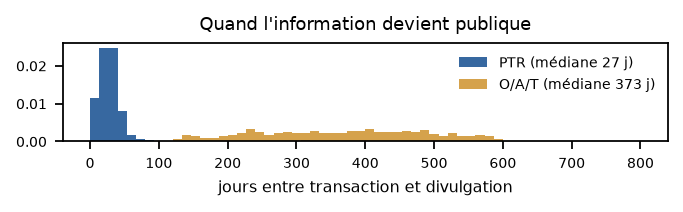

In [57]:
# Délais transaction → divulgation : PTR vs O/A/T (fig_10_delais)
_d_ptr = (cl.loc[cl["chamber"] == "house", ["transaction_date", "disclosure_date"]].dropna())
_d_ptr = (_d_ptr["disclosure_date"] - _d_ptr["transaction_date"]).dt.days
_d_ptr = _d_ptr[_d_ptr.between(0, 1500)]
_d_oat = (f16["disclosure_date"] - f16["transaction_date"]).dt.days
_d_oat = _d_oat[_d_oat.between(0, 1500)]
print(f"délai médian : PTR {_d_ptr.median():.0f} j (q90 {_d_ptr.quantile(.9):.0f}) · "
      f"O/A/T {_d_oat.median():.0f} j (q90 {_d_oat.quantile(.9):.0f})")
fig, ax = plt.subplots(figsize=(FIGCOL, 1.35))
ax.hist(_d_ptr, bins=60, range=(0, 800), color="#144d90", alpha=0.85, density=True,
        label=f"PTR (médiane {_d_ptr.median():.0f} j)")
ax.hist(_d_oat, bins=60, range=(0, 800), color="#c47b00", alpha=0.70, density=True,
        label=f"O/A/T (médiane {_d_oat.median():.0f} j)")
ax.legend(frameon=False); ax.set_xlabel("jours entre transaction et divulgation")
ax.set_title("Quand l'information devient publique")
plt.tight_layout(); plt.show()

In [58]:
# Qui apporte quoi : comptes par année × provenance × sens, et top apporteurs
display(pd.crosstab(df_uni["traded"].dt.year, [df_uni["provenance"], df_uni["op"]]).tail(13))
_top = (df_uni.assign(n=1)
        .pivot_table(index=["bioguide_id", "name"], columns="provenance", values="n",
                     aggfunc="sum", fill_value=0)
        .assign(part_oat=lambda d: d["oat"] / (d["oat"] + d["ptr"]))
        .sort_values("oat", ascending=False))
display(_top.head(8).style.format({"part_oat": "{:.0%}"}))

provenance   oat      oat_ocr         ptr      
op           buy sell     buy  sell   buy  sell
traded                                         
2014         392  339     783   874  3563  2780
2015         544  387     682  1217  3116  3135
2016         306  320     643   340  2591  2273
2017         461  378     387   263  4664  3743
2018         510  522     267   339  5267  5062
2019         715  496     167   232  4604  4560
2020         785  674     226   206  5971  5722
2021         645  427     117   121  4825  4599
2022         750  534     110   104  5313  4895
2023        1241  920      24     9  3573  4192
2024        1059  834      94    14  3590  3280
2025         507  321      12     1  5487  6039
2026          12    4       0     0  2262  2368

,provenance,oat,oat_ocr,ptr,part_oat
bioguide_id,name,,,,
G000535,Luis V. Gutierrez,792,0,21,97%
M001201,Paul Mitchell,744,0,2,100%
M001135,Kathy Manning,542,0,729,43%
G000583,Josh Gottheimer,437,0,3054,13%
T000463,Michael R. Turner,367,0,2,99%
C001066,Kathy Castor,362,0,79,82%
W000800,Peter Welch,307,0,152,67%
B001303,Lisa Blunt Rochester,301,0,0,100%


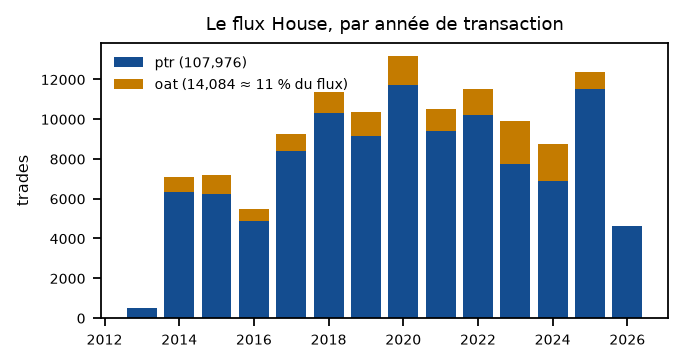

In [59]:
# Figure — le flux unifié par année (fig_10_flux)
_ct = pd.crosstab(df_uni["traded"].dt.year, df_uni["provenance"])
fig, ax = plt.subplots(figsize=(FIGCOL, 2.3))
ax.bar(_ct.index, _ct["ptr"], color="#144d90", label=f"ptr ({_ct['ptr'].sum():,})")
ax.bar(_ct.index, _ct["oat"], bottom=_ct["ptr"], color="#c47b00",
       label=f"oat ({_ct['oat'].sum():,} ≈ {100*_ct['oat'].sum()/len(df_uni):.0f} % du flux)")
ax.set_title("Le flux House, par année de transaction")
ax.set_ylabel("trades"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

### P2.1 Validation
Livre de comptes O/A/T asserté (26 115 − marches = retenus = lignes oat de F) · les délais confirment la nature des sources : le PTR est un signal (~1 mois), l'annuel un enregistrement (~1 an).

## P3 — La reconstruction : le portefeuille de chaque membre

**G_zéro** (sans photo) : départ h = 0. **G_photo** : départ = portefeuille d'entrée, injecté au jour du **dépôt** :
$$h_0(m,i) = \tilde v_i / P_i(\tau(f_0)) \qquad \text{achat : } h \mathrel{+}= \tilde v/P(\tau(t)) \qquad \text{vente : } h \mathrel{-}= \min(q, h)$$

In [60]:
# h0_parts : une ligne par (membre, ticker) initialisable — q0 = mid / P(tau(f0))
def eff_price(tk, d):
    if tk not in prices: return None, None
    s = prices[tk]; pos = s.index.searchsorted(d)
    if pos >= len(s): return None, None
    p = s.iloc[pos]
    return (s.index[pos], p) if np.isfinite(p) and p > 0 else (None, None)

# h0 est construit pour TOUS les membres à photo exploitable (la restriction se fait PAR RUN,
# au moteur : la photo n'est injectée que si le membre a >= 1 trade dans le flux du run)
_rows, _v_ok = [], 0.0
for _r in ph_ent.itertuples():
    _t0, _p = eff_price(_r.ticker_y, _r.filing_date)
    if _t0 is None: continue
    _rows.append(dict(bioguide_id=_r.bioguide, ticker=_r.ticker_y, q0=_r.mid / _p, t0=_t0))
    _v_ok += _r.mid
h0_parts = pd.DataFrame(_rows)
_v_tot = float(ph_ent["mid"].sum())
_n_traders_photo = len(set(h0_parts["bioguide_id"]) & _traders_uni)
print(f"h₀ : {h0_parts['bioguide_id'].nunique()} membres initialisables (sur {ph_ent['bioguide'].nunique()} à photo exploitable) · "
      f"{len(h0_parts):,} lignes · {_v_ok/_v_tot*100:.1f} % de la valeur NÉGOCIABLE des photos convertie en parts")
print(f"     dont {_n_traders_photo} TRADENT (∈ {len(_traders_uni)}) → injectables ; les autres n'ont rien à simuler")
display(h0_parts.head(3))

h₀ : 243 membres initialisables (sur 261 à photo exploitable) · 7,782 lignes · 84.5 % de la valeur NÉGOCIABLE des photos convertie en parts
     dont 166 TRADENT (∈ 408) → injectables ; les autres n'ont rien à simuler


,bioguide_id,ticker,q0,t0
0,A000148,DMXF,134.225326,2021-07-29
1,A000148,DSI,403.457913,2021-07-29
2,A000148,EEMX,935.434903,2021-07-29


**Validation à la main** (hors moteur) puis livre de comptes photos.

In [61]:
for _bid in sorted(h0_parts["bioguide_id"].unique())[:2]:
    _l = h0_parts[h0_parts["bioguide_id"] == _bid].iloc[0]
    _src = ph_ent[(ph_ent["bioguide"] == _bid) & (ph_ent["ticker_y"] == _l["ticker"])].iloc[0]
    _t0, _p = eff_price(_l["ticker"], _src["filing_date"])
    assert abs(_l["q0"] - _src["mid"] / _p) < 1e-12 and _t0 == _l["t0"]
    print(f"{_bid} · {_l['ticker']:6s} : dépôt {_src['filing_date'].date()} → 1er coté {_t0.date()} · "
          f"ṽ = {_src['mid']:>9,.0f} $ ÷ P = {_p:8.2f} $ → q₀ = {_l['q0']:10.2f} ✅")

A000148 · DMXF   : dépôt 2021-07-29 → 1er coté 2021-07-29 · ṽ =     8,000 $ ÷ P =    59.60 $ → q₀ =     134.23 ✅
A000372 · BAC    : dépôt 2015-05-22 → 1er coté 2015-05-22 · ṽ =     8,000 $ ÷ P =    13.19 $ → q₀ =     606.59 ✅


In [62]:
# LIVRE DE COMPTES PHOTOS — d'où sortent les injectées (asserts)
_ph_tous, _ph_expl = set(e15["bioguide"]), set(ph_ent["bioguide"])
_ph_init = set(h0_parts["bioguide_id"])
_ph_inj  = _ph_init & set(df_uni["bioguide_id"])
livre_ph = pd.DataFrame([
    ("photos d'entrée déposées (1 par membre)", len(_ph_tous), "252 H + 32 C"),
    ("− sans aucune ligne NÉGOCIABLE valorisée (fonds/monétaires/faux tickers exclus)", -(len(_ph_tous) - len(_ph_expl)), "non-coté, fonds, comptes"),
    ("= photos exploitables", len(_ph_expl), ""),
    ("− aucun prix chargeable au 1er jour coté ≥ dépôt", -(len(_ph_expl) - len(_ph_init)), ""),
    ("= membres initialisables (h₀ construit)", len(_ph_init), ""),
    ("   dont : tradent (∈ population) → INJECTÉS", len(_ph_inj), "B injecte le sous-ensemble PTR"),
    ("   dont : aucun trade → rien à simuler", len(_ph_init - _ph_inj), ""),
], columns=["marche", "n", "note"]).set_index("marche")
display(livre_ph)
assert len(_ph_tous) - (len(_ph_tous) - len(_ph_expl)) - (len(_ph_expl) - len(_ph_init)) == len(_ph_init)
assert len(_ph_inj) + len(_ph_init - _ph_inj) == len(_ph_init)
print(f"✅ {len(_ph_tous)} → {len(_ph_expl)} → {len(_ph_init)} → {len(_ph_inj)} injectées "
      f"(+ {len(_ph_init - _ph_inj)} sans trade)")

,n,note
marche,,
photos d'entrée déposées (1 par membre),325,252 H + 32 C
− sans aucune ligne NÉGOCIABLE valorisée (fonds/monétaires/faux tickers exclus),-64,"non-coté, fonds, comptes"
= photos exploitables,261,
− aucun prix chargeable au 1er jour coté ≥ dépôt,-18,
= membres initialisables (h₀ construit),243,
dont : tradent (∈ population) → INJECTÉS,166,B injecte le sous-ensemble PTR
dont : aucun trade → rien à simuler,77,


✅ 325 → 261 → 243 → 166 injectées (+ 77 sans trade)


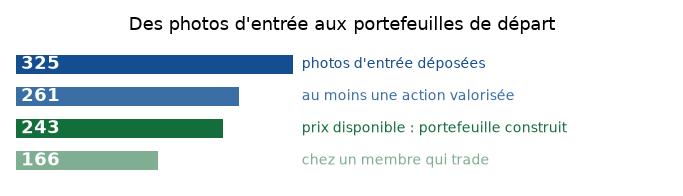

In [63]:
# Figure — ÉTAPE 8 on reconstruit : l'entonnoir des photos d'entrée (fig_10_entonnoir_h0)
_e = [(len(_ph_tous), "photos d'entrée déposées", "#144d90"),
      (len(_ph_expl), "au moins une action valorisée", "#3a6ea5"),
      (len(_ph_init), "prix disponible : portefeuille construit", "#146e3c"),
      (len(_ph_inj), "chez un membre qui trade", "#7fae92")]
fig, ax = plt.subplots(figsize=(FIGCOL, 1.25))
for _i, (_n, _lab, _c) in enumerate(_e):
    ax.barh(len(_e) - 1 - _i, _n, color=_c, height=0.6)
    ax.text(6, len(_e) - 1 - _i, f"{_n}", va="center", ha="left", color="white",
            fontsize=8, weight="bold")
    ax.text(_e[0][0] * 1.03, len(_e) - 1 - _i, _lab, va="center", fontsize=6.5, color=_c)
ax.set_xlim(0, _e[0][0] * 2.35); ax.set_ylim(-0.6, len(_e) - 0.35)
ax.set_yticks([]); ax.set_xticks([])
for _s in ("top", "right", "bottom", "left"):
    ax.spines[_s].set_visible(False)
ax.set_title("Des photos d'entrée aux portefeuilles de départ")
plt.tight_layout(); plt.show()
assert _e[0][0] == len(e15) and _e[-1][0] <= _e[0][0]

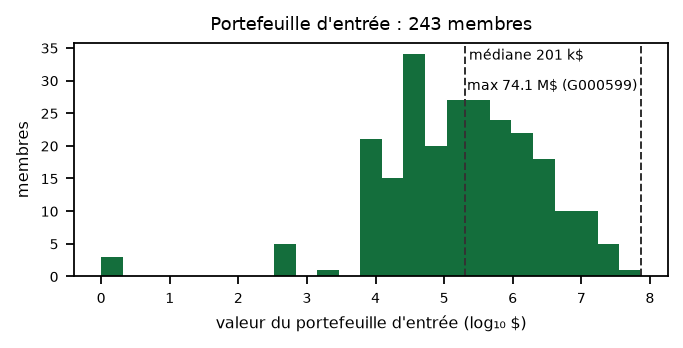

valeur h₀ : médiane 201,010 $ · max 74,104,236 $ (G000599)


In [64]:
# Figure — la valeur initialisée par membre (fig_10_h0_couverture)
_v0 = (h0_parts.assign(v=lambda d: [q * prices[t].loc[t0] for q, t, t0 in zip(d["q0"], d["ticker"], d["t0"])])
       .groupby("bioguide_id")["v"].sum())
fig, ax = plt.subplots(figsize=(FIGCOL, 2.2))
ax.hist(np.log10(_v0.clip(lower=1)), bins=25, color="#146e3c")
ax.axvline(np.log10(_v0.median()), ls="--", c="#333333", lw=0.9)
ax.text(np.log10(_v0.median()), ax.get_ylim()[1] * 0.93, f" médiane {_v0.median()/1e3:,.0f} k$", fontsize=6.5, ha="left")
ax.axvline(np.log10(_v0.max()), ls="--", c="#333333", lw=0.9)
ax.text(np.log10(_v0.max()), ax.get_ylim()[1] * 0.80, f"max {_v0.max()/1e6:,.1f} M$ ({_v0.idxmax()}) ", fontsize=6.5, ha="right")
ax.set_xlabel("valeur du portefeuille d'entrée (log₁₀ $)"); ax.set_ylabel("membres")
ax.set_title(f"Portefeuille d'entrée : {len(_v0)} membres")
plt.tight_layout(); plt.show()
print(f"valeur h₀ : médiane {_v0.median():,.0f} $ · max {_v0.max():,.0f} $ ({_v0.idxmax()})")

**Le moteur.** Rendement time-weighted sur les **parts de la veille** — un apport (photo ou achat) n'est
jamais une performance : $r_m(t) = \frac{\sum_i h_i(t-1) P_i(t)}{\sum_i h_i(t-1) P_i(t-1)} - 1$, borné ±50 %/j.

**Les 4 reconstructions** (même moteur, seules les données changent) :
| run | flux | photo |
|---|---|---|
| A (témoin) | ptr | non |
| B | ptr | oui |
| C | ptr ∪ oat | non |
| **D (adaptée)** | **ptr ∪ oat** | **oui** |

In [65]:
# Règle du portefeuille d'entrée : la photo déclare l'état COMPLET du patrimoine à sa date.
# Rejouer par-dessus les achats qu'elle contient déjà compterait ces positions DEUX FOIS.
PHOTO_FAIT_FOI = True          # False = ancien comportement (trades antérieurs rejoués en plus)
IGNORES = []                   # journal des trades écartés parce qu'antérieurs à la photo
print(f"portefeuille d'entrée : la photo fait foi à sa date (PHOTO_FAIT_FOI = {PHOTO_FAIT_FOI})")

portefeuille d'entrée : la photo fait foi à sa date (PHOTO_FAIT_FOI = True)


In [66]:
def member_shares(g, h0_rows=None):
    """trades d'un membre (+ h0 éventuel) -> (N parts par jour, masse tronquée en $)."""
    _h0 = ({r.ticker: (r.t0, r.q0) for r in h0_rows.itertuples()}
           if h0_rows is not None and len(h0_rows) else {})
    cols, tronque = {}, 0.0
    for tk in sorted(set(g["ticker"]) | set(_h0)):
        gt = g[g["ticker"] == tk]
        h, events = 0.0, {}
        rows = ([(pd.Timestamp(_h0[tk][0]), "h0", _h0[tk][1], None)] if tk in _h0 else [])
        _t0 = pd.Timestamp(_h0[tk][0]) if tk in _h0 else None
        for _, row in gt.sort_values("traded").iterrows():
            # PHOTO_FAIT_FOI : la photo déclare l'état COMPLET à sa date. Les trades antérieurs
            # sont déjà dedans — les rejouer par-dessus compterait la position deux fois.
            if PHOTO_FAIT_FOI and _t0 is not None and row["traded"] < _t0:
                IGNORES.append((row["bioguide_id"], tk, row["traded"], row["size_usd"]))
                continue
            rows.append((row["traded"], row["op"], None, row["size_usd"]))
        for d, op, q0, usd in sorted(rows, key=lambda x: (x[0], 0 if x[1] == "h0" else 1)):
            if op == "h0":
                events[d] = h = h + q0                    # d = tau(f0), prix déjà consommé en É4
                continue
            dd, p = eff_price(tk, d)
            if dd is None: continue
            qty = usd / p
            if op == "buy":
                h = h + qty
            else:
                tronque += (qty - min(qty, h)) * p
                h = h - min(qty, h)
            events[dd] = h
        if events:
            cols[tk] = pd.Series(events).sort_index().reindex(cal).ffill().fillna(0.0)
    return (pd.DataFrame(cols) if cols else None), tronque

def daily_return(N):
    P = pd.DataFrame({tk: prices[tk] for tk in N.columns})
    Nsh = N.shift(1)
    num = (Nsh * P).sum(axis=1); den = (Nsh * P.shift(1)).sum(axis=1)
    r = pd.Series(np.where(den > 0, num / den - 1.0, 0.0), index=N.index).clip(-0.5, 0.5)
    active = N.sum(axis=1) > 0
    if not active.any(): return pd.Series(dtype=float)
    return r.loc[active.idxmax(): active[::-1].idxmax()]

In [67]:
def run_moteur(flux, use_h0):
    wfr, wft, tronq = {}, {}, {}
    _bids = set(flux["bioguide_id"])
    # la photo d'un membre n'est injectée que s'il a >= 1 trade dans CE flux (sinon rien à simuler)
    _h0g = ({b: g for b, g in h0_parts.groupby("bioguide_id") if b in _bids} if use_h0 else {})
    _fg = dict(tuple(flux.groupby("bioguide_id")))
    for bid in sorted(_bids):
        g = _fg.get(bid, flux.iloc[0:0])
        N, tr = member_shares(g, _h0g.get(bid))
        if N is None: continue
        r = daily_return(N)
        if len(r) < 2 or r.std() == 0: continue
        wfr[bid], tronq[bid] = r, tr
        wft[bid] = pd.to_datetime(np.sort(g["traded"].values))
    return wfr, wft, tronq, set(_h0g)

F_ptr = df_uni[df_uni["provenance"] == "ptr"]
runA = run_moteur(F_ptr, use_h0=False)
print(f"run A (témoin, ptr, départ zéro) : {len(runA[0])} membres avec série de rendement")

run A (témoin, ptr, départ zéro) : 226 membres avec série de rendement


In [68]:
runB = run_moteur(F_ptr, use_h0=True)
print(f"run B (+photo) : {len(runB[0])} membres | photos injectées : {len(runB[3])} | "
      f"tronqué {sum(runB[2].values())/1e6:,.0f} M$")

run B (+photo) : 258 membres | photos injectées : 131 | tronqué 688 M$


In [69]:
runC = run_moteur(df_uni, use_h0=False)
print(f"run C (+oat) : {len(runC[0])} membres | tronqué {sum(runC[2].values())/1e6:,.0f} M$")

run C (+oat) : 355 membres | tronqué 1,177 M$


In [70]:
runD = run_moteur(df_uni, use_h0=True)
print(f"run D (+photo +oat) : {len(runD[0])} membres | photos injectées : {len(runD[3])} "
      f"(les {len(runD[3]) - len(runB[3])} membres oat-only à photo sont enfin servis) | "
      f"tronqué {sum(runD[2].values())/1e6:,.0f} M$")

run D (+photo +oat) : 376 membres | photos injectées : 166 (les 35 membres oat-only à photo sont enfin servis) | tronqué 907 M$


In [71]:
RUNS = {"A (témoin)": runA, "B (+photo)": runB, "C (+oat)": runC, "D (adaptée)": runD}
# chaque jeu de données est nommé par SA SOURCE, comme dans la fiche données
SRC = {"A (témoin)": "déclarations rapides seules", "B (+photo)": "+ photo d'entrée",
       "C (+oat)": "+ rapports annuels", "D (adaptée)": "dossier complet"}
recap6 = pd.DataFrame({k: dict(membres=len(r[0]), photos_injectees=len(r[3]),
                               tronque_MUSD=round(sum(r[2].values())/1e6))
                       for k, r in RUNS.items()}).T
display(recap6)

,membres,photos_injectees,tronque_MUSD
A (témoin),226,0,937
B (+photo),258,131,688
C (+oat),355,0,1177
D (adaptée),376,166,907


In [72]:
# L'effet de la règle « la photo fait foi » : ce qu'on a cessé de compter deux fois
if IGNORES:
    _ig = pd.DataFrame(IGNORES, columns=["bioguide", "ticker", "traded", "usd"])
    print(f"trades antérieurs à la photo, désormais écartés : {len(_ig):,} "
          f"({_ig['usd'].sum()/1e6:,.0f} M$) chez {_ig['bioguide'].nunique()} membres")
    print("avant cette correction, ces positions étaient comptées DEUX fois : une fois par le trade,")
    print("une fois par la photo qui les déclare déjà.")
    display(_ig.groupby("bioguide").agg(trades=("ticker", "size"),
                                        MUSD=("usd", lambda v: round(v.sum()/1e6, 1)))
            .sort_values("trades", ascending=False).head(5))
else:
    print("aucun trade antérieur à une photo (ou PHOTO_FAIT_FOI = False)")

trades antérieurs à la photo, désormais écartés : 11,277 (697 M$) chez 88 membres
avant cette correction, ces positions étaient comptées DEUX fois : une fois par le trade,
une fois par la photo qui les déclare déjà.


,trades,MUSD
bioguide,,
G000599,1843,50.7
H001086,1680,233.7
B001327,914,9.6
M001193,717,15.6
S001229,648,39.7


### P3.1 Validation — trois preuves indépendantes

In [73]:
# (i) recalcul naïf du fil rouge (le membre à la plus grosse valeur initialisée)
FIL = _v0.loc[_v0.index.isin(runB[3])].idxmax()     # le plus gros h0 parmi les injectés de B
_g = F_ptr[F_ptr["bioguide_id"] == FIL]
N_fil, _ = member_shares(_g, h0_parts[h0_parts["bioguide_id"] == FIL])
r_moteur = runB[0][FIL]
_P = {tk: prices[tk] for tk in N_fil.columns}
_r_naif = {}
for _j in range(1, len(cal)):
    t0, t1 = cal[_j - 1], cal[_j]
    # np.nansum : un ticker sans prix ce jour-là est ignoré (même convention que le .sum() du moteur)
    num = np.nansum([N_fil[tk].iloc[_j - 1] * _P[tk].loc[t1] for tk in N_fil.columns])
    den = np.nansum([N_fil[tk].iloc[_j - 1] * _P[tk].loc[t0] for tk in N_fil.columns])
    if den > 0:
        _r_naif[t1] = max(min(num / den - 1.0, 0.5), -0.5)
_r_naif = pd.Series(_r_naif).reindex(r_moteur.index).fillna(0.0)
assert np.allclose(_r_naif.values, r_moteur.values, atol=1e-9)
print(f"(i) ✅ recalcul naïf de {FIL} : {len(r_moteur)} rendements identiques au moteur (atol 1e-9)")

(i) ✅ recalcul naïf de G000599 : 869 rendements identiques au moteur (atol 1e-9)


In [74]:
# (ii) apport ≠ performance : photo seule, zéro trade — r doit être nul le jour de l'injection
_h0_syn = h0_parts[h0_parts["bioguide_id"] == FIL].head(1)
N_syn, _ = member_shares(F_ptr.iloc[0:0], _h0_syn)
r_syn = daily_return(N_syn)
_t_inj = pd.Timestamp(_h0_syn["t0"].iloc[0])
assert abs(r_syn.loc[_t_inj]) < 1e-15
print(f"(ii) ✅ le jour de l'injection ({_t_inj.date()}), r = {r_syn.loc[_t_inj]:.0e} — l'apport ne crée rien ; "
      f"dès le lendemain, la position vit : r({r_syn.index[1].date()}) = {r_syn.iloc[1]*100:+.2f} %")

(ii) ✅ le jour de l'injection (2023-08-14), r = 0e+00 — l'apport ne crée rien ; dès le lendemain, la position vit : r(2023-08-15) = -0.79 %


In [75]:
# (iii) B ≡ A pour les membres sans photo (échantillon de 50)
_sans = [b for b in runA[0] if b not in runB[3]]
for _b in _sans[:50]:
    assert runB[0][_b].equals(runA[0][_b])
print(f"(iii) ✅ B ≡ A pour les membres sans photo injectée (contrôle sur 50/{len(_sans)})")

(iii) ✅ B ≡ A pour les membres sans photo injectée (contrôle sur 50/127)


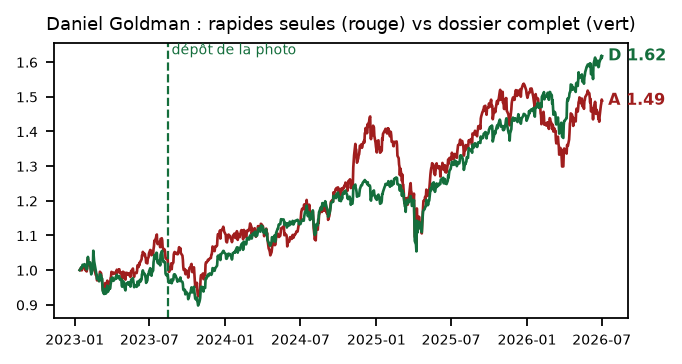

In [76]:
# Figure fil rouge — le portefeuille d'un membre : rapides seules vs dossier complet (fig_10_filrouge)
_nom_fil = df.loc[df["bioguide_id"] == FIL, "name"].iloc[0] if (df["bioguide_id"] == FIL).any() else FIL
_f0 = h0_parts.loc[h0_parts["bioguide_id"] == FIL, "t0"].min()
fig, ax = plt.subplots(figsize=(FIGCOL, 2.3))
for _lbl, _run, _c in [("A", runA, "#a01e1e"), ("D", runD, "#146e3c")]:
    if FIL in _run[0]:
        _nv = (1 + _run[0][FIL]).cumprod()
        ax.plot(_nv, color=_c, lw=1.2)
        ax.text(_nv.index[-1], _nv.iloc[-1], f" {_lbl} {_nv.iloc[-1]:.2f}", color=_c, fontsize=7, va="center", weight="bold")
ax.axvline(_f0, ls="--", c="#146e3c", lw=1.0)
ax.text(_f0, ax.get_ylim()[1], " dépôt de la photo", color="#146e3c", fontsize=6.5, va="top")
ax.set_title(f"{_nom_fil} : rapides seules (rouge) vs dossier complet (vert)")
ax.tick_params(axis="x", labelrotation=0)
plt.tight_layout(); plt.show()

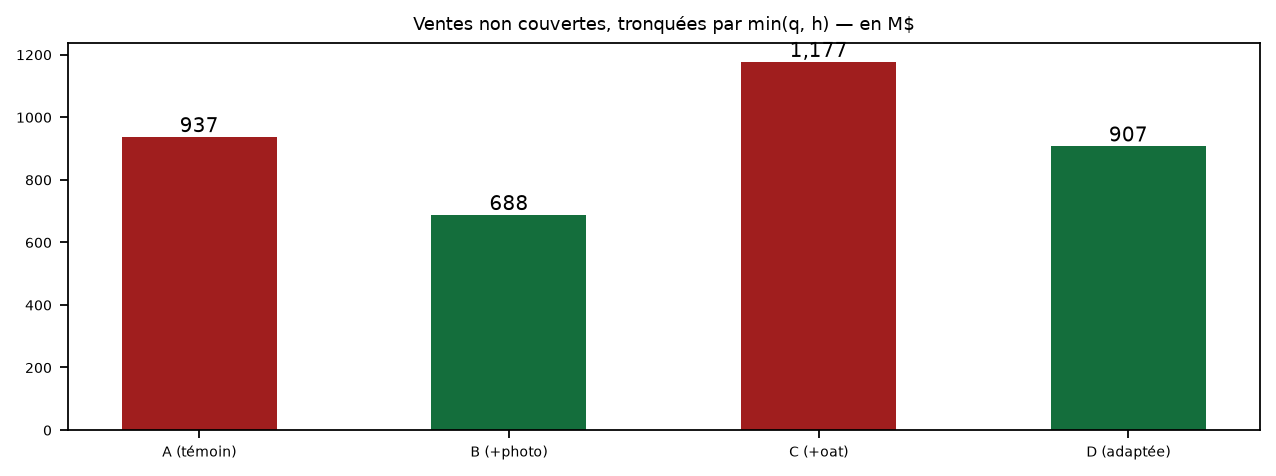

In [77]:
# Figure — la troncature des ventes fond quand la photo existe
_t_by = pd.DataFrame({k: pd.Series(r[2]) for k, r in RUNS.items()}).fillna(0.0)
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(4), _t_by.sum() / 1e6, color=["#a01e1e", "#146e3c", "#a01e1e", "#146e3c"],
       width=0.5, tick_label=list(RUNS))
for _i, _v in enumerate(_t_by.sum() / 1e6):
    ax.text(_i, _v, f"{_v:,.0f}", ha="center", va="bottom", fontsize=9)
ax.set_title("Ventes non couvertes, tronquées par min(q, h) — en M$")
plt.tight_layout(); plt.show()

## P4 — La vérification : les rapports annuels jugent la reconstruction

Chaque photo **O** déclare le patrimoine au 31/12 ; notre moteur reconstruit h(t) jour par jour.
À la date de **dépôt** de chaque O (1er jour coté ≥ f), on confronte reconstruction et déclaration :

- **(a) positions** — précision = part des positions reconstruites qui sont déclarées ; rappel = part des positions déclarées qu'on a reconstruites ;
- **(b) valeurs** — sur les positions communes, h·P tombe-t-il dans la fourchette déclarée [v̲, v̄] ?

Calculé pour **A (témoin)** et **D (adaptée)** : si D colle mieux, les corrections améliorent la
reconstruction — indépendamment de toute performance boursière. Le **T** sert de vérification finale.

In [78]:
# Les photos d'un type donné, jointes à leurs lignes tickérisées/valorisées avec prix
def photos_type(ft):
    p = (ph12[ph12["filing_type"] == ft]
         .merge(h11, on="doc_id", suffixes=("", "_h"))
         .query("ticker == ticker and ~conteneur_nu")
         .assign(classe=lambda d: [classe_ligne(t, x) for t, x in zip(d["ticker"], d["asset_description"])])
         .query("classe == 'negociable'")   # v8 : equity vs equity — la reconstruction ne tient que des actions/ETF
         .assign(mid=lambda d: (d["value_lo"] + d["value_hi"]) / 2)
         .dropna(subset=["mid"]))
    p["ticker_y"] = p["ticker"].map(to_yahoo)
    p = p[p["ticker_y"].isin(prices)]
    return (p.groupby(["bioguide", "doc_id", "filing_date", "ticker_y"], as_index=False)
             .agg(lo=("value_lo", "sum"), hi=("value_hi", "sum")))

oph = photos_type("O")
print(f"photos O exploitables : {oph['doc_id'].nunique():,} documents · {oph['bioguide'].nunique()} membres · "
      f"{len(oph):,} lignes (tickérisées, valorisées, prix disponible)")
display(oph.head(3))

photos O exploitables : 2,263 documents · 460 membres · 43,019 lignes (tickérisées, valorisées, prix disponible)


,bioguide,doc_id,filing_date,ticker_y,lo,hi
0,A000055,10006023,2015-05-14,AMX,1001.0,15000.0
1,A000055,10006023,2015-05-14,GSK,1001.0,15000.0
2,A000055,10006023,2015-05-14,OPY,1001.0,15000.0


In [79]:
# Reconstruire les positions d'un membre à des dates données, dans une configuration donnée
_h0g_all = dict(tuple(h0_parts.groupby("bioguide_id")))
def positions_aux_dates(bid, dates, flux, use_h0):
    g = flux[flux["bioguide_id"] == bid]
    N, _ = member_shares(g, _h0g_all.get(bid) if use_h0 else None)
    if N is None:
        return {}
    out = {}
    for d in dates:
        pos = cal.searchsorted(d)
        if pos >= len(cal):
            continue
        row = N.loc[cal[pos]]
        out[d] = {tk: float(row[tk]) for tk in N.columns if row[tk] > 1e-9}
    return out

In [80]:
# La confrontation, photo par photo, pour une configuration
def confronter(nom, flux, use_h0, photos):
    _g = dict(tuple(photos.groupby("bioguide")))
    _bids = sorted(set(_g) & set(flux["bioguide_id"].unique()))
    rows = []
    for _bid in _bids:
        _pm = _g[_bid]
        _dates = sorted(_pm["filing_date"].unique())
        _posm = positions_aux_dates(_bid, _dates, flux, use_h0)
        for _d in _dates:
            if _d not in _posm:
                continue
            _pd_ = _pm[_pm["filing_date"] == _d]
            _decl, _rec = set(_pd_["ticker_y"]), set(_posm[_d])
            _com = _decl & _rec
            _t = cal[cal.searchsorted(_d)]
            _nf = 0
            for _tk in _com:
                _v = _posm[_d][_tk] * prices[_tk].loc[_t]
                _b = _pd_.loc[_pd_["ticker_y"] == _tk, ["lo", "hi"]].iloc[0]
                if _b["lo"] * 0.999 <= _v <= _b["hi"] * 1.001:
                    _nf += 1
            rows.append(dict(run=nom, bioguide=_bid, annee=_d.year,
                             n_decl=len(_decl), n_rec=len(_rec), n_com=len(_com),
                             precision=len(_com) / len(_rec) if _rec else np.nan,
                             rappel=len(_com) / len(_decl) if _decl else np.nan,
                             n_fourchette=_nf))
    return pd.DataFrame(rows)

verif = pd.concat([confronter("A (témoin)", F_ptr, False, oph),
                   confronter("D (adaptée)", df_uni, True, oph)], ignore_index=True)
print(f"confrontations : {len(verif):,} (photo O × run)")
display(verif.head(4))

confrontations : 3,435 (photo O × run)


,run,bioguide,annee,n_decl,n_rec,n_com,precision,rappel,n_fourchette
0,A (témoin),A000055,2015,3,0,0,NaN,0.0,0
1,A (témoin),A000055,2016,4,0,0,NaN,0.0,0
2,A (témoin),A000055,2017,4,0,0,NaN,0.0,0
3,A (témoin),A000055,2018,4,0,0,NaN,0.0,0


In [81]:
# Agrégats et verdict : la reconstruction adaptée colle-t-elle mieux aux déclarations ?
agg4 = (verif.groupby("run")[["precision", "rappel"]].median()
        .join(verif.groupby("run").apply(lambda d: d["n_fourchette"].sum() / max(d["n_com"].sum(), 1),
                                         include_groups=False).rename("part_valeurs_en_fourchette"))
        .join(verif.groupby("run").size().rename("n_photos")))
display(agg4.round(3))
_pA, _pD = agg4.loc["A (témoin)"], agg4.loc["D (adaptée)"]
print(f"verdict reconstruction : rappel médian {_pA['rappel']:.0%} (A) → {_pD['rappel']:.0%} (D) · "
      f"précision {_pA['precision']:.0%} → {_pD['precision']:.0%} · "
      f"valeurs en fourchette {_pA['part_valeurs_en_fourchette']:.0%} → {_pD['part_valeurs_en_fourchette']:.0%}")

,precision,rappel,part_valeurs_en_fourchette,n_photos
run,,,,
A (témoin),0.553,0.091,0.437,1557
D (adaptée),0.560,0.571,0.467,1878


verdict reconstruction : rappel médian 9% (A) → 57% (D) · précision 55% → 56% · valeurs en fourchette 44% → 47%


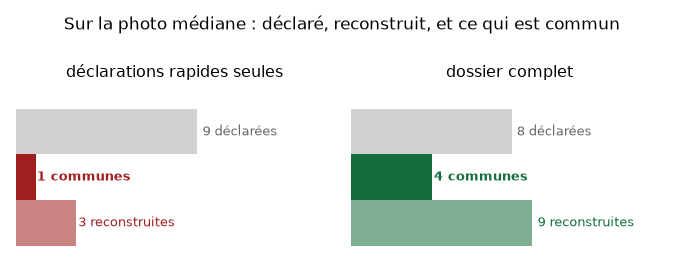

retrouvé = communes / déclarées · juste = communes / reconstruites (médianes par photo)


In [82]:
# Figure — ce que « retrouvé » et « juste » mesurent (fig_10_recouvrement)
_conf = [("déclarations rapides seules", "A (témoin)", "#a01e1e"),
         ("dossier complet", "D (adaptée)", "#146e3c")]
fig, axes = plt.subplots(1, 2, figsize=(FIGCOL, 1.7))
for _ax, (_lab, _run, _c) in zip(axes, _conf):
    _v = verif[verif["run"] == _run]
    _decl, _rec = _v["n_decl"].median(), _v["n_rec"].median()
    _com = _v["n_com"].median()
    _ax.barh([1], [_decl], color="#9a9a9a", height=0.5, alpha=0.45)
    _ax.barh([0], [_rec], color=_c, height=0.5, alpha=0.55)
    _ax.barh([0.5], [_com], color=_c, height=0.5)
    _ax.text(_decl * 1.03, 1, f"{_decl:.0f} déclarées", va="center", fontsize=5.8, color="#666666")
    _ax.text(_com * 1.03, 0.5, f"{_com:.0f} communes", va="center", fontsize=5.8, color=_c, weight="bold")
    _ax.text(_rec * 1.03, 0, f"{_rec:.0f} reconstruites", va="center", fontsize=5.8, color=_c)
    _ax.set_xlim(0, max(_decl, _rec) * 1.75); _ax.set_ylim(-0.45, 1.45)
    _ax.set_yticks([]); _ax.set_xticks([])
    _ax.set_title(_lab, fontsize=7)
    for _s in ("top", "right", "bottom", "left"):
        _ax.spines[_s].set_visible(False)
fig.suptitle("Sur la photo médiane : déclaré, reconstruit, et ce qui est commun", fontsize=7.5)
plt.tight_layout(); plt.show()
print("retrouvé = communes / déclarées · juste = communes / reconstruites (médianes par photo)")

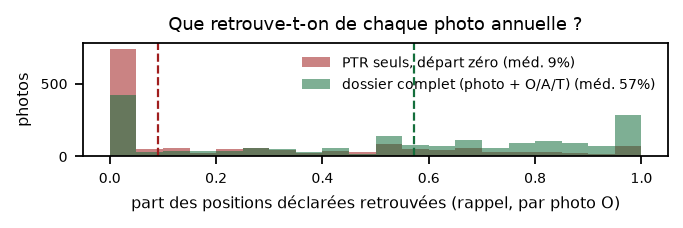

In [83]:
# Distribution du rappel, photo par photo — étiquettes par SOURCES (fig_10_verif_dist)
_lab = {"A (témoin)": "PTR seuls, départ zéro", "D (adaptée)": "dossier complet (photo + O/A/T)"}
fig, ax = plt.subplots(figsize=(FIGCOL, 1.45))
for _run, _col in [("A (témoin)", "#a01e1e"), ("D (adaptée)", "#146e3c")]:
    _r = verif.loc[verif["run"] == _run, "rappel"].fillna(0)
    ax.hist(_r, bins=np.linspace(0, 1, 21), alpha=0.55, color=_col,
            label=f"{_lab[_run]} (méd. {_r.median():.0%})")
    ax.axvline(_r.median(), color=_col, lw=1, ls="--")
ax.set_xlabel("part des positions déclarées retrouvées (rappel, par photo O)")
ax.set_ylabel("photos")
ax.set_title("Que retrouve-t-on de chaque photo annuelle ?")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

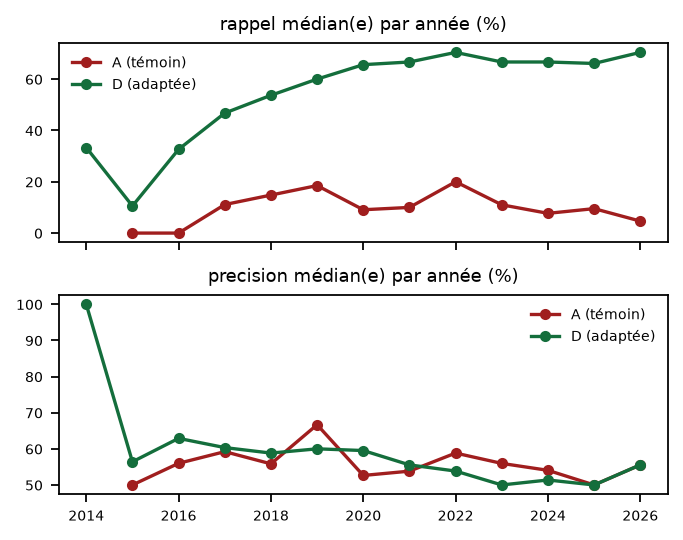

In [84]:
# Figure — la vérification année par année (fig_10_verif_O)
_ag = verif.groupby(["run", "annee"])[["precision", "rappel"]].median().reset_index()
fig, axes = plt.subplots(2, 1, figsize=(FIGCOL, 3.4), sharex=True)
for _ax, _m in zip(axes, ["rappel", "precision"]):
    for _r, _c in [("A (témoin)", "#a01e1e"), ("D (adaptée)", "#146e3c")]:
        _s = _ag[_ag["run"] == _r]
        _ax.plot(_s["annee"], _s[_m] * 100, marker="o", ms=4, color=_c, label=_r)
    _ax.set_title(f"{_m} médian(e) par année (%)"); _ax.legend(frameon=False, loc="best")
plt.tight_layout(); plt.show()

In [85]:
# Le T — la photo de sortie, en réconciliation finale (configuration D uniquement)
verif_T = confronter("D (adaptée)", df_uni, True, photos_type("T"))
print(f"photos T confrontées : {len(verif_T):,} · rappel médian {verif_T['rappel'].median():.0%} · "
      f"précision médiane {verif_T['precision'].median():.0%}")

photos T confrontées : 136 · rappel médian 60% · précision médiane 55%


### P4.1 Validation — une photo recomptée à la main

In [86]:
# Une photo O recomptée hors des fonctions : le membre à photos le plus actif du run D
_bid4 = verif.loc[verif["run"] == "D (adaptée)"].groupby("bioguide").size().idxmax()
_ph4 = oph[oph["bioguide"] == _bid4].sort_values("filing_date")
_d4 = _ph4["filing_date"].iloc[-1]
_pos4 = positions_aux_dates(_bid4, [_d4], df_uni, True)[_d4]
_decl4 = set(_ph4.loc[_ph4["filing_date"] == _d4, "ticker_y"])
_prec4 = len(_decl4 & set(_pos4)) / len(_pos4)
_rap4 = len(_decl4 & set(_pos4)) / len(_decl4)
_ligne4 = verif[(verif["run"] == "D (adaptée)") & (verif["bioguide"] == _bid4)
                & (verif["annee"] == _d4.year)].iloc[-1]
assert abs(_prec4 - _ligne4["precision"]) < 1e-12 and abs(_rap4 - _ligne4["rappel"]) < 1e-12
print(f"✅ {_bid4}, photo O déposée {_d4.date()} : {len(_decl4)} positions déclarées, {len(_pos4)} reconstruites, "
      f"{len(_decl4 & set(_pos4))} communes → précision {_prec4:.0%}, rappel {_rap4:.0%} ≡ table verif")

✅ C001066, photo O déposée 2026-05-24 : 18 positions déclarées, 35 reconstruites, 16 communes → précision 46%, rappel 89% ≡ table verif


**Limites de l'exercice, dites franchement** : clés ticker uniquement (le non-coté déclaré est hors jeu) ·
fourchettes larges (la métrique valeurs est indulgente par construction) · la photo décrit le 31/12 mais on la
confronte au jour du dépôt (l'écart de dates ajoute du bruit dans les DEUX sens, pour A comme pour D) ·
les A (amendements) ne sont pas re-fusionnés aux O ici.

## P5 — Copier les portefeuilles : la stratégie, étape par étape

On ne cherche pas à conclure : on **empile des tests**, et chacun ne change **qu'un seul réglage**.
La règle testée ici est la plus simple du projet — classement au **Sharpe**, capital réparti **à parts
égales**. Neuf étapes : ce qu'on copie (1-4), puis ce qu'on observe (5-9).

| étape | la question | ce qu'on regarde |
|---|---|---|
| 1 | qu'est-ce qu'on copie ? | le portefeuille d'un membre, vu comme un fonds |
| 2 | qui a le droit d'être copié ? | la règle d'éligibilité, et le vivier année par année |
| 3 | qui arrive en tête ? | le classement d'une coupe, en clair |
| 4 | comment le capital circule-t-il ? | compter, redéployer, tenir |
| 5 | que donne le réglage de base ? | la valeur du portefeuille face au SPY |
| 6 | quand gagne-t-on, quand perd-on ? | l'excès année par année |
| 7 | combien de membres copier ? | le balayage du nombre K |
| 8 | la source de données change-t-elle le résultat ? | les quatre jeux, même règle |
| 9 | que peut-on affirmer ? | les mesures, et la puissance du test |

### Étape 1 — Qu'est-ce qu'on copie ? Le portefeuille d'un membre, vu comme un fonds

Le portefeuille reconstruit d'un membre a une valeur qui bouge chaque jour. On l'appelle sa **valeur de
part** : elle vaut 1 au départ, puis suit les rendements du portefeuille.

$$\mathrm{NAV}_k(t) = \prod_{s \le t} \bigl(1 + r_k(s)\bigr)$$

Copier un membre, c'est acheter des parts de ce fonds. Rien d'autre : ni levier, ni vente à découvert.

In [87]:
# Étape 1 — la valeur de part : ce qu'on achèterait en copiant un membre
_wfr_dc = RUNS["D (adaptée)"][0]                     # dossier complet
NOMS_M = dict(df_uni.drop_duplicates("bioguide_id")[["bioguide_id", "name"]].values)
print(f"{len(_wfr_dc)} membres ont une valeur de part exploitable dans le dossier complet")
print("l'exemple ci-dessous sera choisi APRÈS la stratégie : le membre le plus souvent copié (étape 5)")

376 membres ont une valeur de part exploitable dans le dossier complet
l'exemple ci-dessous sera choisi APRÈS la stratégie : le membre le plus souvent copié (étape 5)


In [88]:
def classement_sharpe(Y, wfr, min_days=126, min_sharpe=0.4):
    """Éligibles (n_jours ≥ 126 ET Sharpe > 0,4 — règle du 05b Partie II), classés par Sharpe décroissant."""
    yend = pd.Timestamp(f"{Y}-12-31")
    rows = []
    for bid, r in wfr.items():
        rr = r.loc[:yend]
        if len(rr) < min_days or rr.std() == 0:
            continue
        s = rr.mean() / rr.std() * np.sqrt(252)
        if s <= min_sharpe:
            continue
        rows.append((bid, s))
    rows.sort(key=lambda x: -x[1])
    return [b for b, _ in rows]

def yearly_excess(r):
    b = r_spy.reindex(r.index).fillna(0.0)
    return pd.Series({y: (1 + r[r.index.year == y]).prod() - (1 + b[b.index.year == y]).prod()
                      for y in sorted(set(r.index.year))})

def alpha_beta(r):
    d = pd.concat([r.rename("y"), r_spy.reindex(r.index).rename("x")], axis=1).dropna()
    if len(d) < 30 or d["x"].var() == 0:
        return dict(beta=np.nan, alpha_ann=np.nan, t_appr=np.nan)
    beta, alpha = np.polyfit(d["x"].values, d["y"].values, 1)
    eps = d["y"].values - (alpha + beta * d["x"].values)
    se = eps.std(ddof=2)
    appr = alpha / se * np.sqrt(252) if se > 0 else np.nan
    return dict(beta=beta, alpha_ann=(1 + alpha) ** 252 - 1, t_appr=appr * np.sqrt(len(d) / 252))

### Étape 2 — Qui a le droit d'être copié ?

Deux conditions, vérifiées **à chaque coupe** (le 31 décembre de chaque année) et **sans jamais regarder
l'avenir** : au moins **126 jours de bourse** d'historique (six mois), et un **Sharpe supérieur à 0,4**.

$$\mathrm{Sharpe}_k = \frac{\overline{r_k}}{\sigma(r_k)}\sqrt{252}$$

Le premier filtre écarte ceux qu'on ne connaît pas assez ; le second, ceux dont le portefeuille n'a rien
montré. Aucun test statistique n'intervient ici : c'est un simple classement.

In [89]:
# Étape 2 — le vivier : combien de membres franchissent les deux conditions, à chaque coupe
_vivier = pd.DataFrame({
    src: {Y: len(classement_sharpe(Y, RUNS[k][0])) for Y in range(2015, 2026)}
    for k, src in SRC.items()})
_vivier.index.name = "coupe du 31/12"
display(_vivier)
_dc = _vivier["dossier complet"]
print(f"dossier complet : {_dc.min()} éligibles à la coupe la plus pauvre (20{_dc.idxmin()-2000}), "
      f"{_dc.max()} à la plus riche (20{_dc.idxmax()-2000}) — de quoi alimenter un classement chaque année")

,déclarations rapides seules,+ photo d'entrée,+ rapports annuels,dossier complet
coupe du 31/12,,,,
2015,42,43,63,64
2016,61,70,91,98
2017,92,108,137,151
2018,76,83,104,111
2019,123,142,179,197
2020,128,141,187,196
2021,152,164,220,229
2022,121,136,168,178
2023,152,170,224,233


dossier complet : 64 éligibles à la coupe la plus pauvre (2015), 313 à la plus riche (2025) — de quoi alimenter un classement chaque année


In [90]:
def strategie_kwf(wfr, K_GRID=range(4, 21), K_INIT=10):
    """Sharpe · K walk-forward · capital à parts égales. Rend r_strat, K*(Y), sélections, classements."""
    navk = pd.DataFrame({b: (1 + r.reindex(cal).fillna(0.0)).cumprod() for b, r in wfr.items()})
    cls = {Y: classement_sharpe(Y, wfr) for Y in range(2015, 2026)}
    def w_of(bids, Y):
        return np.ones(len(bids)) / len(bids)          # parts égales
    def bloc(Y, K):                                    # rendements du bloc tenu l'année Y+1
        bids = cls[Y][:K]
        idx = cal[cal.year == Y + 1]
        if not bids or not len(idx): return None
        w = w_of(bids, Y)
        assert abs(w.sum() - 1.0) < 1e-9               # autofinancement : les poids somment à 1
        tR = cal[cal.get_loc(idx[0]) - 1]
        nbr = pd.Series(w / navk.loc[tR, bids].values, index=bids)
        nav = navk.loc[idx, bids].mul(nbr, axis=1).sum(axis=1)
        r = nav / nav.shift(1) - 1
        r.iloc[0] = nav.iloc[0] - 1.0
        return r
    xs = {(K, Y + 1): yearly_excess(b).iloc[0]
          for K in K_GRID for Y in range(2015, 2026) if (b := bloc(Y, K)) is not None}
    rets, kpath, sels = [], {}, {}
    for Y in range(2015, 2026):
        deja = [y for y in range(2016, Y + 1)]         # années tenues, terminées à la coupe 31/12/Y
        K = K_INIT if not deja else max(K_GRID, key=lambda k: sum(xs.get((k, y), 0.0) for y in deja))
        b = bloc(Y, K)
        if b is None: continue
        kpath[Y + 1], sels[Y + 1] = K, cls[Y][:K]
        rets.append(b)
    if not rets:
        return dict(r=pd.Series(dtype=float), kpath=kpath, sels=sels, xs=xs, cls=cls)
    return dict(r=pd.concat(rets).sort_index(), kpath=kpath, sels=sels, xs=xs, cls=cls)

### Étape 3 — Qui arrive en tête ? Le classement d'une coupe, en clair

Voici ce que la règle produit concrètement à une coupe donnée : les membres les mieux classés, avec le
Sharpe qui les y place et l'historique sur lequel il est calculé.

In [91]:
# Étape 3 — le haut du classement à une coupe, avec ce qui le justifie
_Y_EX = 2021                                          # coupe du 31/12/2021, tenue en 2022
def table_classement(Y, wfr, n=10):
    _yend = pd.Timestamp(f"{Y}-12-31")
    _rows = []
    for _b in classement_sharpe(Y, wfr)[:n]:
        _r = wfr[_b].loc[:_yend]
        _rows.append(dict(membre=NOMS_M.get(_b, _b), sharpe=_r.mean() / _r.std() * np.sqrt(252),
                          jours=len(_r), depuis=_r.index[0].date()))
    return pd.DataFrame(_rows, index=range(1, len(_rows) + 1))

_top = table_classement(_Y_EX, RUNS["D (adaptée)"][0])
display(_top.round({"sharpe": 2}))
print(f"coupe du 31/12/{_Y_EX} — dossier complet : {len(classement_sharpe(_Y_EX, RUNS['D (adaptée)'][0]))} "
      f"éligibles, on garde les K premiers · historique médian du top 10 : "
      f"{_top['jours'].median():.0f} jours de bourse")

,membre,sharpe,jours,depuis
1,Doris O. Matsui,2.09,436,2020-04-13
2,Abigail Spanberger,1.93,150,2021-06-01
3,Susan W. Brooks,1.93,440,2020-04-06
4,Rick Larsen,1.93,277,2020-11-25
5,Victoria Spartz,1.83,239,2021-01-22
6,Deborah K. Ross,1.79,252,2021-01-04
7,William R. Keating,1.79,202,2021-03-17
8,Rob Woodall,1.63,609,2019-08-05
9,Michael Garcia,1.61,375,2020-07-09
10,Elaine Luria,1.49,672,2019-05-06


coupe du 31/12/2021 — dossier complet : 229 éligibles, on garde les K premiers · historique médian du top 10 : 326 jours de bourse


### Étape 4 — Comment le capital circule-t-il ? Compter, redéployer, tenir

À chaque coupe, trois gestes, toujours les mêmes :

1. **compter** — on totalise ce que valent les parts détenues : $W = \sum_k \mathrm{nbr}^k \, \mathrm{NAV}_k(t^R)$ ;
2. **redéployer** — on répartit ce capital à parts égales sur la nouvelle sélection :
   $\mathrm{nbr}^k = \dfrac{W/K}{\mathrm{NAV}_k(t^R)}$ ;
3. **tenir** — on ne touche plus à rien pendant un an ; la valeur du portefeuille suit celle des parts.

Rien n'entre, rien ne sort : le capital de départ est celui d'arrivée, augmenté ou diminué des seuls
mouvements de marché. Entre deux coupes, les poids **dérivent** — c'est un buy-and-hold assumé, pas un
rééquilibrage permanent.

### Étape 5 — Que donne le réglage de base ?

Le nombre de membres copiés, $K$, n'est pas choisi à la main : chaque année, on retient le $K$ qui aurait
le mieux fonctionné **sur le passé seulement** (grille de 4 à 20). C'est le même principe que le
classement — aucune information postérieure à la coupe n'entre dans la décision.

Les mesures affichées sont définies à l'étape 9.

In [92]:
# Étape 5 — le réglage de base : K walk-forward, parts égales, tenue 1 an
def ligne(r):
    e = yearly_excess(r); n = len(e)
    if n < 2: return dict(exces_an=np.nan, t=np.nan, gagnantes=f"-/{n}", beta=np.nan,
                          alpha_ann=np.nan, t_appr=np.nan)
    ab = alpha_beta(r)
    return dict(exces_an=e.mean(), t=e.mean() / e.std(ddof=1) * np.sqrt(n),
                gagnantes=f"{int((e > 0).sum())}/{n}", **ab)

strat = {k: strategie_kwf(r[0]) for k, r in RUNS.items()}
tab7 = pd.DataFrame({SRC[k]: ligne(s["r"]) for k, s in strat.items()}).T
_n_ans = len(yearly_excess(strat["D (adaptée)"]["r"]))
print(f"règle : Sharpe (éligible si ≥ 126 jours et Sharpe > 0,4) · K ajusté chaque année (grille 4-20) · "
      f"parts égales · tenue 1 an")
print(f"évaluation : {_n_ans} années civiles face au SPY — au-delà de |t| ≈ 1,81, un écart de cette taille "
      f"serait rare par hasard")
display(tab7.round(3))

règle : Sharpe (éligible si ≥ 126 jours et Sharpe > 0,4) · K ajusté chaque année (grille 4-20) · parts égales · tenue 1 an
évaluation : 11 années civiles face au SPY — au-delà de |t| ≈ 1,81, un écart de cette taille serait rare par hasard


,exces_an,t,gagnantes,beta,alpha_ann,t_appr
déclarations rapides seules,0.008574,0.365653,4/11,0.988663,0.006169,0.283756
+ photo d'entrée,-0.006905,-0.229164,4/11,0.98072,-0.006102,-0.242685
+ rapports annuels,0.001064,0.065172,5/11,0.917972,0.011757,0.734093
dossier complet,0.002221,0.130124,4/11,0.930168,0.01468,0.753388


### Étape 6 — Quand gagne-t-on, quand perd-on ?

Une année civile compte pour une observation. L'**excès** de l'année $Y$ est l'écart entre ce que rapporte
la stratégie et ce que rapporte le SPY sur la même année :

$$x_Y = \prod_{t \in Y}\bigl(1 + r_{\text{strat}}(t)\bigr) - \prod_{t \in Y}\bigl(1 + r_{\mathrm{SPY}}(t)\bigr)$$

Onze années, donc onze observations : c'est peu, et l'étape 9 dit ce que cela implique.

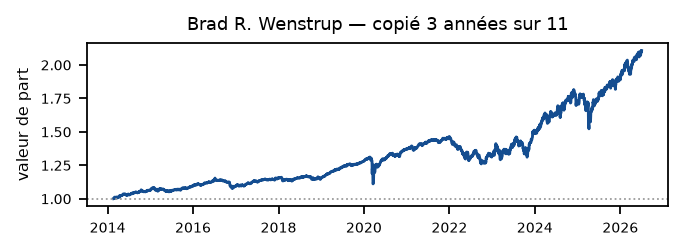

membre le plus copié : Brad R. Wenstrup — retenu 3 années sur 11
  sa valeur de part : 1,000 au départ → 2.10 après 12.4 ans (+6.2 %/an), 3,109 jours de bourse suivis
  ⚠ le portefeuille d'un membre continue d'être suivi après la fin de son mandat : on copie un portefeuille, pas un mandat


In [93]:
# Figure — ÉTAPE 1 (illustrée ici, une fois les sélections connues) : la valeur de part
# du membre le PLUS SOUVENT COPIÉ (fig_10_valeur_part)
from collections import Counter
_freq = Counter(b for _sel in strat["D (adaptée)"]["sels"].values() for b in _sel)
_bid_ex, _n_fois = _freq.most_common(1)[0]
_nav_ex = (1 + RUNS["D (adaptée)"][0][_bid_ex]).cumprod()
_ans_ex = (_nav_ex.index[-1] - _nav_ex.index[0]).days / 365.25
fig, ax = plt.subplots(figsize=(FIGCOL, 1.6))
ax.plot(_nav_ex.index, _nav_ex.values, color="#144d90", lw=1.3)
ax.axhline(1.0, color="#999999", lw=0.8, ls=":")
ax.set_ylabel("valeur de part")
ax.set_title(f"{NOMS_M.get(_bid_ex, _bid_ex)} — copié {_n_fois} années sur "
             f"{len(strat['D (adaptée)']['sels'])}")
plt.tight_layout(); plt.show()
print(f"membre le plus copié : {NOMS_M.get(_bid_ex, _bid_ex)} — retenu {_n_fois} années sur "
      f"{len(strat['D (adaptée)']['sels'])}")
print(f"  sa valeur de part : 1,000 au départ → {_nav_ex.iloc[-1]:.2f} après {_ans_ex:.1f} ans "
      f"({(_nav_ex.iloc[-1]**(1/_ans_ex) - 1)*100:+.1f} %/an), {len(_nav_ex):,} jours de bourse suivis")
print("  ⚠ le portefeuille d'un membre continue d'être suivi après la fin de son mandat : "
      "on copie un portefeuille, pas un mandat")

In [94]:
# Étape 6 — l'excès année par année, pour les quatre jeux de données
X9 = pd.DataFrame({SRC[k]: yearly_excess(s["r"]) for k, s in strat.items()})
display((100 * X9).round(1))
_dc = X9["dossier complet"]
print(f"dossier complet : {int((_dc > 0).sum())} années au-dessus du SPY sur {len(_dc)} · "
      f"meilleure {100*_dc.max():+.0f} % ({_dc.idxmax()}) · pire {100*_dc.min():+.0f} % ({_dc.idxmin()})")
print(f"l'écart entre la meilleure et la pire année ({100*(_dc.max()-_dc.min()):.0f} points) dit à lui "
      f"seul que la moyenne de {100*_dc.mean():+.1f} %/an ne se lit pas sans son incertitude")

,déclarations rapides seules,+ photo d'entrée,+ rapports annuels,dossier complet
2016,-6.3,-6.1,-3.2,-1.7
2017,12.6,-3.4,3.0,-2.8
2018,-0.7,0.9,2.7,-1.5
2019,-2.8,-3.8,5.1,-3.2
2020,3.4,26.2,-11.9,13.5
2021,-6.5,-2.6,-0.3,-3.8
2022,-6.3,-9.6,1.7,6.4
2023,3.4,-8.6,9.2,0.9
2024,17.1,-6.9,-2.9,-6.9
2025,-2.7,5.5,-0.4,-1.7


dossier complet : 4 années au-dessus du SPY sur 11 · meilleure +13 % (2020) · pire -7 % (2024)
l'écart entre la meilleure et la pire année (20 points) dit à lui seul que la moyenne de +0.2 %/an ne se lit pas sans son incertitude


In [95]:
# Étape 7 — combien de membres copier ? Le balayage de K, reconstruit depuis les blocs déjà calculés
_xs = strat["D (adaptée)"]["xs"]                       # excès de chaque couple (K, année tenue)
_KG = sorted({k for k, _ in _xs})
_ANS = sorted({y for _, y in _xs})
_bal = pd.DataFrame([{"K": K,
                      "excès moyen (%/an)": 100 * np.mean([_xs[(K, y)] for y in _ANS if (K, y) in _xs]),
                      "années gagnantes": sum(_xs.get((K, y), 0) > 0 for y in _ANS),
                      "t": (lambda v: np.mean(v) / np.std(v, ddof=1) * np.sqrt(len(v)))(
                          [_xs[(K, y)] for y in _ANS if (K, y) in _xs])}
                     for K in _KG]).set_index("K")
display(_bal.round(2))
_kbest = _bal["t"].idxmax()
print(f"K fixé de 4 à 20, dossier complet : le meilleur cas est K = {_kbest} "
      f"(t = {_bal.loc[_kbest, 't']:.2f}, excès {_bal.loc[_kbest, 'excès moyen (%/an)']:+.1f} %/an)")
print(f"le K choisi chaque année par la règle walk-forward : "
      f"{', '.join(f'{y}:{k}' for y, k in strat['D (adaptée)']['kpath'].items())}")

,excès moyen (%/an),années gagnantes,t
K,,,
4,1.15,6,0.57
5,1.29,6,0.63
6,0.28,5,0.13
7,-0.04,4,-0.02
8,0.56,6,0.28
9,0.24,5,0.14
10,-0.35,5,-0.22
11,-0.94,5,-0.60
12,-0.82,5,-0.50


K fixé de 4 à 20, dossier complet : le meilleur cas est K = 5 (t = 0.63, excès +1.3 %/an)
le K choisi chaque année par la règle walk-forward : 2016:10, 2017:19, 2018:19, 2019:19, 2020:4, 2021:4, 2022:4, 2023:4, 2024:5, 2025:5, 2026:5


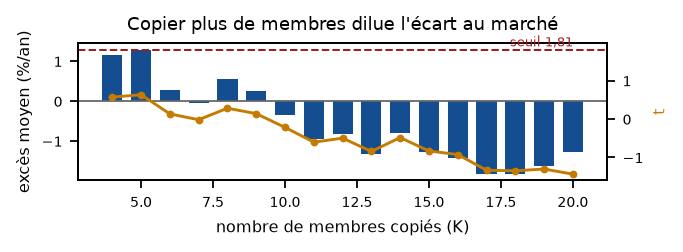

In [96]:
# Figure — ÉTAPE 7 : ce que change le nombre de membres copiés (fig_10_balayage_k)
fig, ax = plt.subplots(figsize=(FIGCOL, 1.6))
ax.bar(_bal.index, _bal["excès moyen (%/an)"], color="#144d90", width=0.7)
ax.axhline(0, color="#666666", lw=0.8)
_ax2 = ax.twinx()
_ax2.plot(_bal.index, _bal["t"], color="#c47b00", lw=1.3, marker="o", ms=2.5)
_ax2.axhline(1.81, color="#a01e1e", ls="--", lw=0.9)
_ax2.text(_bal.index[-1], 1.81, " seuil 1,81", color="#a01e1e", fontsize=6, va="bottom", ha="right")
_ax2.set_ylabel("t", color="#c47b00", fontsize=7)
ax.set_xlabel("nombre de membres copiés (K)"); ax.set_ylabel("excès moyen (%/an)", fontsize=7)
ax.set_title("Copier plus de membres dilue l'écart au marché")
plt.tight_layout(); plt.show()

### P5.1 Validation — un bloc de stratégie recalculé à la main

In [97]:
_s = strat["A (témoin)"]
_wfr = RUNS["A (témoin)"][0]
_navk = pd.DataFrame({b: (1 + r.reindex(cal).fillna(0.0)).cumprod() for b, r in _wfr.items()})
_bids = classement_sharpe(2017, _wfr)[:10]
_idx = cal[cal.year == 2018]; _tR = cal[cal.get_loc(_idx[0]) - 1]
_nbr = {b: (1.0 / len(_bids)) / _navk.loc[_tR, b] for b in _bids}
_nav_fin = sum(_nbr[b] * _navk.loc[_idx[-1], b] for b in _bids)
_spy_2018 = (1 + r_spy[r_spy.index.year == 2018].fillna(0)).prod()
_x_main = (_nav_fin - 1.0) - (_spy_2018 - 1.0)
assert abs(_x_main - _s["xs"][(10, 2018)]) < 1e-12
print(f"✅ bloc 2018, K=10 : excès recalculé à la main = {_x_main*100:+.2f} % ≡ moteur "
      f"({_s['xs'][(10, 2018)]*100:+.2f} %)")

✅ bloc 2018, K=10 : excès recalculé à la main = -3.20 % ≡ moteur (-3.20 %)


### Étape 8 — La source de données change-t-elle le résultat ?

Même règle, même moteur, quatre jeux de données : les déclarations rapides seules, puis en ajoutant la
photo d'entrée, les rapports annuels, et les deux. C'est la question de la fiche données transposée à la
stratégie — non plus « retrouve-t-on ce que l'élu déclare ? », mais « copier une reconstruction plus
complète, cela change-t-il ce qu'on obtient ? »

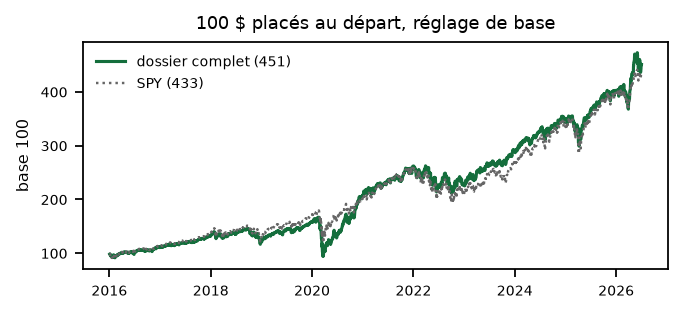

réglage de base : 451 contre 433 pour le SPY, sur 10.5 ans


In [98]:
# Figure — ÉTAPE 5 : le réglage de base, face au SPY (fig_10_nav)
_r_dc = strat["D (adaptée)"]["r"]
_i0 = _r_dc.index[0]
_nav_dc = (1 + _r_dc).cumprod() * 100
_nav_spy = (1 + r_spy[r_spy.index >= _i0].fillna(0)).cumprod() * 100
fig, ax = plt.subplots(figsize=(FIGCOL, 2.0))
ax.plot(_nav_dc, color="#146e3c", lw=1.4, label=f"dossier complet ({_nav_dc.iloc[-1]:.0f})")
ax.plot(_nav_spy, color="#666666", lw=1.1, ls=":", label=f"SPY ({_nav_spy.iloc[-1]:.0f})")
ax.legend(frameon=False, fontsize=6.5, loc="upper left")
ax.set_ylabel("base 100")
ax.set_title("100 $ placés au départ, réglage de base")
plt.tight_layout(); plt.show()
print(f"réglage de base : {_nav_dc.iloc[-1]:.0f} contre {_nav_spy.iloc[-1]:.0f} pour le SPY, "
      f"sur {(_nav_dc.index[-1] - _i0).days / 365.25:.1f} ans")

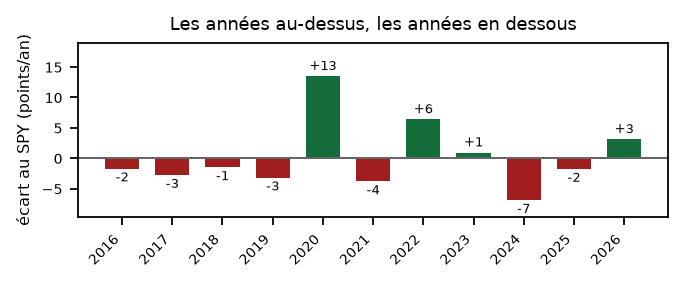

In [99]:
# Figure — ÉTAPE 6 : l'écart au SPY année par année, réglage de base (fig_10_exces_annuel)
_x_dc = X9["dossier complet"] * 100
fig, ax = plt.subplots(figsize=(FIGCOL, 1.8))
ax.bar(range(len(_x_dc)), _x_dc.values, color=np.where(_x_dc.values > 0, "#146e3c", "#a01e1e"), width=0.68)
ax.axhline(0, color="#666666", lw=0.9)
for _i, _v in enumerate(_x_dc.values):
    ax.text(_i, _v + (0.5 if _v > 0 else -0.5), f"{_v:+.0f}", ha="center",
            va="bottom" if _v > 0 else "top", fontsize=5.8)
ax.set_xticks(range(len(_x_dc))); ax.set_xticklabels(_x_dc.index, rotation=45, ha="right")
ax.set_ylabel("écart au SPY (points/an)")
ax.set_ylim(_x_dc.min() * 1.4, _x_dc.max() * 1.4)
ax.set_title("Les années au-dessus, les années en dessous")
plt.tight_layout(); plt.show()

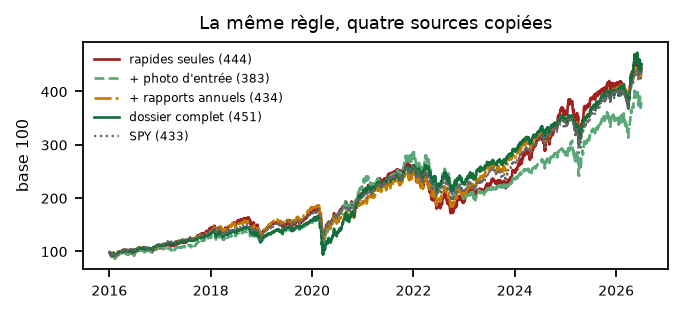

l'écart entre les courbes vient d'une seule année pour « + photo d'entrée » : 2020 y vaut +26 points, les dix autres années restent entre -10 et +5


In [100]:
# Figure — ÉTAPE 8 : les quatre sources copiées, face au SPY (fig_10_sources)
_courbes = [("A (témoin)", "rapides seules", "#a01e1e", "-"),
            ("B (+photo)", "+ photo d'entrée", "#5aa878", "--"),
            ("C (+oat)", "+ rapports annuels", "#c47b00", "-."),
            ("D (adaptée)", "dossier complet", "#146e3c", "-")]
_i0s = max(strat[k]["r"].index[0] for k, _, _, _ in _courbes)
fig, ax = plt.subplots(figsize=(FIGCOL, 2.0))
for _k, _lab, _c, _ls in _courbes:
    _r = strat[_k]["r"]
    _n = (1 + _r[_r.index >= _i0s]).cumprod() * 100
    ax.plot(_n, color=_c, lw=1.2, ls=_ls, label=f"{_lab} ({_n.iloc[-1]:.0f})")
_ns = (1 + r_spy[r_spy.index >= _i0s].fillna(0)).cumprod() * 100
ax.plot(_ns, color="#666666", lw=1.0, ls=":", label=f"SPY ({_ns.iloc[-1]:.0f})")
ax.legend(frameon=False, fontsize=5.6, loc="upper left")
ax.set_ylabel("base 100")
ax.set_title("La même règle, quatre sources copiées")
plt.tight_layout(); plt.show()
print("l'écart entre les courbes vient d'une seule année pour « + photo d'entrée » : "
      f"2020 y vaut {100*X9.loc[2020, '+ photo d\'entrée']:+.0f} points, les dix autres années "
      f"restent entre {100*X9['+ photo d\'entrée'].drop(2020).min():+.0f} et "
      f"{100*X9['+ photo d\'entrée'].drop(2020).max():+.0f}")

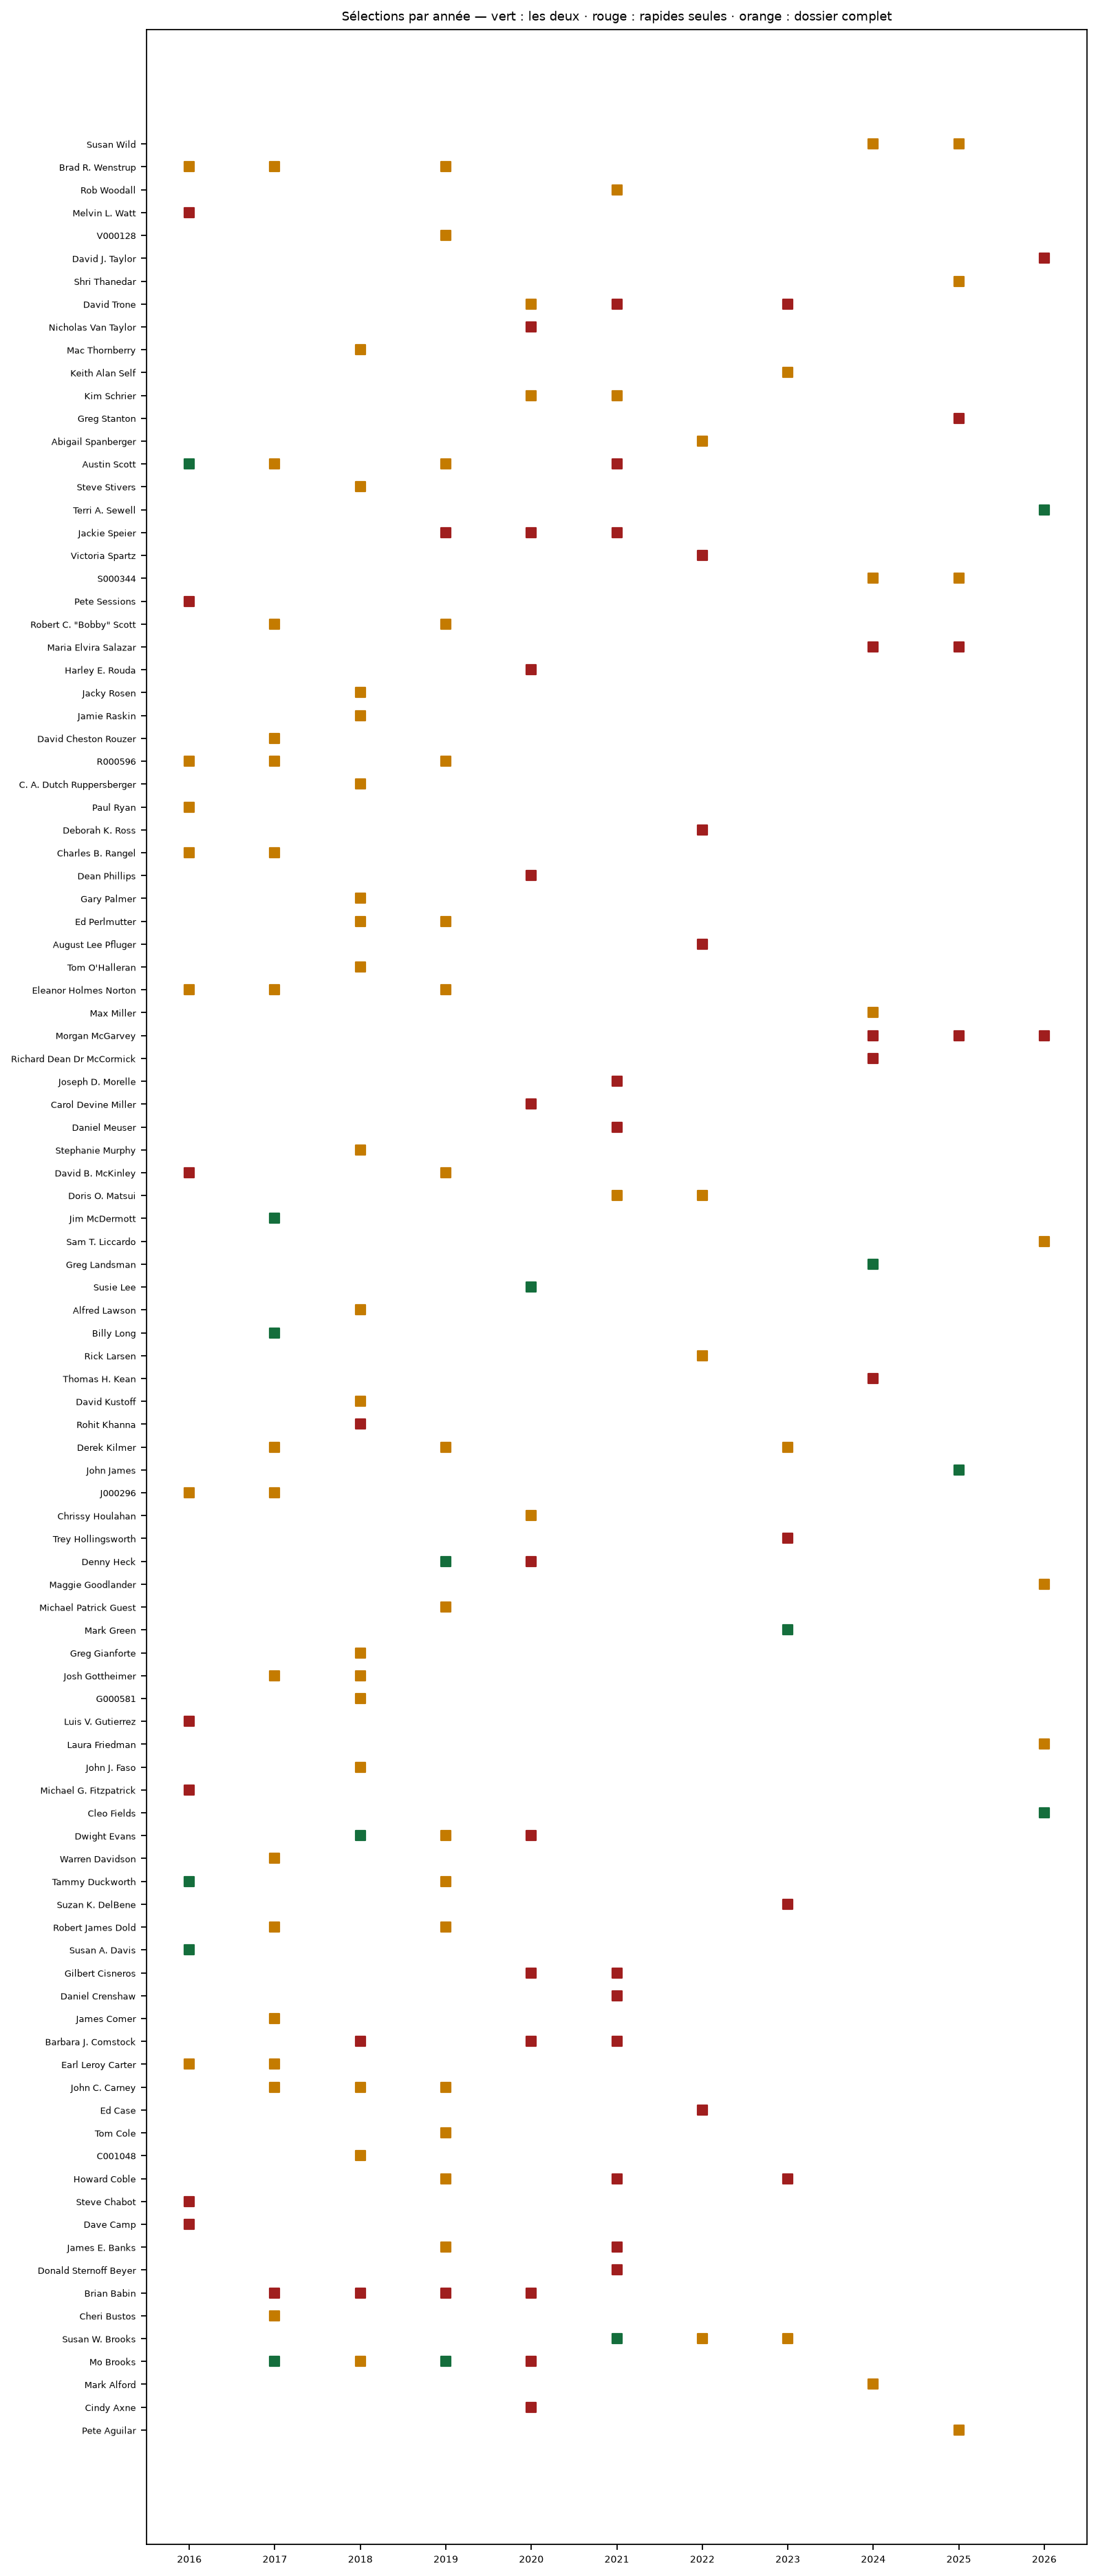

années où la sélection change selon la source : 11/11


In [101]:
# Qui est copié, année par année : rapides seules vs dossier complet
_selA, _selD = strat["A (témoin)"]["sels"], strat["D (adaptée)"]["sels"]
_ans = sorted(set(_selA) | set(_selD))
_tous = sorted({b for a in _ans for b in _selA.get(a, []) + _selD.get(a, [])})
fig, ax = plt.subplots(figsize=(10, 0.22 * len(_tous) + 1.2))
for yi, b in enumerate(_tous):
    for xi, an in enumerate(_ans):
        inA, inD = b in _selA.get(an, []), b in _selD.get(an, [])
        c = "#146e3c" if (inA and inD) else ("#a01e1e" if inA else ("#c47b00" if inD else None))
        if c:
            ax.scatter(xi, yi, s=40, marker="s", color=c)
ax.set_xticks(range(len(_ans))); ax.set_xticklabels(_ans)
ax.set_yticks(range(len(_tous)))
ax.set_yticklabels([NOMS_M.get(b, b) for b in _tous], fontsize=6)
ax.set_title("Sélections par année — vert : les deux · rouge : rapides seules · orange : dossier complet")
plt.tight_layout(); plt.show()
print(f"années où la sélection change selon la source : "
      f"{sum(set(_selA.get(a, [])) != set(_selD.get(a, [])) for a in _ans)}/{len(_ans)}")

**Le mélange G_photo / G_zéro : surveillé (S1), contrôlé (S2), et le déplacement des Sharpe.**

In [102]:
# Contrôle S1 — les membres à photo d'entrée sont-ils sur-représentés dans la sélection ?
_SET_PHOTO = runD[3]                       # les photos réellement injectées dans le dossier complet
_sD = strat["D (adaptée)"]
_s1 = pd.DataFrame([dict(annee=Y + 1,
                         part_eligibles=np.mean([b in _SET_PHOTO for b in _sD["cls"][Y]]),
                         part_topK=np.mean([b in _SET_PHOTO for b in _sD["sels"].get(Y + 1, [np.nan])]))
                    for Y in range(2015, 2026) if _sD["cls"][Y] and (Y + 1) in _sD["sels"]]
                   ).set_index("annee")
display(_s1.style.format("{:.0%}"))
print("si les deux colonnes se suivent, la sélection ne privilégie pas les membres à photo d'entrée")

,part_eligibles,part_topK
annee,,
2016,9%,10%
2017,17%,32%
2018,26%,53%
2019,23%,16%
2020,34%,100%
2021,34%,25%
2022,37%,0%
2023,36%,25%
2024,39%,60%


si les deux colonnes se suivent, la sélection ne privilégie pas les membres à photo d'entrée


In [103]:
# Contrôle S2 — la même règle, appliquée séparément dans chaque groupe
_s2 = {}
for _k in ["A (témoin)", "D (adaptée)"]:
    for _grp, _dans in [("avec photo d'entrée", True), ("sans photo d'entrée", False)]:
        _wfr_g = {b: r for b, r in RUNS[_k][0].items() if (b in _SET_PHOTO) == _dans}
        _s2[f"{SRC[_k]} · {_grp}"] = ligne(strategie_kwf(_wfr_g)["r"])
tab_s2 = pd.DataFrame(_s2).T
display(tab_s2.round(3))
print("chaque strate est jouée seule : si l'écart au SPY tenait à un groupe, il apparaîtrait ici")

,exces_an,t,gagnantes,beta,alpha_ann,t_appr
déclarations rapides seules · avec photo d'entrée,-0.009453,-0.312996,5/11,1.110213,-0.025329,-0.934877
déclarations rapides seules · sans photo d'entrée,-0.028047,-1.997437,4/11,0.952511,-0.020597,-1.047662
dossier complet · avec photo d'entrée,-0.00391,-0.206542,5/11,1.03919,-0.012928,-0.845472
dossier complet · sans photo d'entrée,0.006697,0.367724,6/11,0.917711,0.015638,0.975724


chaque strate est jouée seule : si l'écart au SPY tenait à un groupe, il apparaîtrait ici


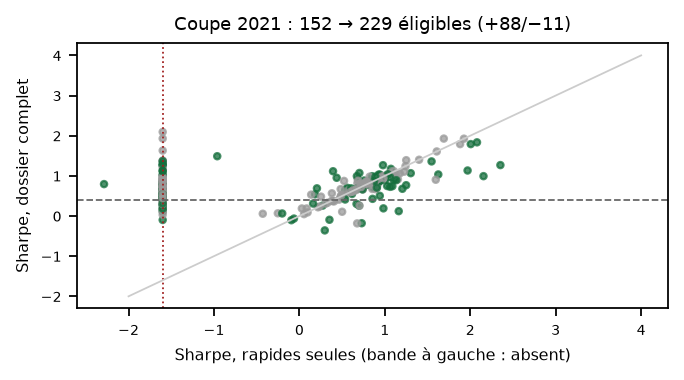

éligibles à la coupe 2021 : 152 avec les déclarations rapides seules, 229 avec le dossier complet · 88 entrants, 11 sortants


In [104]:
# Ce que la source change au classement : les Sharpe à une coupe (fig_10_sharpe_shift)
_YC = 2021
_wA, _wD = RUNS["A (témoin)"][0], RUNS["D (adaptée)"][0]
_yend = pd.Timestamp(f"{_YC}-12-31")
def _sh(wfr, b):
    if b not in wfr: return np.nan
    r = wfr[b].loc[:_yend]
    return r.mean() / r.std() * np.sqrt(252) if len(r) >= 126 and r.std() > 0 else np.nan
_bids = sorted(set(_wA) | set(_wD))
_cmp = pd.DataFrame({"rapides seules": [_sh(_wA, b) for b in _bids],
                     "dossier complet": [_sh(_wD, b) for b in _bids],
                     "photo": [b in _SET_PHOTO for b in _bids]}, index=_bids)
_el_A = len(classement_sharpe(_YC, _wA)); _el_D = len(classement_sharpe(_YC, _wD))
_nouv = len(set(classement_sharpe(_YC, _wD)) - set(classement_sharpe(_YC, _wA)))
_sort = len(set(classement_sharpe(_YC, _wA)) - set(classement_sharpe(_YC, _wD)))
fig, ax = plt.subplots(figsize=(FIGCOL, 2.4))
_m = _cmp.dropna(subset=["dossier complet"])
ax.scatter(_m["rapides seules"].fillna(-1.6), _m["dossier complet"], s=8,
           c=np.where(_m["photo"], "#146e3c", "#9a9a9a"), alpha=0.75)
ax.axvline(-1.6, color="#a01e1e", ls=":", lw=0.8)
ax.plot([-2, 4], [-2, 4], color="#cccccc", lw=0.8)
ax.axhline(0.4, color="#666666", ls="--", lw=0.8)
ax.set_xlabel(f"Sharpe, rapides seules (bande à gauche : absent)"); ax.set_ylabel("Sharpe, dossier complet")
ax.set_title(f"Coupe {_YC} : {_el_A} → {_el_D} éligibles (+{_nouv}/−{_sort})")
plt.tight_layout(); plt.show()
print(f"éligibles à la coupe {_YC} : {_el_A} avec les déclarations rapides seules, {_el_D} avec le "
      f"dossier complet · {_nouv} entrants, {_sort} sortants")

### Étape 9 — Que peut-on affirmer ?

Quatre mesures, et ce que chacune dit exactement :

- **excès annuel moyen** — de combien on bat le SPY, en moyenne, sur les onze années ;
- **t** — cet écart moyen rapporté à sa propre instabilité. Au-delà de $|t| \approx 1{,}81$, un écart de
  cette taille serait rare si la stratégie ne valait pas mieux que le marché ;
- **β** — la part du mouvement qui suit simplement le marché. Un β proche de 1,2 signifie qu'on prend
  20 % de risque de marché en plus : le gain vient alors du risque, pas de la sélection ;
- **α et son t** — ce qui reste une fois le marché retiré. C'est la seule mesure qui isole l'apport propre
  du choix des membres.

Reste une question qu'aucune de ces mesures ne règle : **avec onze observations, qu'aurait-on été capable
de détecter ?**

In [105]:
# Étape 9 — la portée du test : quel écart annuel aurait-on pu détecter ?
import scipy.stats as _st
_sig = X9["dossier complet"].std(ddof=1)
_t_crit, _t_pow = _st.t.ppf(0.95, df=len(X9) - 1), _st.t.ppf(0.80, df=len(X9) - 1)
MDE80 = (_t_crit + _t_pow) * _sig / np.sqrt(len(X9))
print(f"instabilité des écarts annuels (dossier complet) = {_sig*100:.1f} %/an")
print(f"MDE (α = 5 % unilatéral, puissance 80 %) = ({_t_crit:.2f} + {_t_pow:.2f}) × σ̂/√{len(X9)} = {MDE80*100:.1f} %/an")
print("→ sous ce niveau, un vrai excès resterait probablement indétecté : le t faible borne ce qu'on peut voir, il ne prouve pas l'absence d'effet")

instabilité des écarts annuels (dossier complet) = 5.7 %/an
MDE (α = 5 % unilatéral, puissance 80 %) = (1.81 + 0.88) × σ̂/√11 = 4.6 %/an
→ sous ce niveau, un vrai excès resterait probablement indétecté : le t faible borne ce qu'on peut voir, il ne prouve pas l'absence d'effet


## P6 — Lecture

In [106]:
# La trace des neuf étapes, sans conclusion : ce qu'on a changé, ce qu'on a observé
_trace = pd.DataFrame([
    ("1-4  la règle", "Sharpe, K walk-forward, parts égales, tenue 1 an",
     f"{len(RUNS['D (adaptée)'][0])} membres copiables"),
    ("5    réglage de base", "rien (la référence)",
     f"{tab7.loc['dossier complet', 'exces_an']*100:+.1f} %/an, t {tab7.loc['dossier complet', 't']:.2f}"),
    ("6    année par année", "rien",
     f"{tab7.loc['dossier complet', 'gagnantes']} années au-dessus du SPY"),
    ("7    combien copier", "K fixé de 4 à 20",
     f"meilleur cas K = {_kbest}, t = {_bal.loc[_kbest, 't']:.2f}"),
    ("8    la source", "les 4 jeux de données",
     f"t de {tab7['t'].min():.2f} à {tab7['t'].max():.2f}"),
    ("9    la puissance", "rien", f"MDE {MDE80*100:.1f} %/an à 80 % de puissance"),
], columns=["étape", "ce qu'on change", "ce qu'on observe"]).set_index("étape")
display(_trace)
print(f"aucune configuration testée n'atteint le seuil de 1,81 ; la plus haute est "
      f"{tab7['t'].astype(float).max():.2f} ({tab7['t'].astype(float).idxmax()})")
print(f"et l'étape 9 borne la lecture : sous {MDE80*100:.1f} %/an, un écart réel serait probablement "
      f"resté invisible avec {len(X9)} années")

,ce qu'on change,ce qu'on observe
étape,,
1-4 la règle,"Sharpe, K walk-forward, parts égales, tenue 1 an",376 membres copiables
5 réglage de base,rien (la référence),"+0.2 %/an, t 0.13"
6 année par année,rien,4/11 années au-dessus du SPY
7 combien copier,K fixé de 4 à 20,"meilleur cas K = 5, t = 0.63"
8 la source,les 4 jeux de données,t de -0.23 à 0.37
9 la puissance,rien,MDE 4.6 %/an à 80 % de puissance


aucune configuration testée n'atteint le seuil de 1,81 ; la plus haute est 0.37 (déclarations rapides seules)
et l'étape 9 borne la lecture : sous 4.6 %/an, un écart réel serait probablement resté invisible avec 11 années


**Ce que cette suite de tests établit, et ce qu'elle n'établit pas.**

- Elle établit une **trace** : à chaque réglage changé, une mesure, toujours face au même repère.
- Elle n'établit **pas** qu'il n'y a rien à trouver : l'étape 9 chiffre ce qu'on aurait pu voir.
- Les transactions entrent à leur **date d'opération**, pas à leur date de publication. Les résultats sont
  donc une **borne haute** : un suiveur réel agirait 27 jours plus tard sur les déclarations rapides, et
  plus d'un an plus tard sur les rapports annuels.
- Aucun coût de transaction n'est appliqué, aucun placebo n'est joué, une seule pondération est testée.
- Le juge indépendant de tout ceci reste la vérification de P4 : elle dit si la reconstruction colle aux
  déclarations, indépendamment de toute performance.

In [107]:
# Garde-fou final : prices_v2 n'a pas bougé
assert sorted(os.listdir(PRICES_V2)) == _SNAP_PV2, "prices_v2 modifié — INTERDIT"
print(f"✅ prices_v2 intact ({len(_SNAP_PV2)} fichiers)")

✅ prices_v2 intact (3351 fichiers)


---
# P7 — D'où viennent les trous ?

Chaque manque annoncé dans la fiche peut avoir **trois causes**, et elles n'ont pas du tout les mêmes
conséquences :

| cause | ce que ça veut dire | est-ce réparable ? |
|---|---|---|
| **RÉALITÉ** | l'élu n'a rien déposé | non — c'est un fait |
| **SOURCE** | le document existe mais est inexploitable (papier scanné, patrimoine sans ticker) | parfois, au prix d'un OCR ou d'un travail de reconnaissance |
| **NOUS** | le document est là, exploitable, et notre traitement le laisse tomber | oui — c'est un défaut à corriger |

Cette section mesure la part de chacune. Elle ne modifie rien : elle relit le journal de traitement des
documents (`02_ledger_docs`), le recensement des dépôts (`01_recensement_depots`) et les caches de prix.

In [108]:
# Le journal de traitement : ce que chaque document déposé est devenu
led = pd.read_csv(os.path.join(V1T, "02_ledger_docs.csv"), low_memory=False)
_sort = {"parse_ok": "exploité", "ocr_herite_parse": "exploité",
         "parse_ok_vide": "lu, mais aucune ligne trouvée", "scanne_hors_V1": "papier jamais océrisé",
         "absent_404": "introuvable au téléchargement",
         "hors_perimetre_admin": "hors périmètre (administratif)",
         "hors_perimetre_blind_trust": "hors périmètre (blind trust)"}
led["sort"] = led["statut"].map(_sort)
_t = (led[led["filing_type"].isin(["P", "H", "C", "O", "T", "A"])]
      .pivot_table(index="filing_type", columns="sort", values="doc_id", aggfunc="count", fill_value=0)
      .reindex(["P", "H", "O", "T", "C", "A"]))
_t["total"] = _t.sum(axis=1)
_t["% exploité"] = (_t["exploité"] / _t["total"] * 100).round(1)
display(_t)
print("Les déclarations de transactions (P) sont exploitées à 100 %. Les photos du patrimoine perdent")
print("entre 15 % et 35 % de leurs documents, et c'est la première source des trous qui suivent.")

sort,exploité,introuvable au téléchargement,"lu, mais aucune ligne trouvée",papier jamais océrisé,total,% exploité
filing_type,,,,,,
P,8267,0,0,0,8267,100.0
H,258,0,125,12,395,65.3
O,3453,0,450,721,4624,74.7
T,257,0,34,102,393,65.4
C,4017,1,4515,1583,10116,39.7
A,1363,0,507,433,2303,59.2


Les déclarations de transactions (P) sont exploitées à 100 %. Les photos du patrimoine perdent
entre 15 % et 35 % de leurs documents, et c'est la première source des trous qui suivent.


In [109]:
# Outil commun : rattacher un document du journal à un membre (via la table des identités)
ident = pd.read_csv(os.path.join(V1T, "06_identites_v1.csv"), low_memory=False)
_cle = ["last", "first", "suffix", "state_district"]
led_b = led.merge(ident[_cle + ["bioguide"]].dropna(subset=["bioguide"]), on=_cle, how="left")
print(f"journal : {len(led_b):,} documents · {led_b['bioguide'].notna().mean():.1%} rattachés à un membre "
      f"du référentiel (le reste = candidats jamais élus, hors registre)")

def decompose(bios_manquants, types, libelle):
    """Pour un ensemble de membres sans document exploité d'un type donné, répartir en 3 causes."""
    _g = led_b[led_b["filing_type"].isin(types) & led_b["bioguide"].isin(bios_manquants)]
    _expl = set(_g.loc[_g["sort"] == "exploité", "bioguide"])
    _src = set(_g.loc[_g["sort"].isin(["papier jamais océrisé", "lu, mais aucune ligne trouvée",
                                       "introuvable au téléchargement"]), "bioguide"]) - _expl
    _nous = _expl                       # document exploité, et pourtant le membre n'a rien : c'est nous
    _rien = set(bios_manquants) - _expl - _src
    out = pd.Series({"RÉALITÉ — aucun document déposé": len(_rien),
                     "SOURCE — déposé mais inexploitable": len(_src),
                     "NOUS — document exploité, perdu ensuite": len(_nous)}, name=libelle)
    assert out.sum() == len(bios_manquants), (out.sum(), len(bios_manquants))
    return out

journal : 35,359 documents · 56.4% rattachés à un membre du référentiel (le reste = candidats jamais élus, hors registre)


In [110]:
# TROU 1 — les photos d'entrée manquantes (étape 1 de la fiche)
_att_ph = set(regm.loc[regm["quadrant"].isin(["arrivés restés", "cycle complet"]), "bioguide"])
_manq_ph = _att_ph - set(e15["bioguide"])
trou_photo = decompose(_manq_ph, ["H", "C"], f"photo d'entrée ({len(_manq_ph)} membres)")
display(trou_photo.to_frame())
_d = led_b[led_b["filing_type"].isin(["H", "C"]) & led_b["bioguide"].isin(_manq_ph)]
print(f"ces {len(_manq_ph)} membres ont déposé {len(_d)} documents d'entrée ou de candidature au total :")
display(_d["sort"].value_counts().to_frame("documents"))
print("→ dire que leur point de départ « nous échappe » est faux pour la plupart : le document existe.")

,photo d'entrée (142 membres)
RÉALITÉ — aucun document déposé,9
SOURCE — déposé mais inexploitable,102
"NOUS — document exploité, perdu ensuite",31


ces 142 membres ont déposé 391 documents d'entrée ou de candidature au total :


,documents
sort,
"lu, mais aucune ligne trouvée",291
papier jamais océrisé,52
exploité,48


→ dire que leur point de départ « nous échappe » est faux pour la plupart : le document existe.


In [111]:
# TROU 2 — les photos de sortie manquantes (étape 4 de la fiche)
_att_T = set(regm.loc[regm["quadrant"].isin(["déjà-là partis", "cycle complet"]), "bioguide"])
_manq_T = _att_T - set(ph12.loc[ph12["filing_type"] == "T", "bioguide"])
trou_sortie = decompose(_manq_T, ["T"], f"photo de sortie ({len(_manq_T)} membres)")
display(trou_sortie.to_frame())

,photo de sortie (96 membres)
RÉALITÉ — aucun document déposé,86
SOURCE — déposé mais inexploitable,9
"NOUS — document exploité, perdu ensuite",1


In [112]:
# TROU 3 — les membres sans aucun rapport annuel (étape 3 de la fiche)
_manq_O = set(regm.loc[(regm["n_O_attendus"] > 0) & (regm["n_O_couverts"] == 0), "bioguide"])
trou_annuel = decompose(_manq_O, ["O"], f"rapport annuel ({len(_manq_O)} membres)")
display(trou_annuel.to_frame())

,rapport annuel (79 membres)
RÉALITÉ — aucun document déposé,66
SOURCE — déposé mais inexploitable,13
"NOUS — document exploité, perdu ensuite",0


In [113]:
# TROU 4 — les membres vus SEULEMENT par leurs rapports annuels : ont-ils déposé des PTR ?
_oat_only = set(df_oat["bioguide_id"]) - set(df["bioguide_id"])
_p = led_b[(led_b["filing_type"] == "P") & led_b["bioguide"].isin(_oat_only)]
_avec_p = set(_p["bioguide"])
trou_ptr = pd.Series({
    "RÉALITÉ — n'ont jamais déposé de déclaration": len(_oat_only - _avec_p),
    "SOURCE / NOUS — ont déposé, rien n'en ressort": len(_avec_p),
}, name=f"vus seulement par l'annuel ({len(_oat_only)} membres)")
display(trou_ptr.to_frame())
if len(_avec_p):
    display(_p["sort"].value_counts().to_frame("documents P déposés par ces membres"))
print("Une déclaration exploitée peut ne donner aucune ligne retenue : ligne hors fenêtre, actif non coté,")
print("ou prix introuvable — les trous 5 et 6 mesurent ces deux dernières causes.")

,vus seulement par l'annuel (86 membres)
RÉALITÉ — n'ont jamais déposé de déclaration,65
"SOURCE / NOUS — ont déposé, rien n'en ressort",21


,documents P déposés par ces membres
sort,
exploité,131


Une déclaration exploitée peut ne donner aucune ligne retenue : ligne hors fenêtre, actif non coté,
ou prix introuvable — les trous 5 et 6 mesurent ces deux dernières causes.


In [114]:
# TROU 5 — les prix introuvables : que sont devenus les tickers écartés ?
_fail_f = os.path.join(PRICES_HOLD, "failed_holdings_v1.csv")
_fail = pd.read_csv(_fail_f) if os.path.exists(_fail_f) else pd.DataFrame(columns=["ticker"])
_tk_perdus = sorted(set(cl.loc[cl["chamber"] == "house", "ticker_yahoo"].dropna()) - set(prices))
_perdu_lignes = cl[(cl["chamber"] == "house") & ~cl["ticker_yahoo"].isin(prices)]
_en_echec = set(_fail["ticker"]) & set(_tk_perdus)
_corr = set(_corrompus) & set(_tk_perdus)
trou_prix = pd.Series({
    "NOUS — échec de téléchargement enregistré, jamais rejoué": len(_en_echec),
    "NOUS — écarté par le garde-fou de qualité de la série": len(_corr),
    "à qualifier — jamais tenté": len(set(_tk_perdus) - _en_echec - _corr),
}, name=f"prix introuvable ({len(_tk_perdus)} tickers, {len(_perdu_lignes):,} lignes)")
display(trou_prix.to_frame())
print(f"{len(_perdu_lignes):,} lignes de déclarations écartées, soit {len(_perdu_lignes)/int((cl['chamber']=='house').sum()):.1%} du total House")
if "date_echec" in _fail.columns:
    print("dates des échecs :", _fail["date_echec"].value_counts().to_dict())
display(_perdu_lignes["ticker_yahoo"].value_counts().head(10).to_frame("lignes perdues"))

,"prix introuvable (1234 tickers, 14,834 lignes)"
"NOUS — échec de téléchargement enregistré, jamais rejoué",1177
NOUS — écarté par le garde-fou de qualité de la série,57
à qualifier — jamais tenté,0


14,834 lignes de déclarations écartées, soit 12.1% du total House
dates des échecs : {'avant-2026-07-21': 2133, '2026-07-21': 19}


,lignes perdues
ticker_yahoo,
MMC,208
FI,200
WBA,190
LORL,188
CELG,181
ALXN,160
AGN,160
ATVI,155
DENN,146


In [115]:
# TROU 5 (suite) — ces échecs sont-ils réels ? On teste AVEC UN TÉMOIN, et sans rien écrire.
# Principe : si des tickers dont on sait qu'ils sont vivants échouent aussi, le test ne mesure pas
# la disponibilité des titres mais une panne de téléchargement — et il doit se déclarer invalide.
import yfinance as _yf, logging as _lg
_lg.getLogger("yfinance").setLevel(_lg.CRITICAL)
TEMOINS = ["AAPL", "MSFT", "SPY"]                 # vivants, déjà en cache : doivent toujours répondre

def _telecharge(lot):
    try:
        # group_by="ticker" est INDISPENSABLE : sans lui yfinance renvoie des colonnes
        # (Price, Ticker) et _d[_t] lève KeyError — la sonde se déclarait alors « invalide »
        # alors que le réseau répondait. Bug trouvé le 2026-07-22 en comparant les deux appels.
        _d = _yf.download(lot, start="2012-01-01", end="2026-07-03", auto_adjust=True,
                          progress=False, threads=False, group_by="ticker")
    except Exception:
        return set()
    _ok = set()
    for _t in lot:
        try:
            _s = _d[_t]["Close"] if isinstance(_d.columns, pd.MultiIndex) else _d["Close"]
            if len(_s.dropna()) >= 2:
                _ok.add(_t)
        except Exception:
            pass
    return _ok

_ok_temoin = _telecharge(TEMOINS)
if len(_ok_temoin) < len(TEMOINS):
    print(f"⚠️  TEST INVALIDE : {len(TEMOINS) - len(_ok_temoin)} témoin(s) sur {len(TEMOINS)} ne répondent pas "
          f"({', '.join(sorted(set(TEMOINS) - _ok_temoin))}).")
    print("   Le téléchargement de prix ne fonctionne pas dans cet environnement : on ne peut donc PAS")
    print("   conclure que les tickers en échec sont morts. Ce même mode de panne a pu produire la")
    print("   liste d'échecs elle-même — elle contient des sociétés cotées (MMC, WBA, ATVI).")
    print("   → à rejouer sur une machine où le réseau répond, avant toute conclusion.")
    recup_estimee = None
else:
    _ech = sorted(_en_echec)[::max(1, len(_en_echec) // 40)][:40]
    _ok = _telecharge(_ech)
    recup_estimee = int(len(_en_echec) * len(_ok) / max(len(_ech), 1))
    print(f"témoins OK · échantillon de {len(_ech)} tickers en échec : {len(_ok)} répondent "
          f"({len(_ok)/max(len(_ech),1):.0%}) → environ {recup_estimee} récupérables sur {len(_en_echec)}")
    print("récupérables :", ", ".join(sorted(_ok)[:14]) or "aucun")

témoins OK · échantillon de 40 tickers en échec : 0 répondent (0%) → environ 0 récupérables sur 1177
récupérables : aucun


In [116]:
# TROU 6 — les lignes de patrimoine sans ticker : combien sont vraiment non cotées ?
# Le mot « Inc » ne prouve rien (« Abraham Farms, Inc. » est une ferme privée). On ne compte donc comme
# récupérable que ce qui porte une marque de produit coté : gamme d'ETF, ou libellé déjà tickérisé ailleurs.
import re
def _norm(x):
    return re.sub(r"[^a-z0-9 ]", " ", str(x).lower()).strip()
_h = h11.copy()
_h["lib"] = _h["asset_description"].map(_norm)
_connus = set(_h.loc[_h["ticker"].notna(), "lib"]) - {""}
_sans = _h[_h["ticker"].isna() & (_h["lib"] != "")]
_recup = _sans["lib"].isin(_connus)
RE_COTE = re.compile(r"(?i)(?:\betf\b|ishares|spdr|vanguard|invesco|select sector|fidelity|schwab|"
                     r"t rowe|blackrock|pimco|franklin|janus|american funds)")
_marque = _sans["asset_description"].astype(str).str.contains(RE_COTE) & ~_recup
trou_ticker = pd.Series({
    "à EXAMINER — le même libellé porte un ticker ailleurs": int(_recup.sum()),
    "PROBABLEMENT RÉCUPÉRABLE — marque d'un produit coté (ETF, gamme de fonds)": int(_marque.sum()),
    "RESTE — aucune marque de titre coté (immobilier, fermes, LLC, notes, comptes)": int(len(_sans) - _recup.sum() - _marque.sum()),
}, name=f"ligne de patrimoine sans ticker ({len(_sans):,} lignes)")
display(trou_ticker.to_frame())
assert trou_ticker.sum() == len(_sans)
print("⚠️  1re catégorie, à lire dans les DEUX sens : soit la ligne est récupérable, soit c'est AILLEURS")
print("    qu'un ticker a été posé à tort sur ce libellé (on y trouve des comptes, pas que des titres) :")
for _x in _sans.loc[_recup, "asset_description"].dropna().drop_duplicates().head(4):
    print("   ", str(_x)[:86])
print("\n2e catégorie — un produit coté est nommé, mais aucun ticker n'a été rattaché :")
for _x in _sans.loc[_marque, "asset_description"].dropna().drop_duplicates().head(5):
    print("   ", str(_x)[:86])
print("\n3e catégorie — le patrimoine n'est réellement pas cotable :")
for _x in _sans.loc[~_recup & ~_marque, "asset_description"].dropna().drop_duplicates().head(4):
    print("   ", str(_x)[:86])

,"ligne de patrimoine sans ticker (337,593 lignes)"
à EXAMINER — le même libellé porte un ticker ailleurs,10416
"PROBABLEMENT RÉCUPÉRABLE — marque d'un produit coté (ETF, gamme de fonds)",59948
"RESTE — aucune marque de titre coté (immobilier, fermes, LLC, notes, comptes)",267229


⚠️  1re catégorie, à lire dans les DEUX sens : soit la ligne est récupérable, soit c'est AILLEURS
    qu'un ticker a été posé à tort sur ce libellé (on y trouve des comptes, pas que des titres) :
    Congressional Federal Credit Union
    Bank of America
    Wells Fargo
    Vanguard Life Strategy Growth Fund

2e catégorie — un produit coté est nommé, mais aucun ticker n'a été rattaché :
    AXA Advisors Brokerage Account ⇒ Franklin Growth Allocation Fund Class A [MF] $250,000
    AXA Advisors Brokerage Account ⇒ Franklin Income Fund Class A [MF] $250,000
    AXA Equitable sEP ⇒ AXA/ Franklin Balanced Managed Volatility [MF]
    AXA Equitable simple IRA ⇒ AXA/ Franklin Balanced Managed Volatility [MF]
    AXA Equitable simple IRA ⇒ sP AXA/ Franklin Balanced Managed Volatility [MF]

3e catégorie — le patrimoine n'est réellement pas cotable :
    A & B of Richland, LLC-Note Receivable [DO]
    Abraham Farms, LLC [OL]
    Air 2 There, LLC- Note Receivable [DO]
    Allied Rehab staffing, LL

In [117]:
# LA SYNTHÈSE : où sont les trous, et à qui la faute
synthese = pd.concat([trou_photo, trou_sortie, trou_annuel, trou_ptr], axis=1).T.fillna(0).astype(int)
display(synthese)
print("Lecture : chaque ligne est un manque annoncé dans la fiche ; les colonnes disent d'où il vient.")
print(f"Prix : {len(_perdu_lignes):,} lignes écartées, dont {len(_en_echec)} tickers en échec jamais rejoué.")
print(f"Patrimoine sans ticker : {int(_recup.sum()):,} lignes récupérables à coup sûr sur {len(_sans):,}.")

,RÉALITÉ — aucun document déposé,SOURCE — déposé mais inexploitable,"NOUS — document exploité, perdu ensuite",RÉALITÉ — n'ont jamais déposé de déclaration,"SOURCE / NOUS — ont déposé, rien n'en ressort"
photo d'entrée (142 membres),9,102,31,0,0
photo de sortie (96 membres),86,9,1,0,0
rapport annuel (79 membres),66,13,0,0,0
vus seulement par l'annuel (86 membres),0,0,0,65,21


Lecture : chaque ligne est un manque annoncé dans la fiche ; les colonnes disent d'où il vient.
Prix : 14,834 lignes écartées, dont 1177 tickers en échec jamais rejoué.
Patrimoine sans ticker : 10,416 lignes récupérables à coup sûr sur 337,593.
